In [1]:
%pip install "numpy>=2.0,<2.3" --force-reinstall

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


# 06 — SR/VR ABCD full analysis

경량 payload 기반의 SR/VR closure, working-point, correlation, composition, blinded prediction, signal leakage 분석이다. SR Data A는 계속 blinded 상태로 유지한다.


In [2]:
# python
import sys
import copy
import gc
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
import pandas as pd
import mplhep as hep
import yaml
from sidm.tools.utilities import plot_data_mc
from pathlib import Path

In [3]:
# Load signal sample names, keeping only mass points from 200 GeV.
signal_yaml_paths = [
    "../../configs/ntuples/signal_2mu2e_v10.yaml",
    "../../configs/ntuples/signal_4mu_v10.yaml",
]
signal_lists = []
for yaml_file_path in signal_yaml_paths:
    with open(yaml_file_path, "r") as file:
        signal_cfg = yaml.safe_load(file)
    signal_lists.append(list(signal_cfg["llpNanoAOD_v2"]["samples"]))

signals_2mu2e_all, signals_4mu_all = signal_lists
signals_all = [
    sample
    for sample in signals_2mu2e_all + signals_4mu_all
    if int(sample.split("_")[1].removesuffix("GeV")) >= 200
]
print(f"Selected {len(signals_all)} signal points with mH >= 200 GeV")

try:
    out
    print("The out dictionary already exists; reusing and trimming cached samples")
except NameError:
    print("WARNING! No processor output stored in memory; loading signal coffea files")
    out = {}

required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}
input_dir = Path("test_ABCD_signal_full_merge_v1")

for sample in signals_all:
    output = loaded_out = payload = kept_hists = None
    try:
        if sample in out:
            payload = out[sample]
            print(f"{sample} already found in memory; trimming payload")
        else:
            input_file = input_dir / f"{sample}.coffea"
            print(f"Loading {input_file}")
            output = coffea.util.load(input_file)
            loaded_out = output.get("out", output)
            payload = loaded_out[sample]

        kept_hists = {
            name: payload["hists"][name]
            for name in required_hists
            if name in payload.get("hists", {})
        }
        if not kept_hists:
            raise KeyError("none of the required ABCD histograms were found")
        out[sample] = {"hists": kept_hists}
        print(f"Successfully kept {sorted(kept_hists)}")
    except FileNotFoundError:
        print(f"**** File not found for {sample}")
    except Exception as error:
        print(f"**** Failed to load {sample}: {error}")
        out.pop(sample, None)
    finally:
        output = loaded_out = payload = kept_hists = None
        gc.collect()


Selected 120 signal points with mH >= 200 GeV
WARNING! No processor output stored in memory; loading signal coffea files
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_0p01mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_0p1mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_1p0mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_5p0mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_0p25GeV_10p0mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_1p2GeV_0p048mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading test_ABCD_signal_full_merge_v1/2Mu2E_200GeV_1p2GeV_0p48mm.coffea
Successfully kept ['mulj_egmlj_iso', 'mul

In [4]:
samples_bkg = [
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120", 
    "QCD_Pt120To170",
    "QCD_Pt170To300", 
    "QCD_Pt300To470",
    "QCD_Pt470To600", 
    "QCD_Pt600To800", 
    "QCD_Pt800To1000",
    "QCD_Pt1000", 
    "DYJetsToLL_M10to50",
    "DYJetsToLL_M50", 
    "WW",
    "WZ",
    "ZZ",
]

samples_data= [ 
    "DoubleMuon_2018A_0",
    "DoubleMuon_2018A_1",
    "DoubleMuon_2018A_2",

    "DoubleMuon_2018B_0",
    "DoubleMuon_2018B_1",
    "DoubleMuon_2018B_2",
    "DoubleMuon_2018B_3",
    "DoubleMuon_2018B_4",
    "DoubleMuon_2018B_5",
    "DoubleMuon_2018B_6",
    "DoubleMuon_2018B_7",
    "DoubleMuon_2018B_8",
    "DoubleMuon_2018B_9",
    "DoubleMuon_2018B_10",
    "DoubleMuon_2018B_11",
    "DoubleMuon_2018B_12",
    "DoubleMuon_2018B_13",
    
    "DoubleMuon_2018C",

    "DoubleMuon_2018D_0",
    "DoubleMuon_2018D_1",
    "DoubleMuon_2018D_2",
    "DoubleMuon_2018D_3",
    "DoubleMuon_2018D_4",
    "DoubleMuon_2018D_5",
    "DoubleMuon_2018D_6",
    "DoubleMuon_2018D_7",
    "DoubleMuon_2018D_8",
    "DoubleMuon_2018D_9",
    "DoubleMuon_2018D_10",
    "DoubleMuon_2018D_11",
    "DoubleMuon_2018D_12",
    "DoubleMuon_2018D_13",
    "DoubleMuon_2018D_14",
    "DoubleMuon_2018D_15",
    "DoubleMuon_2018D_16",
    "DoubleMuon_2018D_17",
    "DoubleMuon_2018D_18",
    "DoubleMuon_2018D_19",
    "DoubleMuon_2018D_20",
    "DoubleMuon_2018D_21",
    "DoubleMuon_2018D_22",
    "DoubleMuon_2018D_23",
    "DoubleMuon_2018D_24",
    "DoubleMuon_2018D_25",
    "DoubleMuon_2018D_26",
    "DoubleMuon_2018D_27",
    "DoubleMuon_2018D_28",
    "DoubleMuon_2018D_29",
    "DoubleMuon_2018D_30",
    "DoubleMuon_2018D_31",
    "DoubleMuon_2018D_32",
    "DoubleMuon_2018D_33",
    "DoubleMuon_2018D_34",
    "DoubleMuon_2018D_35",
    "DoubleMuon_2018D_36",
    "DoubleMuon_2018D_37",
    "DoubleMuon_2018D_38",
    "DoubleMuon_2018D_39",
    "DoubleMuon_2018D_40",
    "DoubleMuon_2018D_41",
    "DoubleMuon_2018D_42",
    "DoubleMuon_2018D_43",
    "DoubleMuon_2018D_44",
    "DoubleMuon_2018D_45",
    "DoubleMuon_2018D_46",
    "DoubleMuon_2018D_47",
    "DoubleMuon_2018D_48",
    "DoubleMuon_2018D_49",
]

In [5]:
# Keep only the two isolation planes used by the ABCD study.
required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}

#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples_bkg:
    output = loaded_out = payload = kept_hists = None
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = sample + ".coffea"
        try:
            output = coffea.util.load("test_ABCD_bkg_full_merge_v1/"+filename)
            loaded_out = output.get("out", output)
            payload = loaded_out[sample]
            kept_hists = {
                name: payload["hists"][name]
                for name in required_hists
                if name in payload.get("hists", {})
            }
            out[sample] = {"hists": kept_hists}
            print(f"Successfully kept {sorted(kept_hists)}")
        except Exception as error:
            print(f"**** Failed to load {filename}: {error}")
        finally:
            output = loaded_out = payload = kept_hists = None
            gc.collect()

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample TTJets
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt15To20
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt20To30
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt30To50
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt50To80
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt80To120
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt120To170
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt170To300
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt300To470
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for sample QCD_Pt470To600
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loadi

In [6]:
# Keep only the two isolation planes used by the ABCD study.
required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}

#First check if there is already an out dictionary
try:
    out_data
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out_data = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for data in samples_data:
    output = loaded_out = payload = kept_hists = None
    if data in out_data:
        print(f"{data} already found in memory; not loading file")
    else:
        print(f"Loading file for data {data}")
        filename = data + ".coffea"
        try:
            output = coffea.util.load("test_ABCD_data_full_merge_v1/"+filename)
            loaded_out = output.get("out", output)
            payload = loaded_out[data]
            kept_hists = {
                name: payload["hists"][name]
                for name in required_hists
                if name in payload.get("hists", {})
            }
            out_data[data] = {"hists": kept_hists}
            print(f"Successfully kept {sorted(kept_hists)}")
        except Exception as error:
            print(f"**** Failed to load {filename}: {error}")
        finally:
            output = loaded_out = payload = kept_hists = None
            gc.collect()

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for data DoubleMuon_2018A_0
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018A_1
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018A_2
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_0
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_1
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_2
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_3
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_4
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data DoubleMuon_2018B_5
Successfully kept ['mulj_egmlj_iso', 'mulj_mulj_iso']
Loading file for data Do

In [7]:
# Assemble the lightweight payloads and define every setting used below.
BLIND_SR_DATA_A = True
BACKGROUND_ORDER = ["QCD", "DY", "TTJets", "Diboson"]
COLORS = {
    "QCD": "#4c78a8",
    "DY": "#f58518",
    "TTJets": "#54a24b",
    "Diboson": "#e45756",
}
SCAN_VALUES = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])

CHANNEL_CONFIGS = {
    "2mu2e": {
        "hist": "mulj_egmlj_iso",
        "SR": "test_SR_2mu2e",
        "VR": "test_VR_2mu2e",
        "cuts": (0.25, 0.10),
        "x_label": r"Mu-LJ Isolation",
        "y_label": r"EGM-LJ Isolation",
    },
    "4mu": {
        "hist": "mulj_mulj_iso",
        "SR": "test_SR_4mu",
        "VR": "test_VR_4mu",
        "cuts": (0.25, 0.25),
        "x_label": r"Leading Mu-LJ Isolation",
        "y_label": r"Subleading Mu-LJ Isolation",
    },
}


def classify_sample(sample):
    if sample.startswith("DoubleMuon"):
        return "Data"
    if sample.startswith("QCD_"):
        return "QCD"
    if sample.startswith("DYJetsTo"):
        return "DY"
    if sample.startswith("TTJets"):
        return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    if sample.startswith(("2Mu2E_", "4Mu_")):
        return "Signal"
    return "Other"


outputs = {**out, **out_data}
sample_groups = {}
for sample in outputs:
    sample_groups.setdefault(classify_sample(sample), []).append(sample)

sample_groups["BKG total"] = sum(
    (sample_groups.get(group, []) for group in BACKGROUND_ORDER),
    [],
)
sample_groups["Signal"] = [
    sample for sample in signals_all if sample in outputs
]

print({group: len(samples) for group, samples in sample_groups.items()})
print(f"Lightweight samples ready: {len(outputs)}")


{'Signal': 120, 'TTJets': 1, 'QCD': 12, 'DY': 2, 'Diboson': 3, 'Data': 68, 'BKG total': 18}
Lightweight samples ready: 206


In [8]:
def sample_hist(sample, topology, region_type):
    cfg = CHANNEL_CONFIGS[topology]
    hist = outputs[sample]["hists"][cfg["hist"]]
    if "channel" in hist.axes.name:
        hist = hist[{"channel": cfg[region_type]}]
    return hist


def group_hist(group, topology, region_type):
    hists = []
    members = [group] if group in outputs else sample_groups.get(group, [])
    for sample in members:
        try:
            hists.append(sample_hist(sample, topology, region_type))
        except (KeyError, ValueError, IndexError):
            pass
    if not hists:
        return None
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    return total


def values_variances(h2d):
    # Fold x/y overflow into the last visible (isolation-fail) bins.
    # Underflow is intentionally excluded. Folding x first and y second
    # includes the double-overflow corner exactly once.
    values = np.asarray(h2d.values(flow=True), dtype=float).copy()
    variances = h2d.variances(flow=True)
    if variances is None:
        variances = np.clip(values, 0, None)
    else:
        variances = np.asarray(variances, dtype=float).copy()

    values[-2, :] += values[-1, :]
    variances[-2, :] += variances[-1, :]
    values = values[:-1, :]
    variances = variances[:-1, :]

    values[:, -2] += values[:, -1]
    variances[:, -2] += variances[:, -1]
    values = values[:, :-1]
    variances = variances[:, :-1]

    return values[1:, 1:], variances[1:, 1:]


def abcd_masks(h2d, xcut, ycut):
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    return {"A": (x < xcut) & (y < ycut),
            "B": (x >= xcut) & (y < ycut),
            "C": (x < xcut) & (y >= ycut),
            "D": (x >= xcut) & (y >= ycut)}


def abcd_yields(h2d, cuts, blind_a=False):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        result[region] = (np.nan, np.nan) if region == "A" and blind_a else (
            values[mask].sum(), np.sqrt(np.clip(variances[mask].sum(), 0, None)))
    return result


def prediction(yields):
    b, eb = yields["B"]; c, ec = yields["C"]; d, ed = yields["D"]
    if d <= 0 or not np.all(np.isfinite([b, eb, c, ec, d, ed])):
        return np.nan, np.nan
    pred = b*c/d
    terms = [(eb/b)**2 if b else 0, (ec/c)**2 if c else 0, (ed/d)**2]
    return pred, abs(pred)*np.sqrt(sum(terms))


def closure(h2d, cuts, blind_a=False):
    y = abcd_yields(h2d, cuts, blind_a)
    pred, epred = prediction(y)
    obs, eobs = y["A"]
    kappa = obs/pred if np.isfinite(obs) and pred > 0 else np.nan
    ekappa = abs(kappa)*np.sqrt((eobs/obs)**2 + (epred/pred)**2) if obs > 0 and pred > 0 else np.nan
    pull = (obs-pred)/np.sqrt(eobs**2+epred**2) if np.isfinite(obs) and (eobs**2+epred**2)>0 else np.nan
    return y, pred, epred, kappa, ekappa, pull

## 4. SR/VR isolation planes

SR Data A bin contents are masked before plotting. VR Data and all MC planes remain visible.

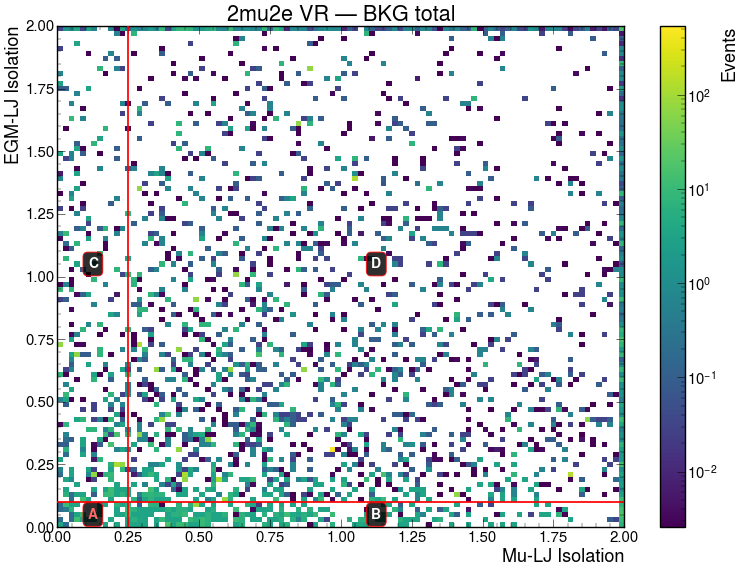

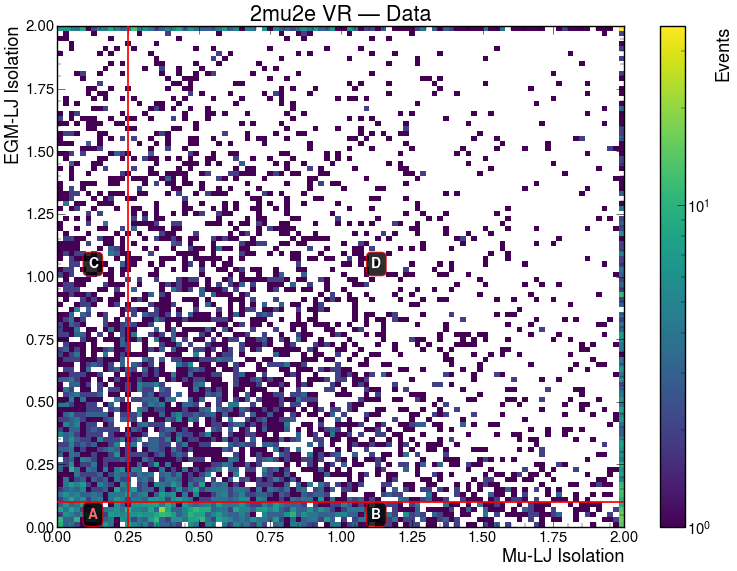

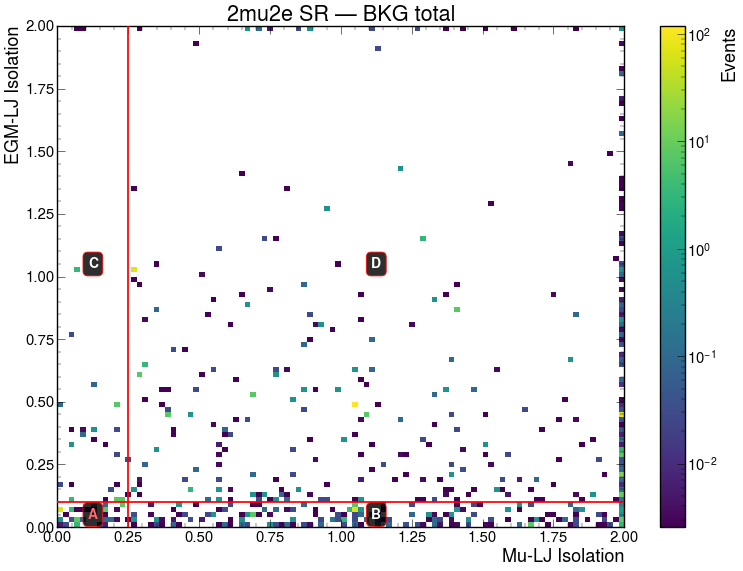

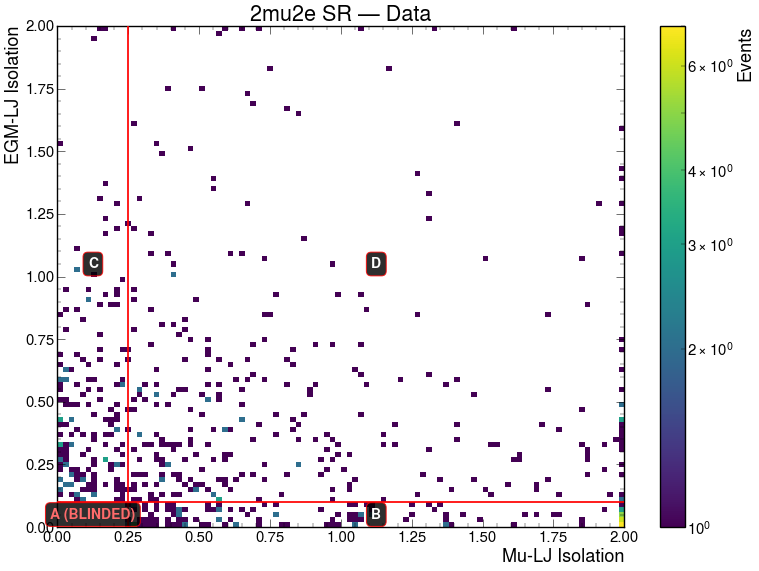

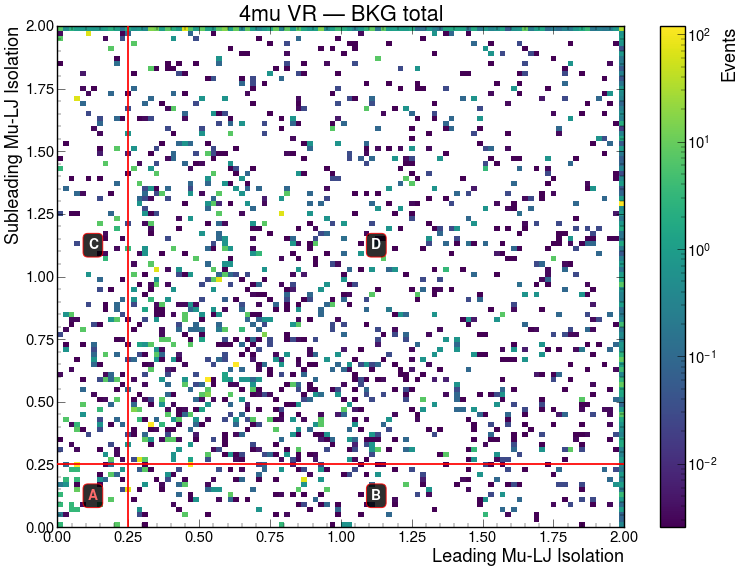

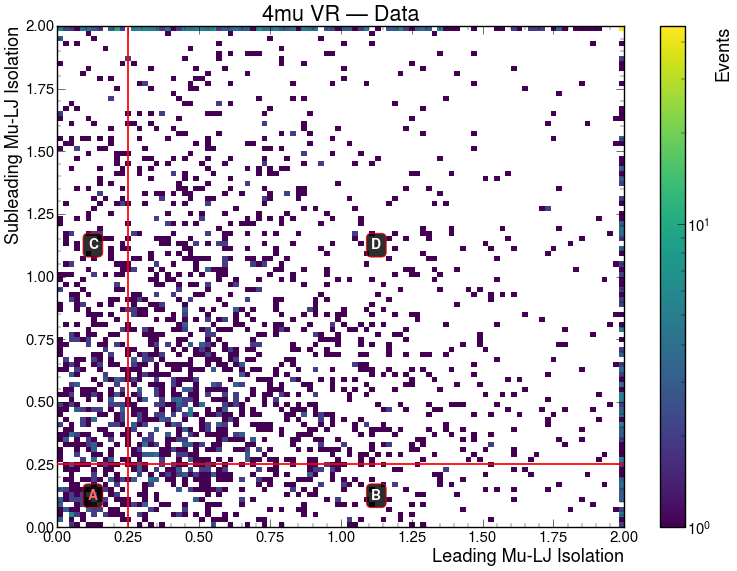

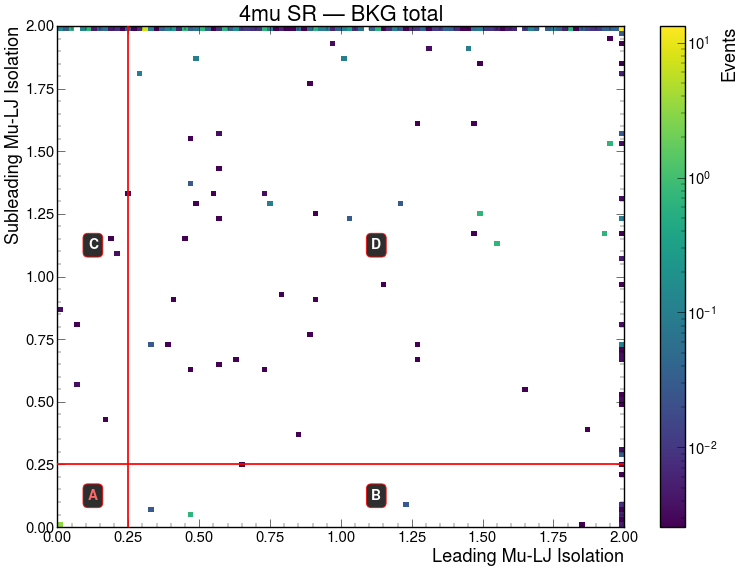

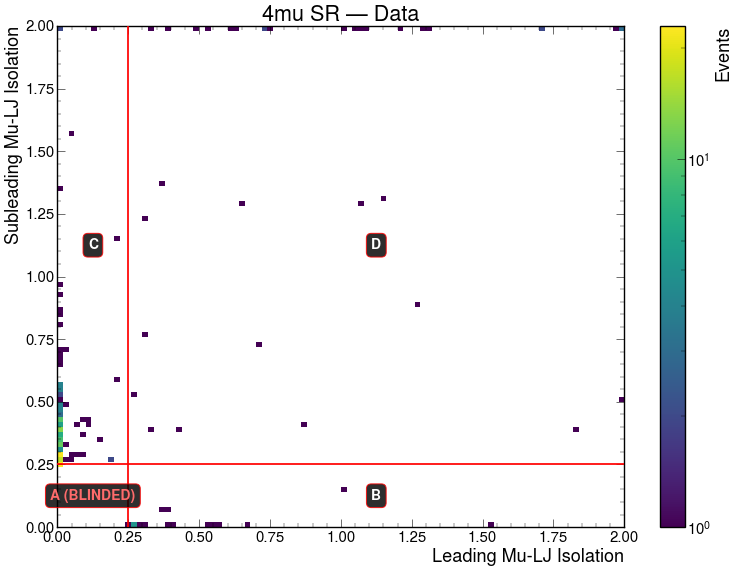

In [9]:
def plot_abcd_plane(h2d, title, cfg, blind_a=False):
    values, _ = values_variances(h2d)
    values = values.copy()
    masks = abcd_masks(h2d, *cfg["cuts"])
    if blind_a:
        values[masks["A"]] = np.nan
    xedges, yedges = h2d.axes[0].edges, h2d.axes[1].edges
    positive = values[np.isfinite(values) & (values > 0)]
    norm = LogNorm(vmin=max(positive.min(), 1e-8), vmax=positive.max()) if positive.size else None
    fig, ax = plt.subplots(figsize=(16, 12))
    mesh = ax.pcolormesh(xedges, yedges, values.T, shading="auto", cmap="viridis", norm=norm)
    xcut, ycut = cfg["cuts"]
    boundary_color = "r"
    ax.axvline(xcut, color=boundary_color, lw=2.5, zorder=3)
    ax.axhline(ycut, color=boundary_color, lw=2.5, zorder=3)
    positions = {
        "A": ((xedges[0]+xcut)/2, (yedges[0]+ycut)/2),
        "B": ((xcut+xedges[-1])/2, (yedges[0]+ycut)/2),
        "C": ((xedges[0]+xcut)/2, (ycut+yedges[-1])/2),
        "D": ((xcut+xedges[-1])/2, (ycut+yedges[-1])/2),
    }
    label_box = dict(boxstyle="round,pad=0.35", facecolor="black",
                     edgecolor=boundary_color, linewidth=1.5, alpha=0.82)
    for region, (xpos, ypos) in positions.items():
        label = "A (BLINDED)" if region == "A" and blind_a else region
        ax.text(xpos, ypos, label, ha="center", va="center", fontsize=20,
                fontweight="bold", color="#FF6B6B" if region == "A" else "white",
                bbox=label_box, zorder=4)
    ax.set(xlabel=cfg["x_label"], ylabel=cfg["y_label"], title=title)
    fig.colorbar(mesh, ax=ax, label="Events")
    fig.tight_layout()
    return fig, ax


for topology, cfg in CHANNEL_CONFIGS.items():
    for region_type in ["VR", "SR"]:
        for group in ["BKG total", "Data"]:
            h2d = group_hist(group, topology, region_type)
            if h2d is None:
                continue
            blind = group == "Data" and region_type == "SR" and BLIND_SR_DATA_A
            plot_abcd_plane(h2d, f"{topology} {region_type} — {group}", cfg, blind)
            plt.show()
            plt.close()


## 5. Master ABCD summary

이 표가 이후 모든 plot의 단일 입력이다. `kappa`는 observed/predicted이며 SR Data에서는 의도적으로 `NaN`이다.

In [10]:
rows = []
groups = [*BACKGROUND_ORDER, "BKG total", "Data"]
for topology, cfg in CHANNEL_CONFIGS.items():
    for region_type in ["VR", "SR"]:
        for group in groups:
            h2d = group_hist(group, topology, region_type)
            if h2d is None:
                continue
            blind = group == "Data" and region_type == "SR" and BLIND_SR_DATA_A
            y, pred, epred, kappa, ekappa, pull = closure(h2d, cfg["cuts"], blind)
            row = {"topology": topology, "selection": region_type, "group": group,
                   "A_pred": pred, "A_pred_err": epred, "kappa": kappa,
                   "kappa_err": ekappa, "pull": pull}
            for r, (v, e) in y.items():
                row[r], row[f"{r}_err"] = v, e
            rows.append(row)
summary_columns = ["topology", "selection", "group", "A_pred", "A_pred_err",
                   "kappa", "kappa_err", "pull", "A", "A_err", "B", "B_err",
                   "C", "C_err", "D", "D_err"]
abcd_summary = pd.DataFrame(rows, columns=summary_columns)
display(abcd_summary)

,topology,selection,group,A_pred,A_pred_err,kappa,kappa_err,pull,A,A_err,B,B_err,C,C_err,D,D_err
0,2mu2e,VR,QCD,18.805669,14.598750,0.471929,0.537164,-0.606953,8.874946,7.387738,101.639680,71.663549,696.949192,189.185331,3766.826531,671.934413
1,2mu2e,VR,DY,247.062988,235.869319,0.039440,0.044003,-1.005860,9.744119,5.625769,19.262403,11.056538,83.319858,23.854477,6.496079,4.593422
2,2mu2e,VR,TTJets,256.436292,42.326614,0.357447,0.089689,-3.602864,91.662334,17.322553,769.308875,50.184178,189.871978,24.931412,569.615933,43.182472
3,2mu2e,VR,Diboson,NaN,NaN,NaN,NaN,NaN,2.803850,0.801832,0.413422,0.292333,2.017428,0.638160,0.000000,0.000000
4,2mu2e,VR,BKG total,199.364557,53.855134,0.567228,0.182247,-1.504825,113.085248,19.670834,890.624379,88.184173,972.158455,192.307327,4342.938543,673.336231
5,2mu2e,VR,Data,362.667735,15.464493,0.716910,0.053956,-4.595346,260.000000,16.124515,1221.000000,34.942810,1298.000000,36.027767,4370.000000,66.105976
6,2mu2e,SR,QCD,8.461987,7.638708,11.233335,13.210069,1.201906,95.056329,71.641437,122.465518,72.078340,24.409249,12.744004,353.261166,156.353017
7,2mu2e,SR,DY,NaN,NaN,NaN,NaN,NaN,6.496079,4.593422,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,2mu2e,SR,TTJets,3.273655,3.660057,0.000000,NaN,-0.894427,0.000000,0.000000,6.547310,4.629647,6.547310,4.629647,13.094619,6.547310
9,2mu2e,SR,Diboson,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 6. VR Data closure

VR은 Data A까지 사용한다. Data와 total MC의 closure를 topology별로 비교한다.

,topology,group,A,A_err,A_pred,A_pred_err,kappa,kappa_err,pull
4,2mu2e,BKG total,113.085248,19.670834,199.364557,53.855134,0.567228,0.182247,-1.504825
5,2mu2e,Data,260.000000,16.124515,362.667735,15.464493,0.716910,0.053956,-4.595346
16,4mu,BKG total,69.983675,19.234431,45.706950,27.672168,1.531139,1.018038,0.720371
17,4mu,Data,129.000000,11.357817,71.692650,5.660552,1.799348,0.212795,4.515865


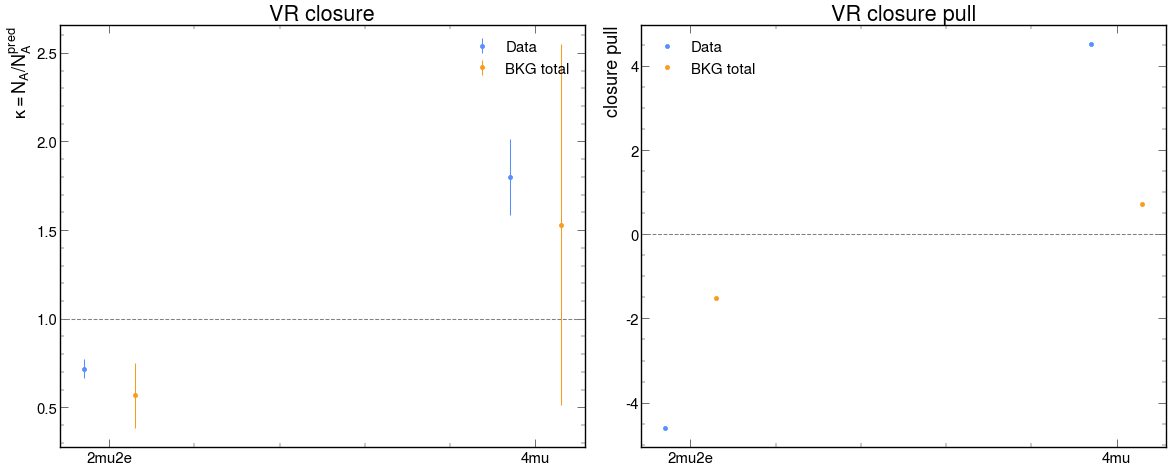

In [11]:
vr_closure = abcd_summary[
    (abcd_summary.selection == "VR") & abcd_summary.group.isin(["Data", "BKG total"])
][["topology", "group", "A", "A_err", "A_pred", "A_pred_err", "kappa", "kappa_err", "pull"]]
display(vr_closure)

if not vr_closure.empty:
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    for i, group in enumerate(["Data", "BKG total"]):
        frame = vr_closure[vr_closure.group == group]
        x = np.arange(len(frame)) + (i-0.5)*0.12
        axes[0].errorbar(x, frame.kappa, yerr=frame.kappa_err, fmt="o", label=group)
        axes[1].plot(x, frame.pull, "o", label=group)
    axes[0].axhline(1, color="gray", ls="--"); axes[1].axhline(0, color="gray", ls="--")
    axes[0].set(ylabel=r"$\kappa=N_A/N_A^{pred}$", title="VR closure")
    axes[1].set(ylabel="closure pull", title="VR closure pull")
    for ax in axes:
        ax.set_xticks(range(len(CHANNEL_CONFIGS)), CHANNEL_CONFIGS.keys()); ax.legend(frameon=False)
    fig.tight_layout()

## 7. SR/VR transferability in MC

`kappa_SR_MC / kappa_VR_MC`가 1에서 벗어나는 정도는 VR closure를 SR로 옮길 때의 추가 systematic 후보이다.

In [12]:
mc_kappa = abcd_summary[abcd_summary.group == "BKG total"].pivot(
    index="topology", columns="selection", values=["kappa", "kappa_err"])
if not mc_kappa.empty:
    transfer_rows = []
    for topology in mc_kappa.index:
        ks, es = mc_kappa.loc[topology, ("kappa", "SR")], mc_kappa.loc[topology, ("kappa_err", "SR")]
        kv, ev = mc_kappa.loc[topology, ("kappa", "VR")], mc_kappa.loc[topology, ("kappa_err", "VR")]
        ratio = ks/kv if kv > 0 else np.nan
        eratio = abs(ratio)*np.sqrt((es/ks)**2+(ev/kv)**2) if ks > 0 and kv > 0 else np.nan
        transfer_rows.append({"topology": topology, "kappa_SR_MC": ks, "kappa_SR_MC_err": es,
                              "kappa_VR_MC": kv, "kappa_VR_MC_err": ev,
                              "R_kappa_SR_over_VR": ratio, "R_kappa_err": eratio})
    transfer_summary = pd.DataFrame(transfer_rows)
else:
    transfer_summary = pd.DataFrame()
display(transfer_summary)

,topology,kappa_SR_MC,kappa_SR_MC_err,kappa_VR_MC,kappa_VR_MC_err,R_kappa_SR_over_VR,R_kappa_err
0,2mu2e,9.315533,10.151147,0.567228,0.182247,16.422895,18.657727
1,4mu,77.374368,114.049582,1.531139,1.018038,50.533876,81.714159


## 8. Blinded SR Data prediction

세 후보를 함께 출력한다.

1. raw SR Data B×C/D
2. VR Data κ correction
3. SR MC κ correction

최종 correction/systematic 선택은 closure 검토 후 결정한다.

In [13]:
prediction_rows = []
for topology in CHANNEL_CONFIGS:
    def one(selection, group):
        f = abcd_summary[(abcd_summary.topology == topology) &
                         (abcd_summary.selection == selection) &
                         (abcd_summary.group == group)]
        return None if f.empty else f.iloc[0]
    sr_data, vr_data, sr_mc = one("SR", "Data"), one("VR", "Data"), one("SR", "BKG total")
    if sr_data is None:
        continue
    raw, eraw = sr_data.A_pred, sr_data.A_pred_err
    def corrected(k, ek):
        val = k*raw
        err = abs(val)*np.sqrt((ek/k)**2+(eraw/raw)**2) if k > 0 and raw > 0 else np.nan
        return val, err
    vr_val, vr_err = corrected(vr_data.kappa, vr_data.kappa_err) if vr_data is not None else (np.nan, np.nan)
    mc_val, mc_err = corrected(sr_mc.kappa, sr_mc.kappa_err) if sr_mc is not None else (np.nan, np.nan)
    prediction_rows.append({"topology": topology,
        "SR_Data_B": sr_data.B, "SR_Data_C": sr_data.C, "SR_Data_D": sr_data.D,
        "raw_prediction": raw, "raw_prediction_err": eraw,
        "VR_Data_kappa_prediction": vr_val, "VR_Data_kappa_prediction_err": vr_err,
        "SR_MC_kappa_prediction": mc_val, "SR_MC_kappa_prediction_err": mc_err})
sr_prediction = pd.DataFrame(prediction_rows)
display(sr_prediction)

,topology,SR_Data_B,SR_Data_C,SR_Data_D,raw_prediction,raw_prediction_err,VR_Data_kappa_prediction,VR_Data_kappa_prediction_err,SR_MC_kappa_prediction,SR_MC_kappa_prediction_err
0,2mu2e,134.0,167.0,305.0,73.370492,9.489899,52.600014,7.871360,683.485239,750.022806
1,4mu,18.0,177.0,36.0,88.500000,26.399574,159.242265,51.098908,6847.631548,10298.004758


## 9. Working-point stability

VR Data, VR MC, SR MC에서 동일한 isolation cut scan을 수행한다. 낮은 control yield와 큰 statistical uncertainty가 있는 point는 선택하지 않는다.

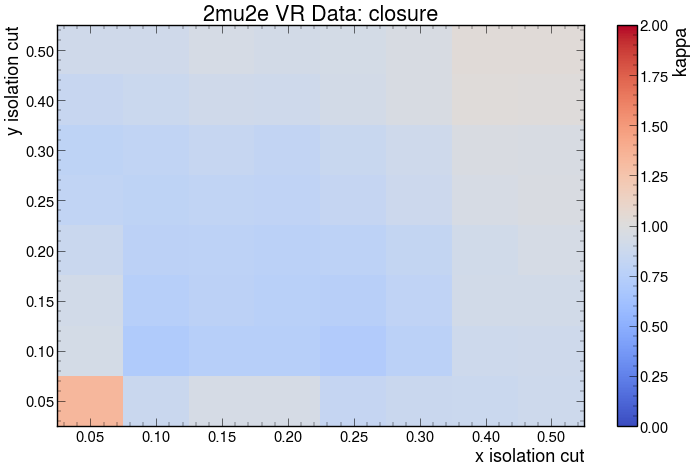

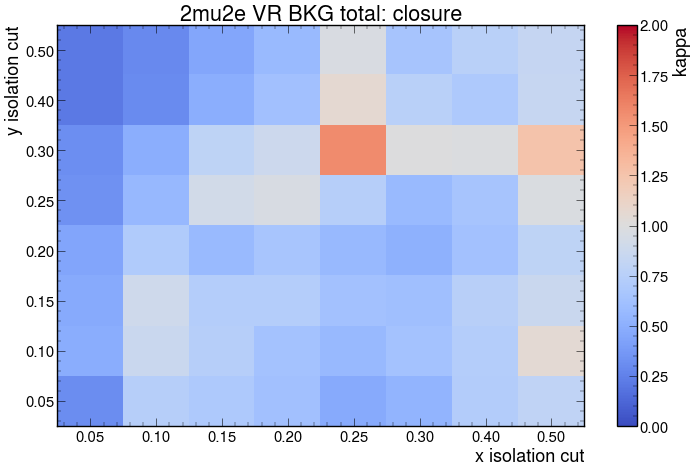

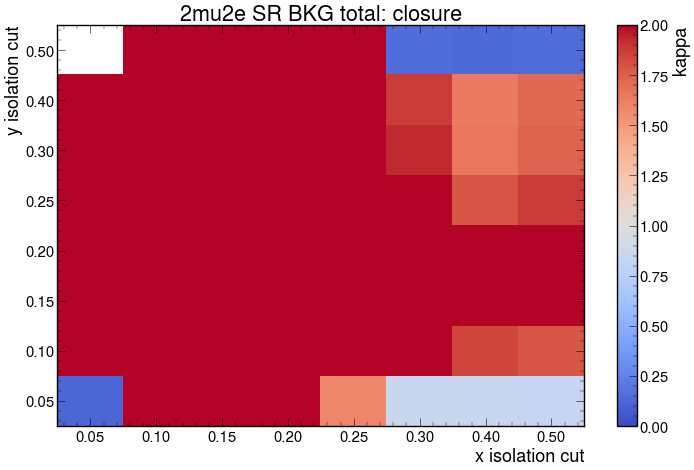

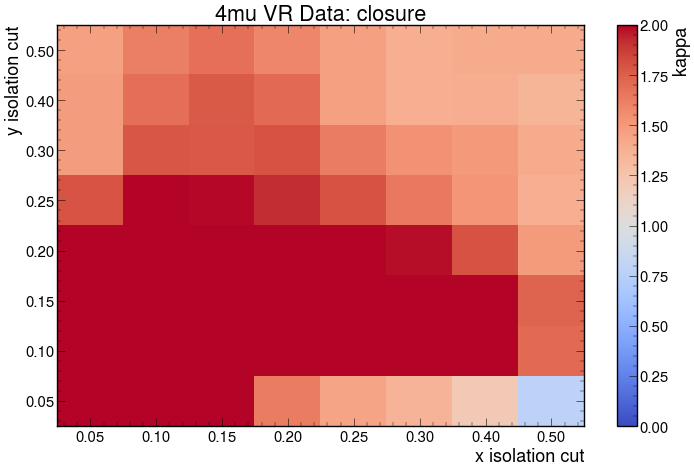

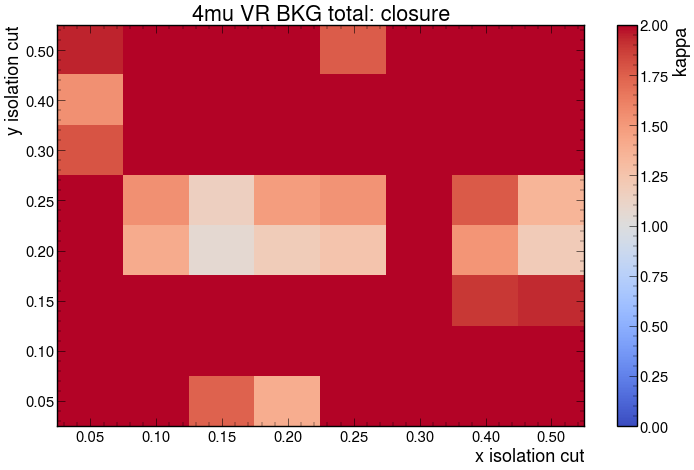

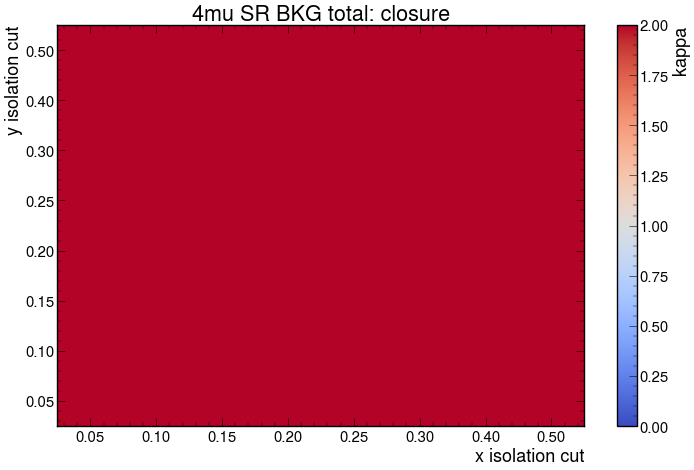

In [14]:
def scan_working_points(h2d, scan_values):
    rows = []
    for xcut in scan_values:
        for ycut in scan_values:
            y, pred, epred, kappa, ekappa, pull = closure(h2d, (xcut, ycut))
            rows.append({"xcut": xcut, "ycut": ycut, "kappa": kappa, "kappa_err": ekappa,
                         "pull": pull, "pred": pred,
                         "relative_pred_err": epred/pred if pred > 0 else np.nan,
                         "min_control_yield": min(y[r][0] for r in ["B", "C", "D"])})
    return pd.DataFrame(rows)


def heatmap(frame, value, title, cmap="viridis", vmin=None, vmax=None):
    table = frame.pivot(index="ycut", columns="xcut", values=value)
    fig, ax = plt.subplots(figsize=(15, 10))
    im = ax.imshow(table.values, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    ax.set(xlabel="x isolation cut", ylabel="y isolation cut", title=title)
    fig.colorbar(im, ax=ax, label=value); fig.tight_layout()


wp_scans = {}
for topology in CHANNEL_CONFIGS:
    for selection, group in [("VR", "Data"), ("VR", "BKG total"), ("SR", "BKG total")]:
        h2d = group_hist(group, topology, selection)
        if h2d is None:
            continue
        key = (topology, selection, group)
        wp_scans[key] = scan_working_points(h2d, SCAN_VALUES)
        heatmap(wp_scans[key], "kappa", f"{topology} {selection} {group}: closure", "coolwarm", 0, 2)
        plt.show()

## 10. Correlation and background composition diagnostics

In [15]:
def weighted_corr(h2d):
    w, _ = values_variances(h2d)
    x, y = np.meshgrid(h2d.axes[0].centers, h2d.axes[1].centers, indexing="ij")
    mask = np.isfinite(w) & (w > 0)
    if not mask.any(): return np.nan
    w, x, y = w[mask], x[mask], y[mask]
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cov = np.average((x-mx)*(y-my), weights=w)
    vx, vy = np.average((x-mx)**2, weights=w), np.average((y-my)**2, weights=w)
    return cov/np.sqrt(vx*vy) if vx > 0 and vy > 0 else np.nan


corr_rows = []
for topology in CHANNEL_CONFIGS:
    for selection in ["VR", "SR"]:
        for group in [*BACKGROUND_ORDER, "BKG total", "Data"]:
            h2d = group_hist(group, topology, selection)
            if h2d is not None:
                corr_rows.append({"topology": topology, "selection": selection,
                                  "group": group, "weighted_Pearson": weighted_corr(h2d)})
correlation_summary = pd.DataFrame(corr_rows)
display(correlation_summary)

,topology,selection,group,weighted_Pearson
0,2mu2e,VR,QCD,0.043438
1,2mu2e,VR,DY,-0.446994
2,2mu2e,VR,TTJets,-0.137374
3,2mu2e,VR,Diboson,-0.149571
4,2mu2e,VR,BKG total,0.008972
5,2mu2e,VR,Data,0.035563
6,2mu2e,SR,QCD,-0.058068
7,2mu2e,SR,DY,-1.000000
8,2mu2e,SR,TTJets,-0.079539
9,2mu2e,SR,Diboson,NaN


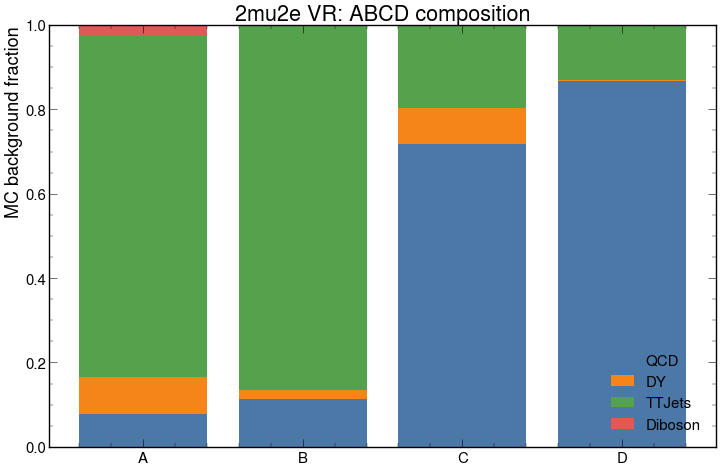

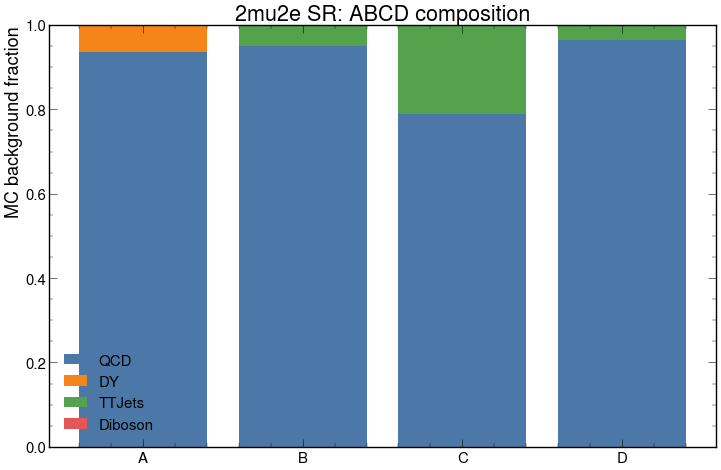

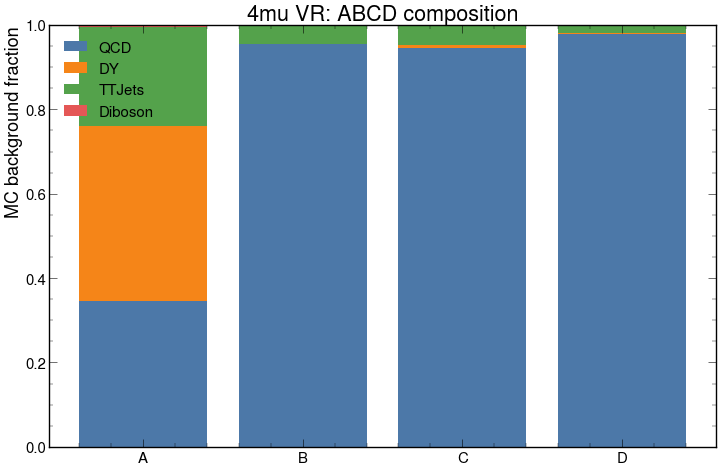

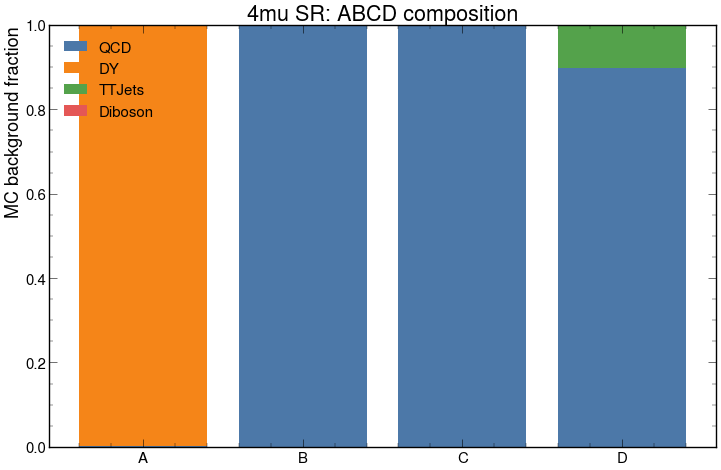

In [16]:
composition = abcd_summary[abcd_summary.group.isin(BACKGROUND_ORDER)].copy()
if not composition.empty:
    for topology in CHANNEL_CONFIGS:
        for selection in ["VR", "SR"]:
            frame = composition[(composition.topology == topology) & (composition.selection == selection)]
            if frame.empty: continue
            regions = ["A", "B", "C", "D"]
            totals = frame[regions].sum(axis=0).to_numpy(float)
            bottom = np.zeros(4)
            fig, ax = plt.subplots(figsize=(15, 10))
            for group in BACKGROUND_ORDER:
                vals = frame.loc[frame.group == group, regions].sum(axis=0).to_numpy(float)
                frac = np.divide(vals, totals, out=np.zeros_like(vals), where=totals != 0)
                ax.bar(regions, frac, bottom=bottom, label=group, color=COLORS[group])
                bottom += frac
            ax.set(ylabel="MC background fraction", ylim=(0,1),
                   title=f"{topology} {selection}: ABCD composition")
            ax.legend(frameon=False); fig.tight_layout(); plt.show()

## 11. Region yields and background composition


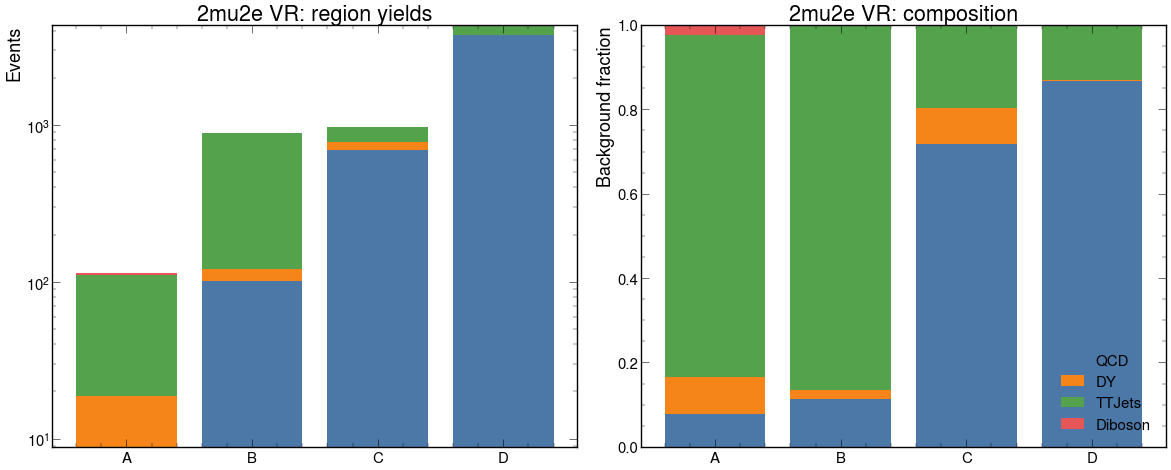

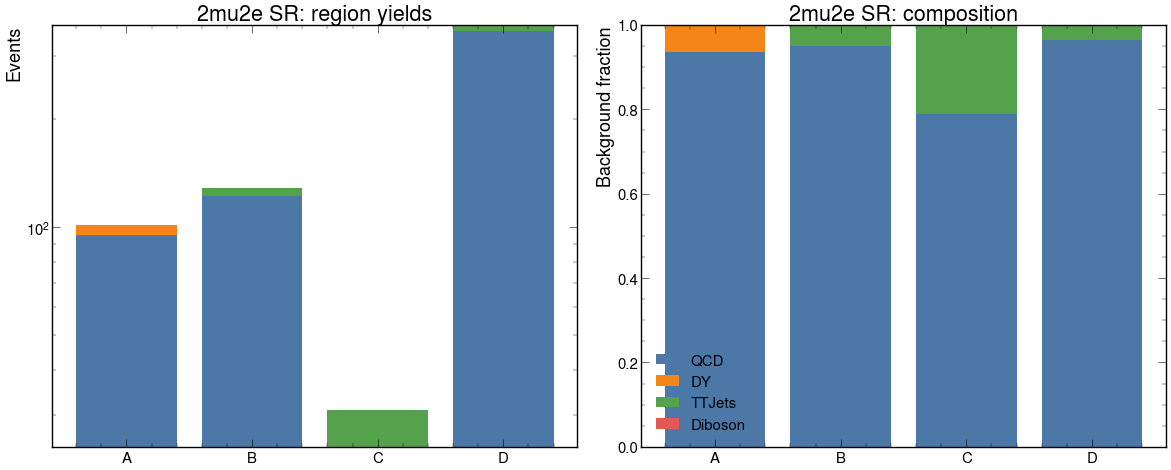

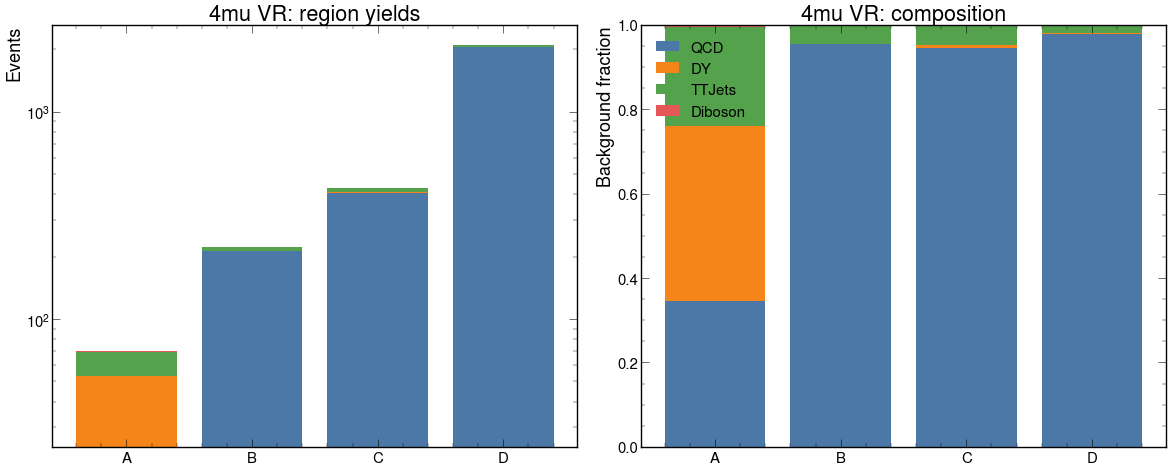

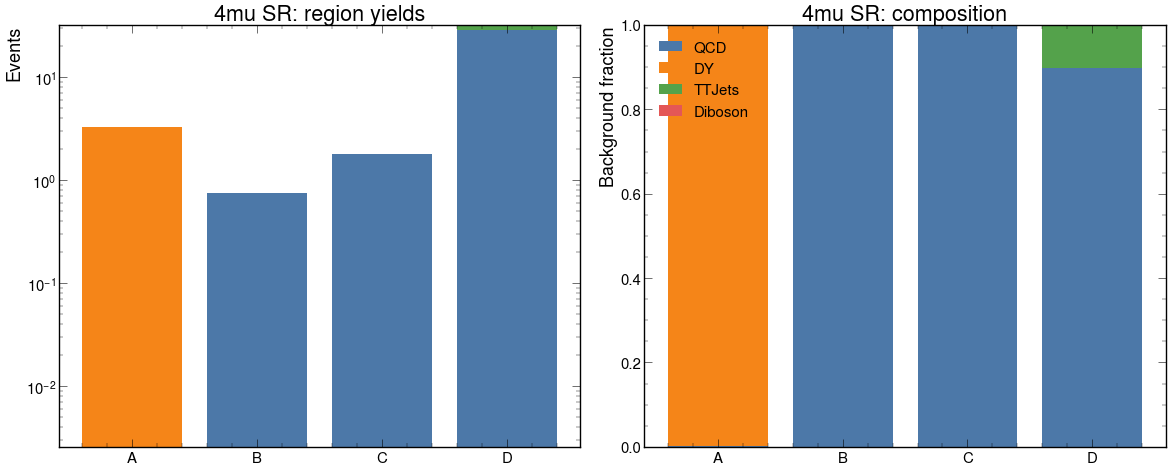

In [17]:
def plot_region_composition(summary, topology, selection):
    frame = summary[(summary.topology == topology) & (summary.selection == selection)
                    & summary.group.isin(BACKGROUND_ORDER)].copy()
    if frame.empty: return None
    regions = ["A", "B", "C", "D"]
    totals = frame[regions].sum(axis=0).to_numpy(float)
    bottom_y, bottom_f = np.zeros(4), np.zeros(4)
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    for group in BACKGROUND_ORDER:
        vals = frame.loc[frame.group == group, regions].sum(axis=0).to_numpy(float)
        frac = np.divide(vals, totals, out=np.zeros_like(vals), where=totals != 0)
        axes[0].bar(regions, vals, bottom=bottom_y, label=group, color=COLORS[group])
        axes[1].bar(regions, frac, bottom=bottom_f, label=group, color=COLORS[group])
        bottom_y += vals; bottom_f += frac
    axes[0].set(ylabel="Events", title=f"{topology} {selection}: region yields")
    if np.any(totals > 0): axes[0].set_yscale("log")
    axes[1].set(ylabel="Background fraction", ylim=(0,1), title=f"{topology} {selection}: composition")
    axes[1].legend(frameon=False); fig.tight_layout()
    return fig

for topology in CHANNEL_CONFIGS:
    for selection in ["VR", "SR"]:
        if plot_region_composition(abcd_summary, topology, selection):
            plt.show(); plt.close()


## 12. MC closure and Data control regions

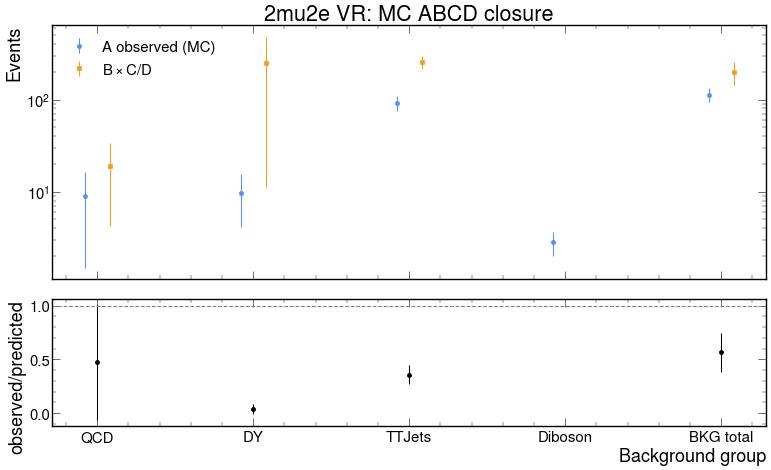

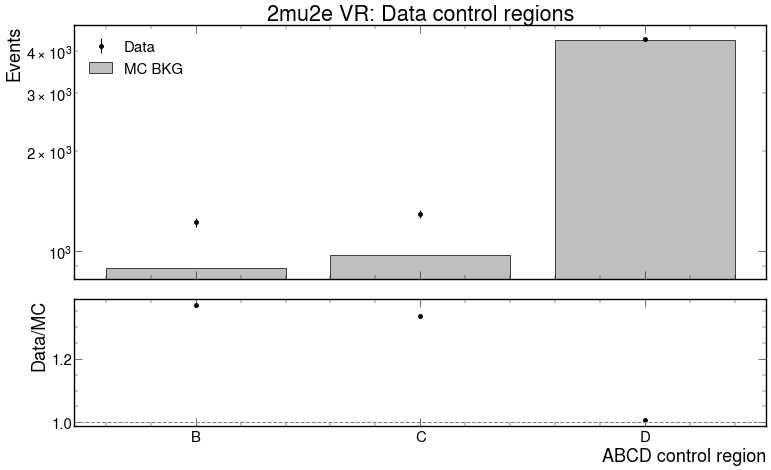

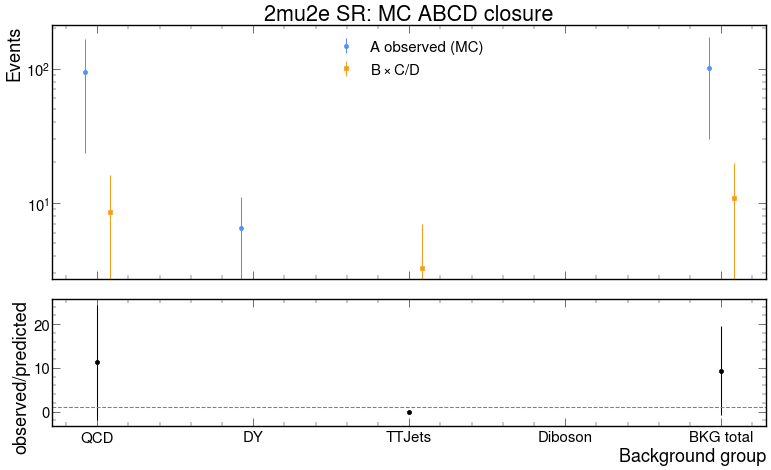

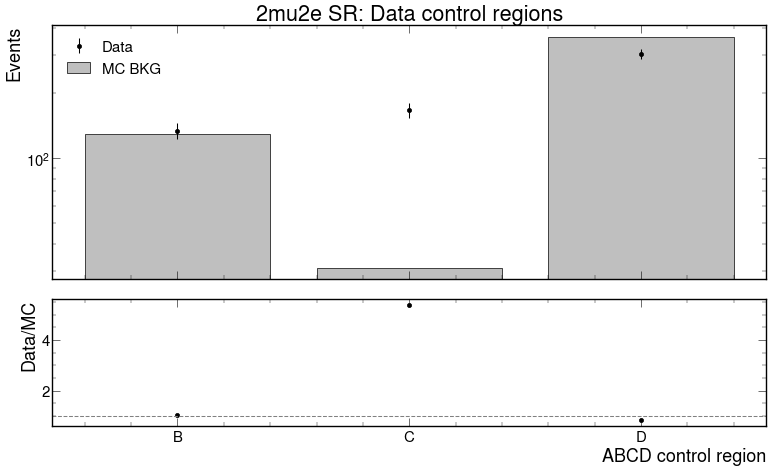

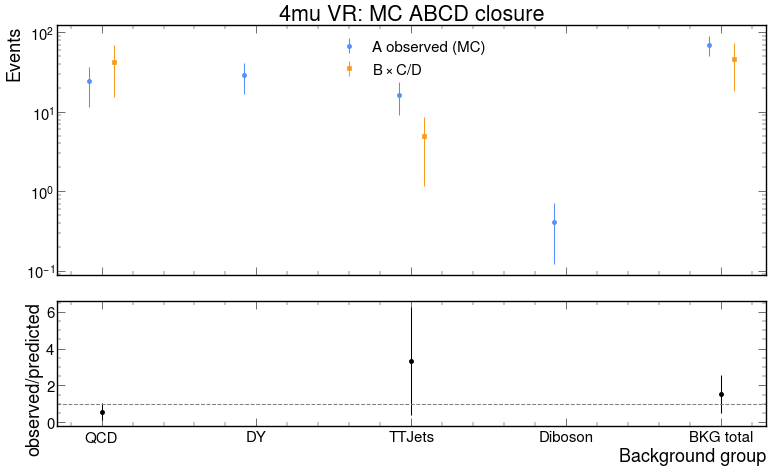

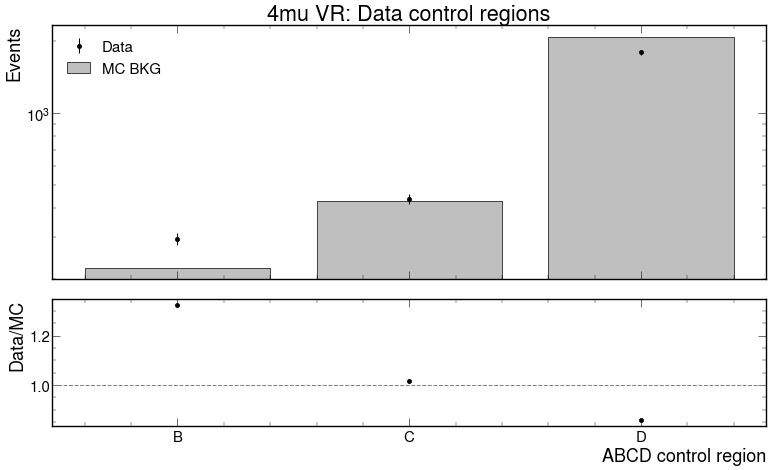

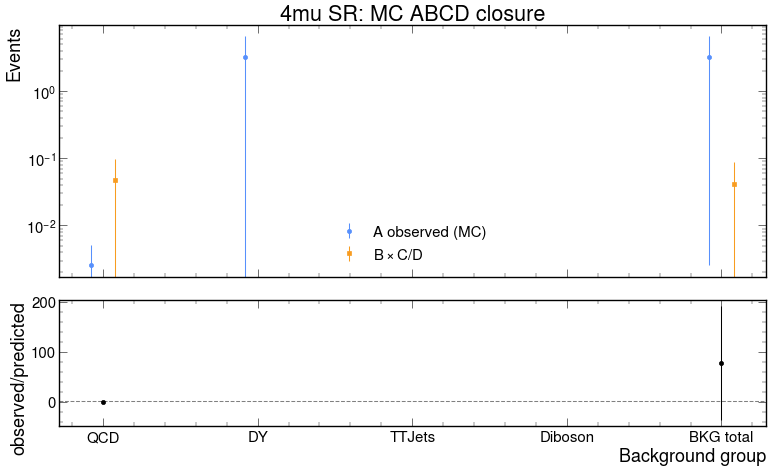

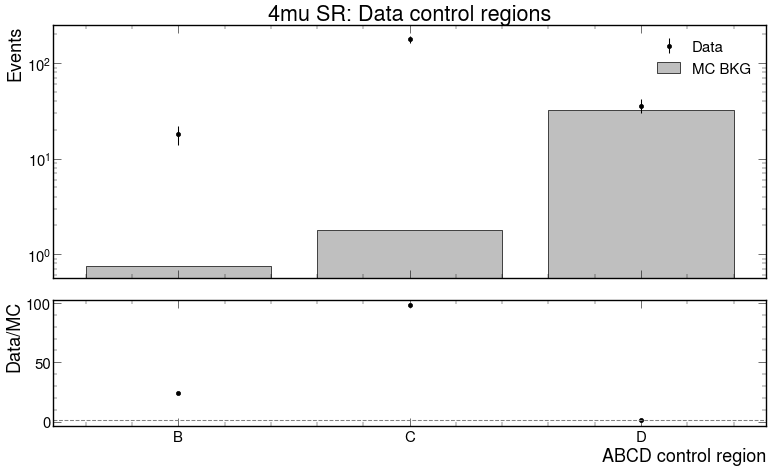

In [18]:
def plot_mc_closure(summary, topology, selection):
    frame = summary[(summary.topology == topology) & (summary.selection == selection)
                    & summary.group.isin([*BACKGROUND_ORDER, "BKG total"])].copy()
    if frame.empty: return None
    x = np.arange(len(frame))
    fig, axes = plt.subplots(2,1,figsize=(16,10),sharex=True,gridspec_kw={"height_ratios":[2,1]})
    axes[0].errorbar(x-.08,frame.A,yerr=frame.A_err,fmt="o",label="A observed (MC)")
    axes[0].errorbar(x+.08,frame.A_pred,yerr=frame.A_pred_err,fmt="s",label=r"$B\times C/D$")
    axes[0].set(ylabel="Events",title=f"{topology} {selection}: MC ABCD closure")
    if np.any((frame.A>0)|(frame.A_pred>0)): axes[0].set_yscale("log")
    axes[0].legend(frameon=False)
    axes[1].errorbar(x,frame.kappa,yerr=frame.kappa_err,fmt="o",color="black")
    axes[1].axhline(1,color="gray",ls="--")
    axes[1].set(ylabel="observed/predicted",xticks=x,xticklabels=frame.group,xlabel="Background group")
    fig.tight_layout(); return fig

def plot_data_control_regions(summary, topology, selection):
    d=summary[(summary.topology==topology)&(summary.selection==selection)&(summary.group=="Data")]
    b=summary[(summary.topology==topology)&(summary.selection==selection)&(summary.group=="BKG total")]
    if d.empty or b.empty: return None
    d,b=d.iloc[0],b.iloc[0]; regions=["B","C","D"]; x=np.arange(3)
    fig,axes=plt.subplots(2,1,figsize=(16,10),sharex=True,gridspec_kw={"height_ratios":[2,1]})
    axes[0].errorbar(x,[d[r] for r in regions],yerr=[d[f"{r}_err"] for r in regions],fmt="o",color="black",label="Data")
    axes[0].bar(x,[b[r] for r in regions],color="0.75",edgecolor="black",label="MC BKG")
    axes[0].set_yscale("log"); axes[0].set(ylabel="Events",title=f"{topology} {selection}: Data control regions")
    axes[0].legend(frameon=False)
    ratio=[d[r]/b[r] if b[r] else np.nan for r in regions]
    axes[1].plot(x,ratio,"o",color="black"); axes[1].axhline(1,color="gray",ls="--")
    axes[1].set(ylabel="Data/MC",xticks=x,xticklabels=regions,xlabel="ABCD control region")
    fig.tight_layout(); return fig

for topology in CHANNEL_CONFIGS:
    for selection in ["VR","SR"]:
        if plot_mc_closure(abcd_summary,topology,selection): plt.show(); plt.close()
        if plot_data_control_regions(abcd_summary,topology,selection): plt.show(); plt.close()


## 13. One-axis working-point scans

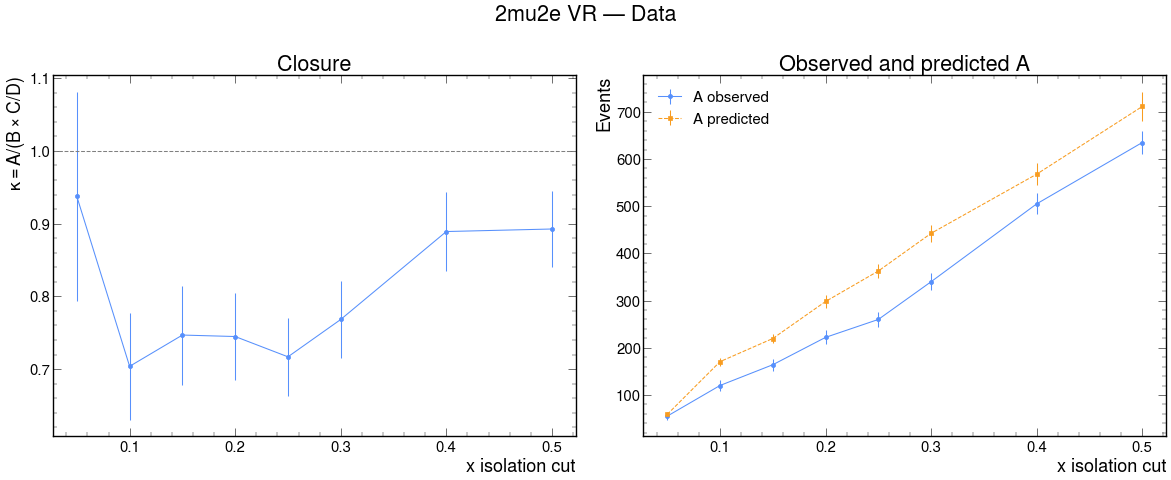

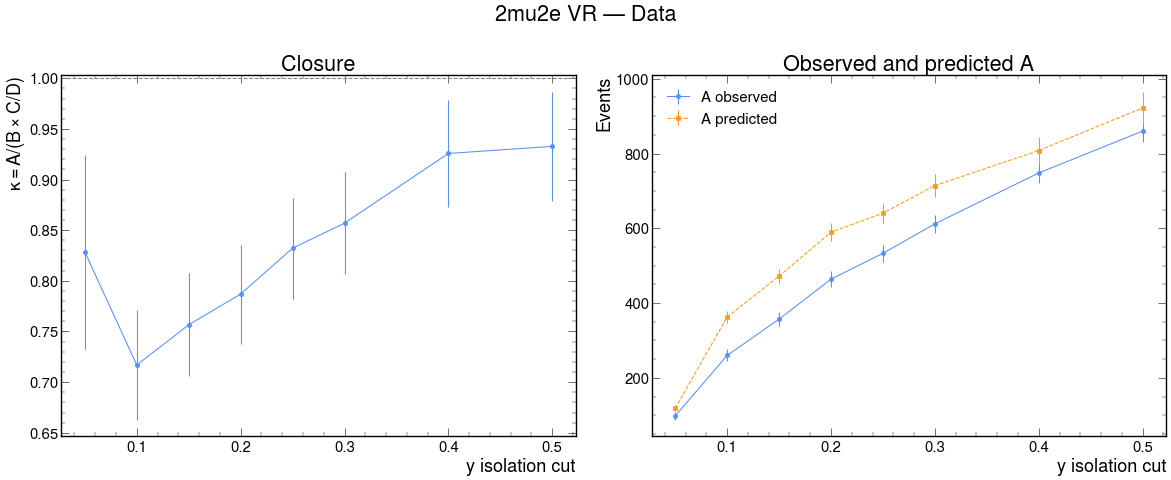

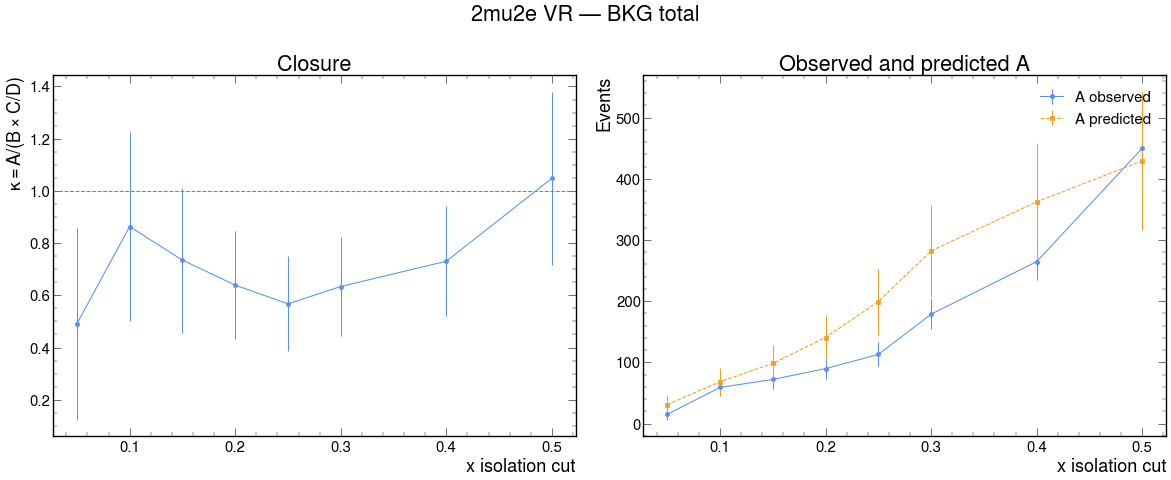

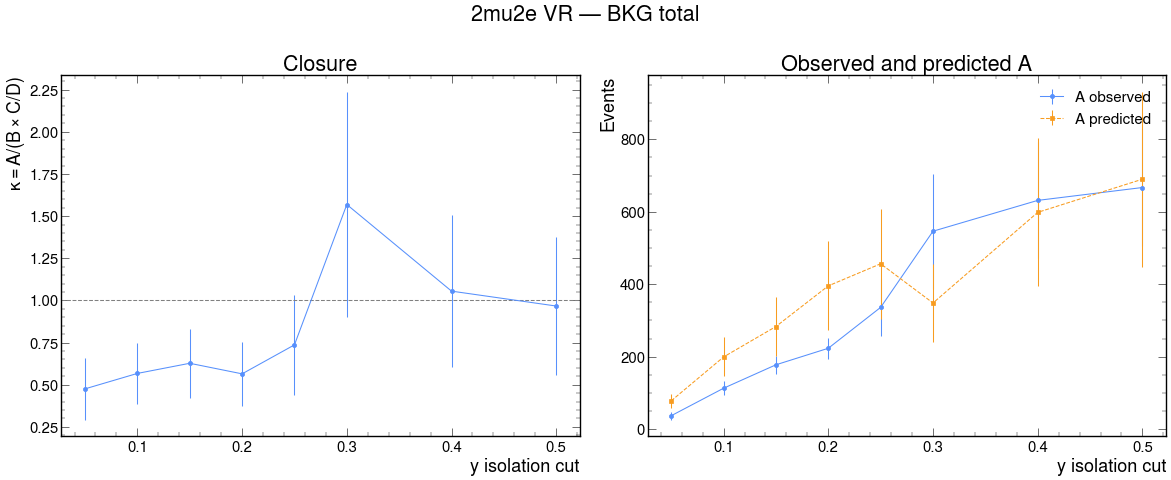

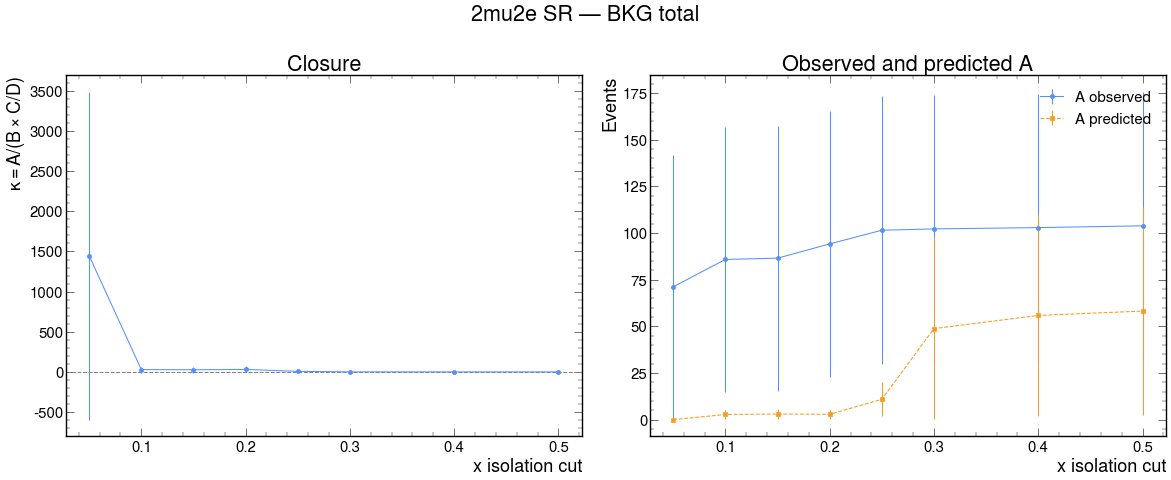

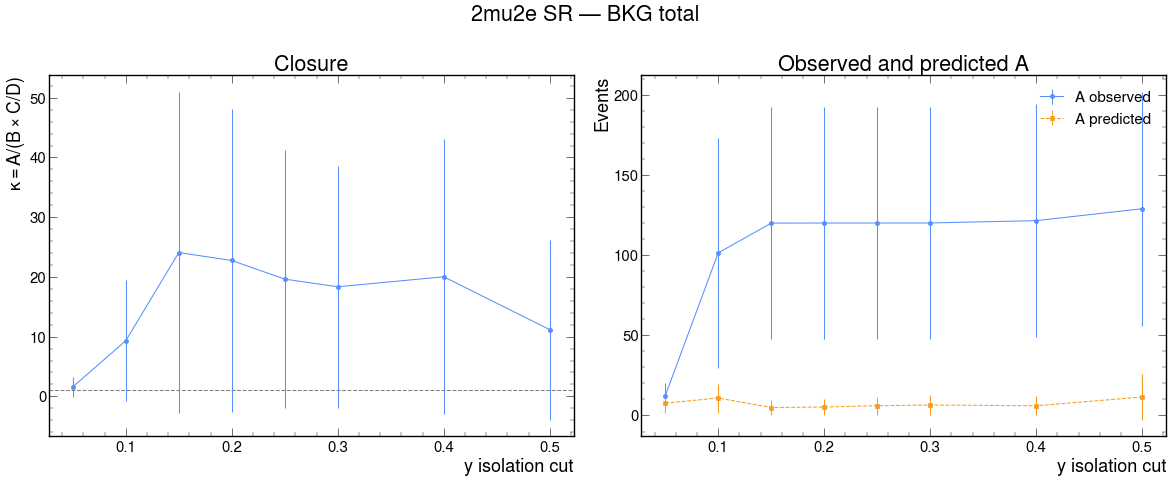

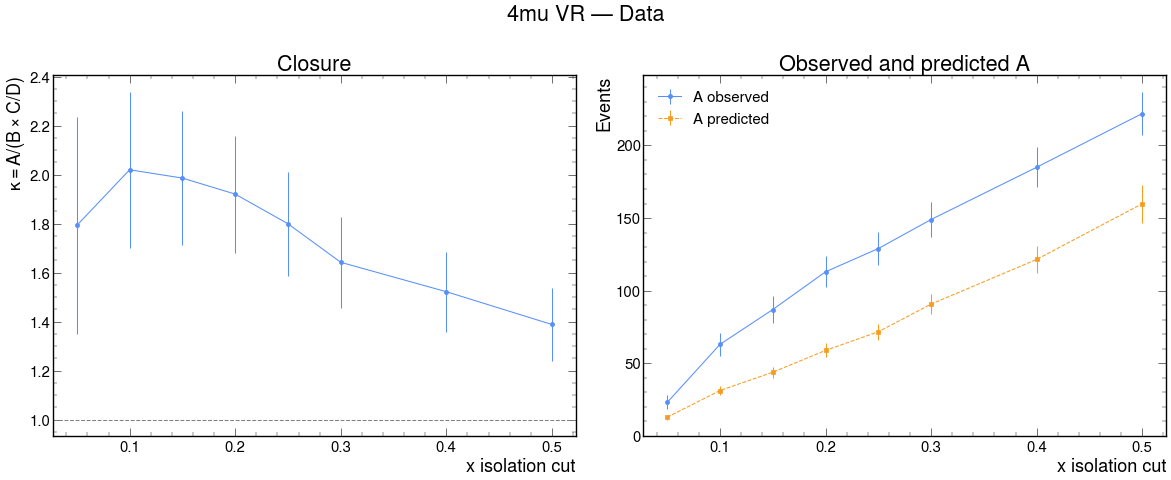

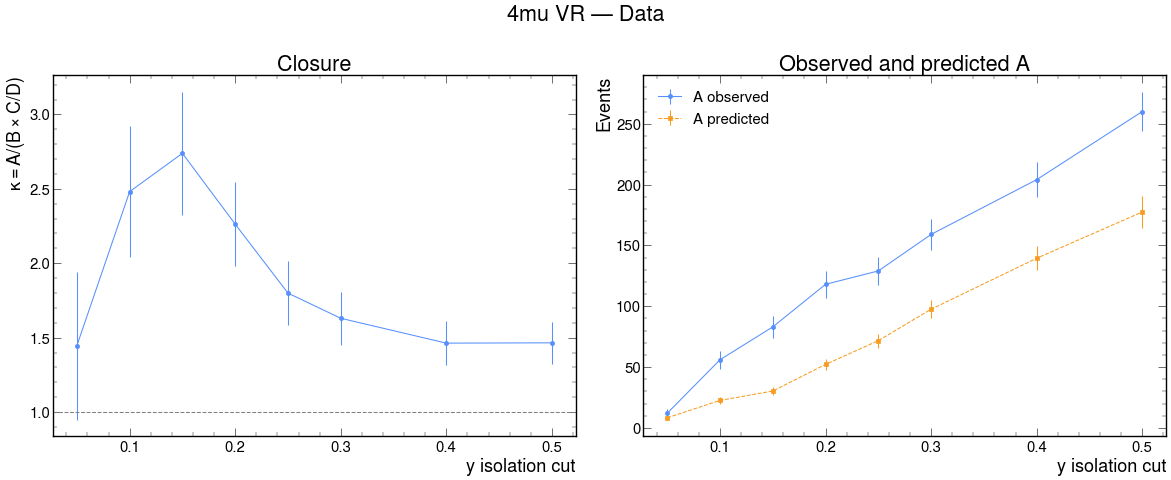

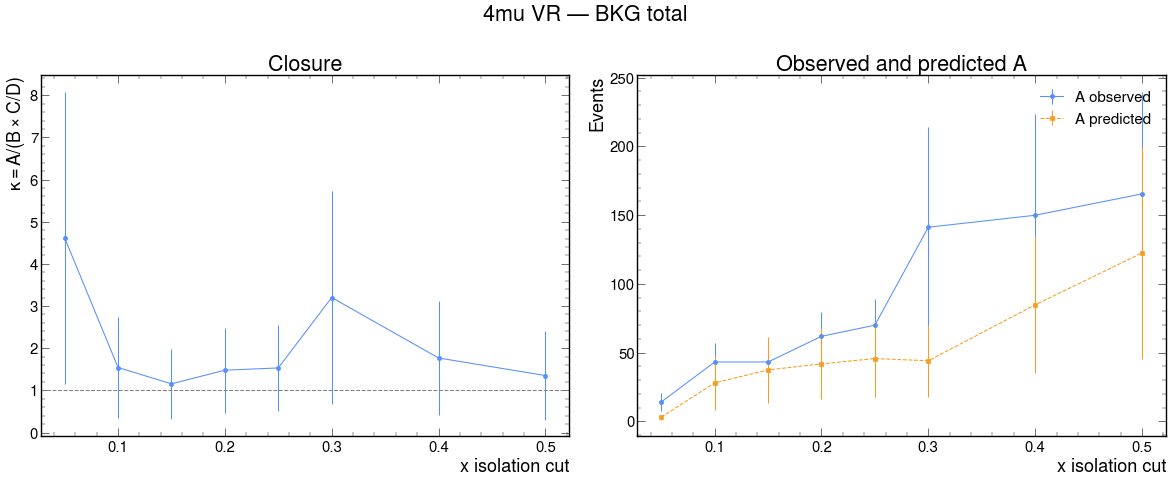

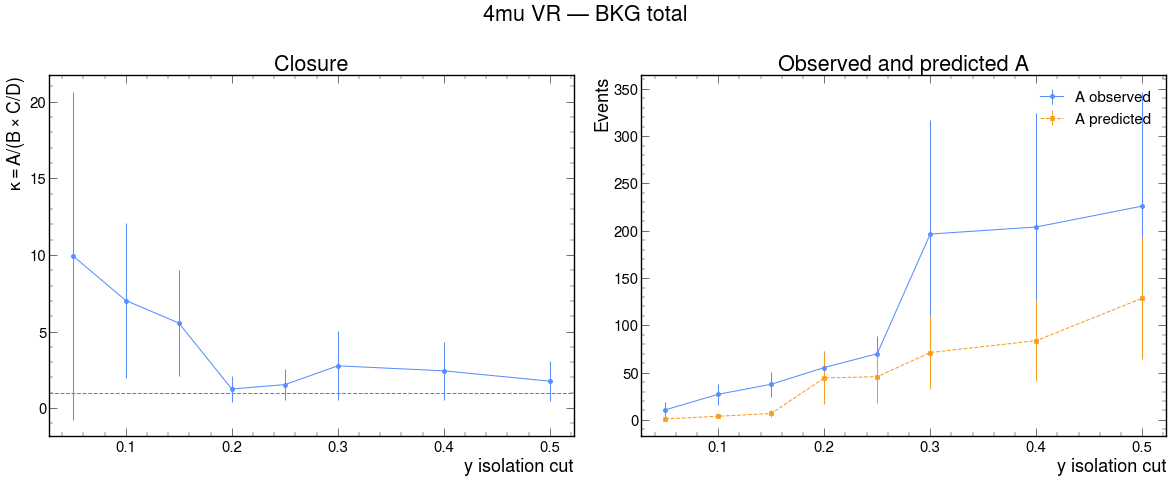

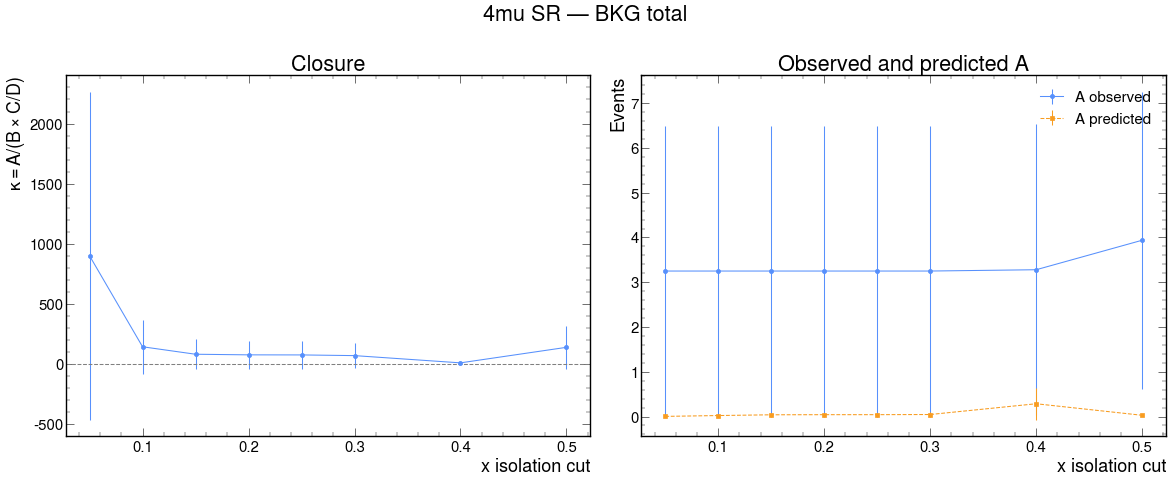

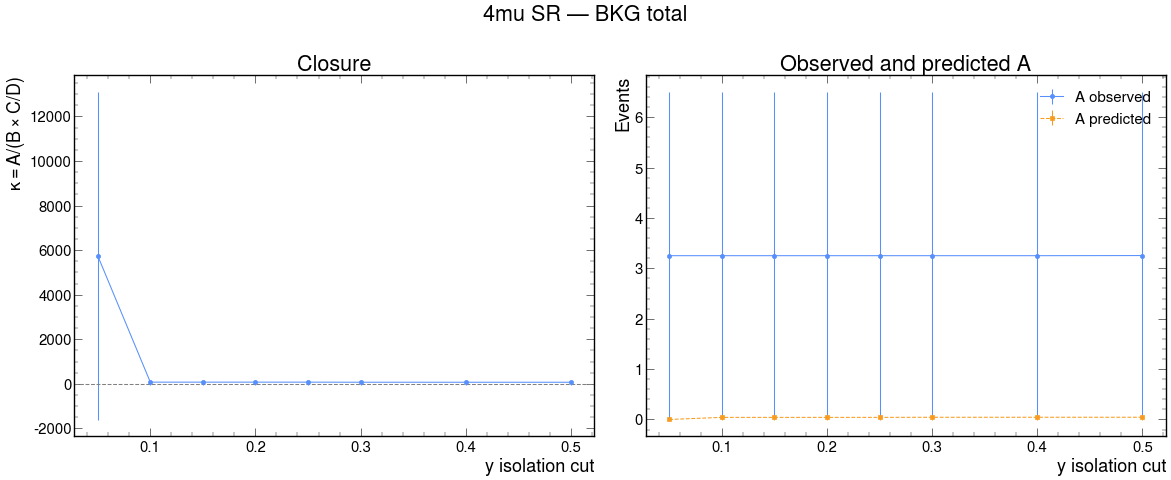

In [19]:
def scan_one_axis(h2d, scan_values, fixed_cut, scan_axis):
    rows=[]
    for cut in scan_values:
        cuts=(cut,fixed_cut) if scan_axis=="x" else (fixed_cut,cut)
        y,pred,epred,kappa,ekappa,pull=closure(h2d,cuts)
        rows.append({"scan_cut":cut,"A":y["A"][0],"A_err":y["A"][1],"A_pred":pred,
                     "A_pred_err":epred,"kappa":kappa,"kappa_err":ekappa,"pull":pull,
                     "min_control_yield":min(y[r][0] for r in ["B","C","D"])})
    return pd.DataFrame(rows)

def plot_one_axis_scan(frame,xlabel,title):
    fig,axes=plt.subplots(1,2,figsize=(24,10))
    axes[0].errorbar(frame.scan_cut,frame.kappa,yerr=frame.kappa_err,marker="o")
    axes[0].axhline(1,color="gray",ls="--")
    axes[0].set(xlabel=xlabel,ylabel=r"$\kappa=A/(B\times C/D)$",title="Closure")
    axes[1].errorbar(frame.scan_cut,frame.A,yerr=frame.A_err,marker="o",label="A observed")
    axes[1].errorbar(frame.scan_cut,frame.A_pred,yerr=frame.A_pred_err,marker="s",ls="--",label="A predicted")
    axes[1].set(xlabel=xlabel,ylabel="Events",title="Observed and predicted A")
    axes[1].legend(frameon=False); fig.suptitle(title); fig.tight_layout(); return fig

one_axis_scans={}
for topology,cfg in CHANNEL_CONFIGS.items():
    for selection,group in [("VR","Data"),("VR","BKG total"),("SR","BKG total")]:
        h2d=group_hist(group,topology,selection)
        if h2d is None: continue
        for index,axis_name in enumerate(["x","y"]):
            frame=scan_one_axis(h2d,SCAN_VALUES,cfg["cuts"][1-index],axis_name)
            one_axis_scans[(topology,selection,group,axis_name)]=frame
            plot_one_axis_scan(frame,f"{axis_name} isolation cut",f"{topology} {selection} — {group}")
            plt.show(); plt.close()

## 14. Correlation profiles and matrices


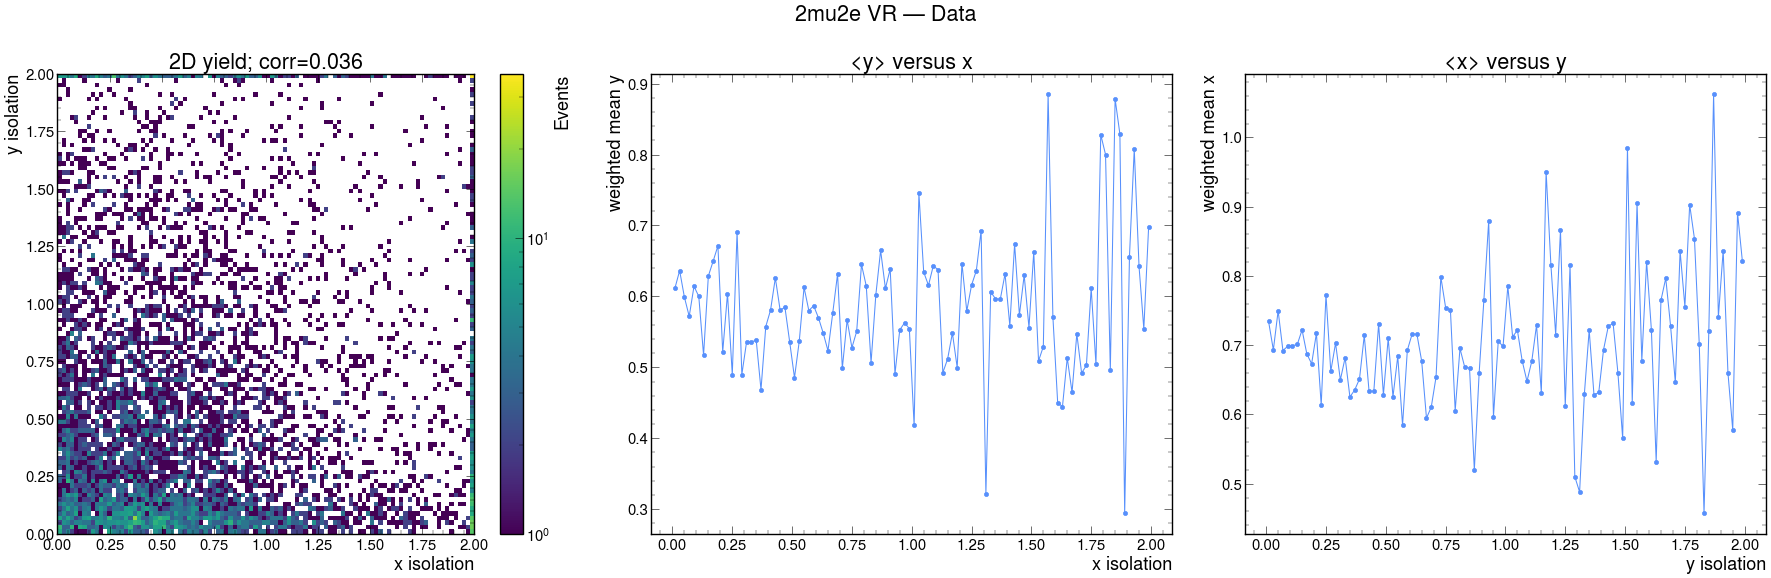

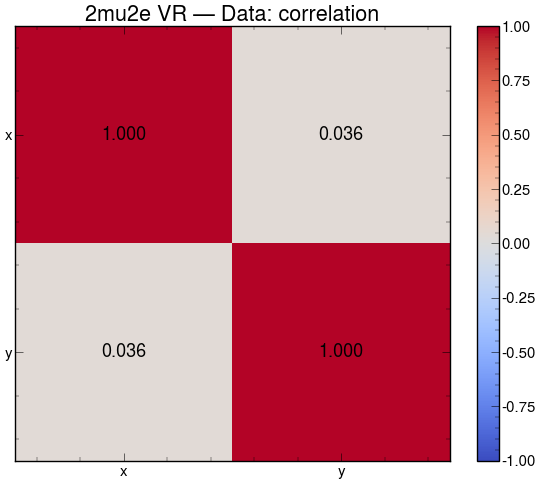

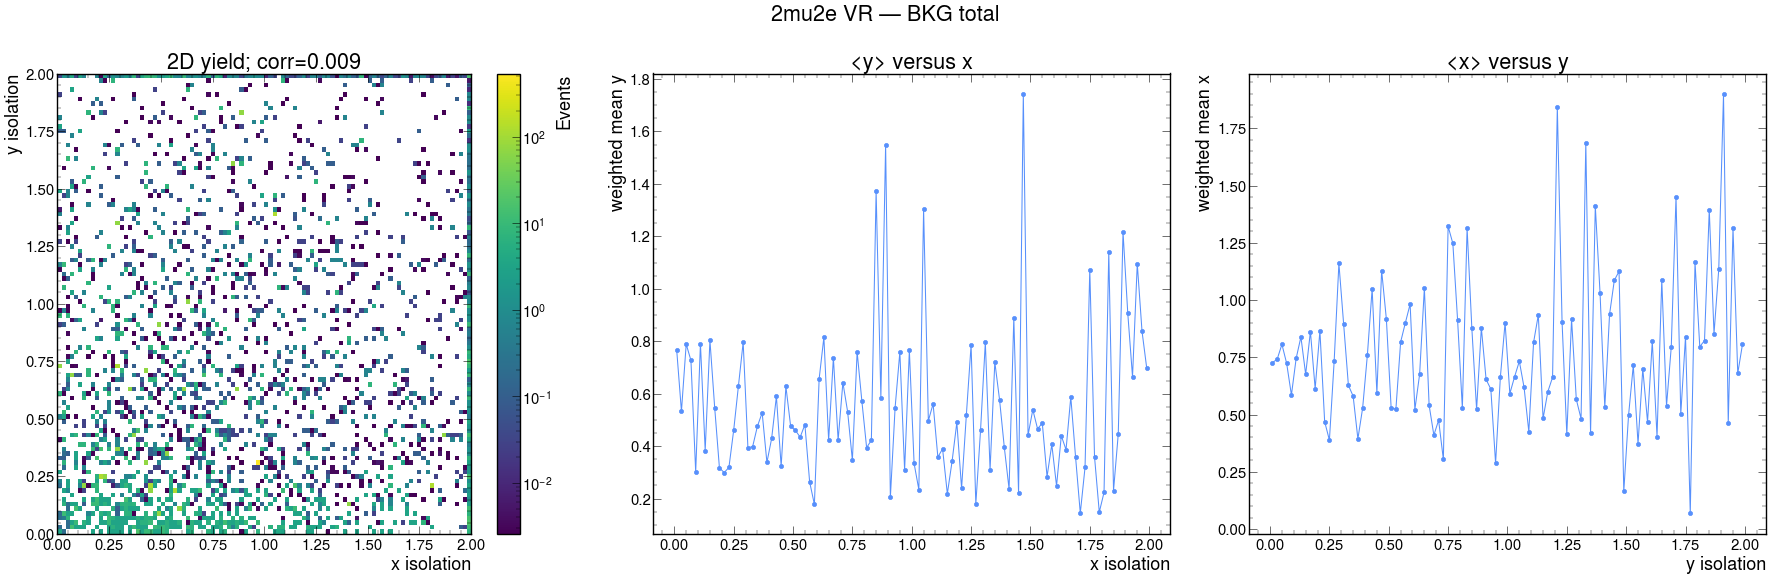

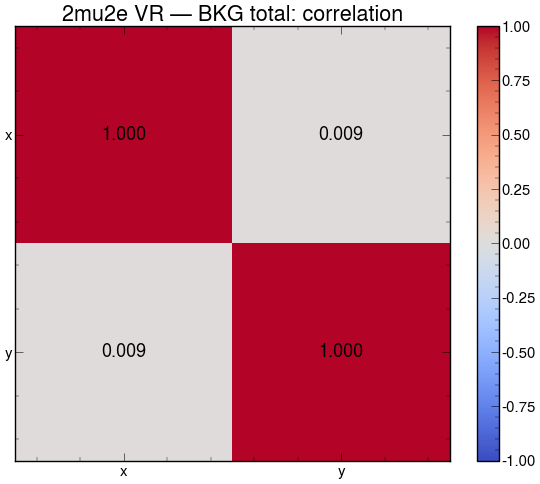

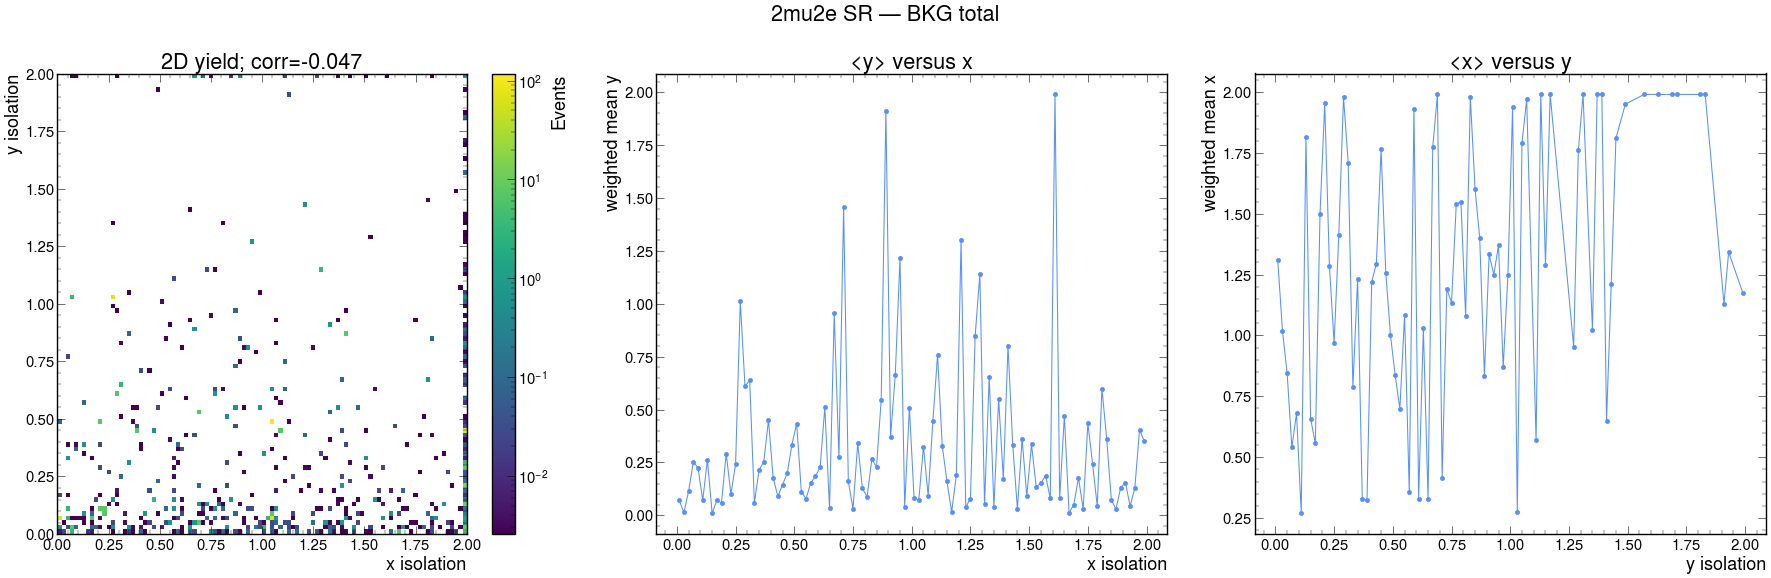

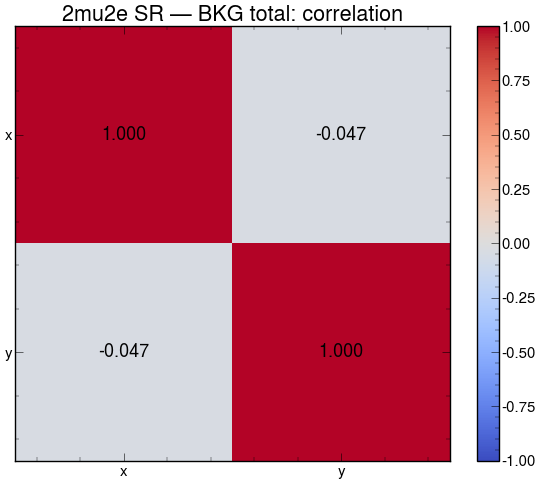

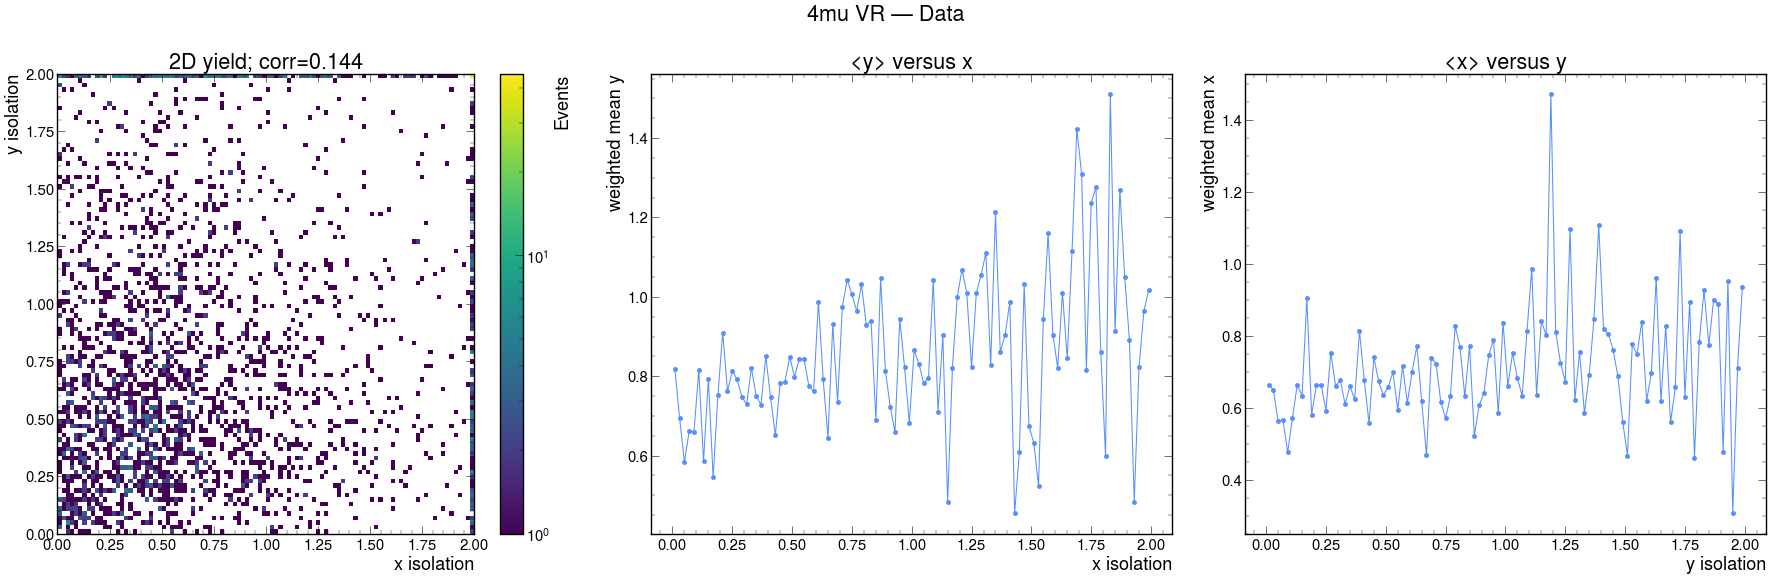

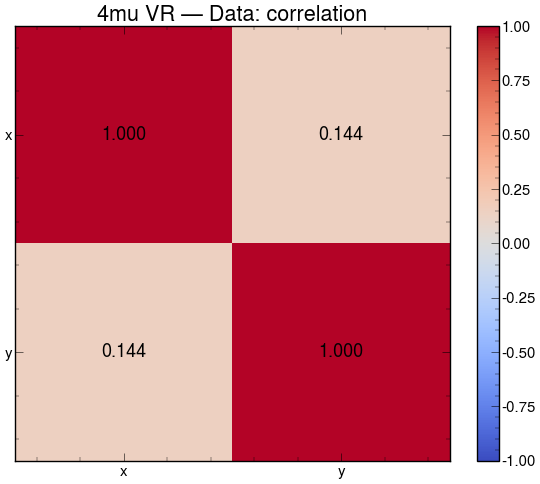

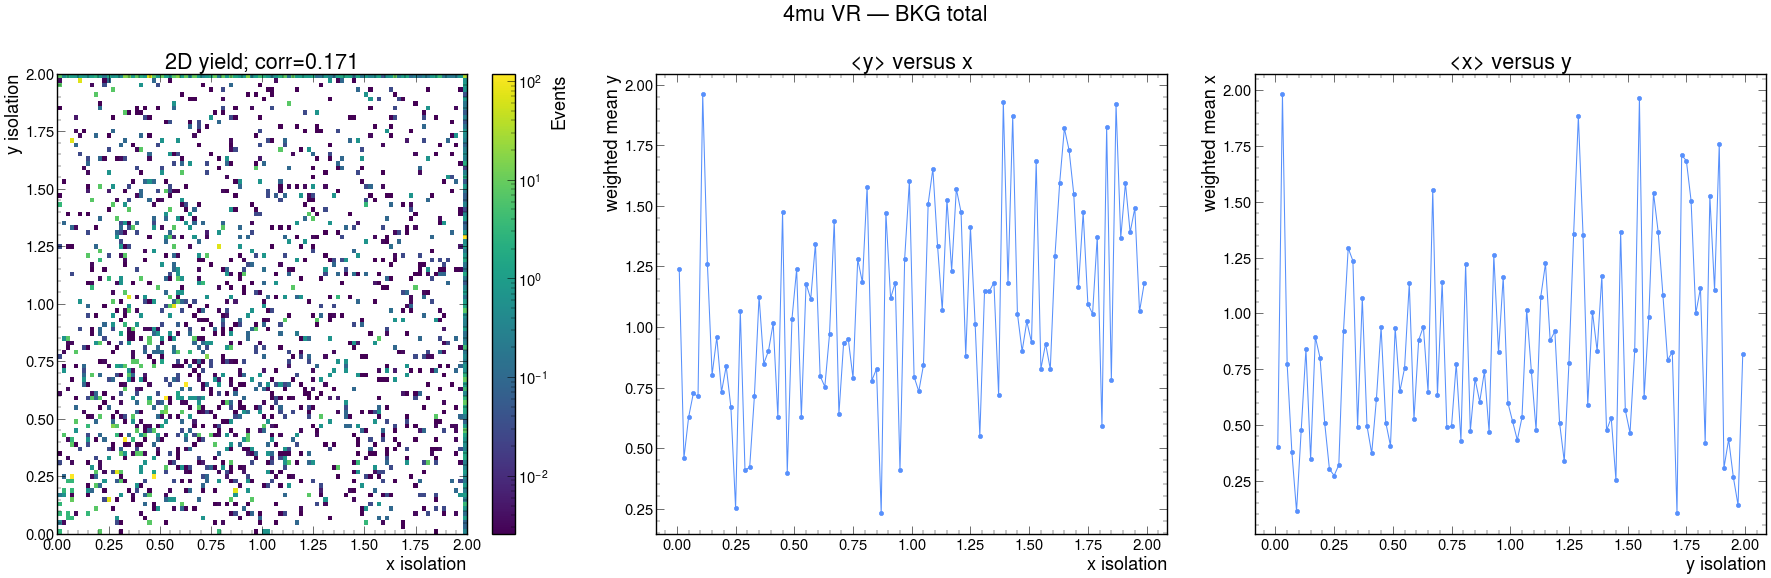

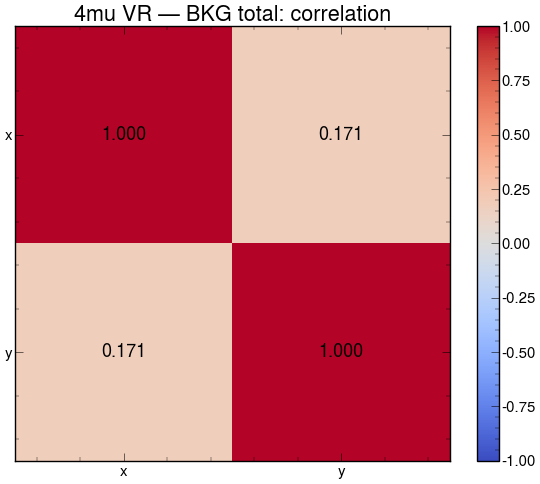

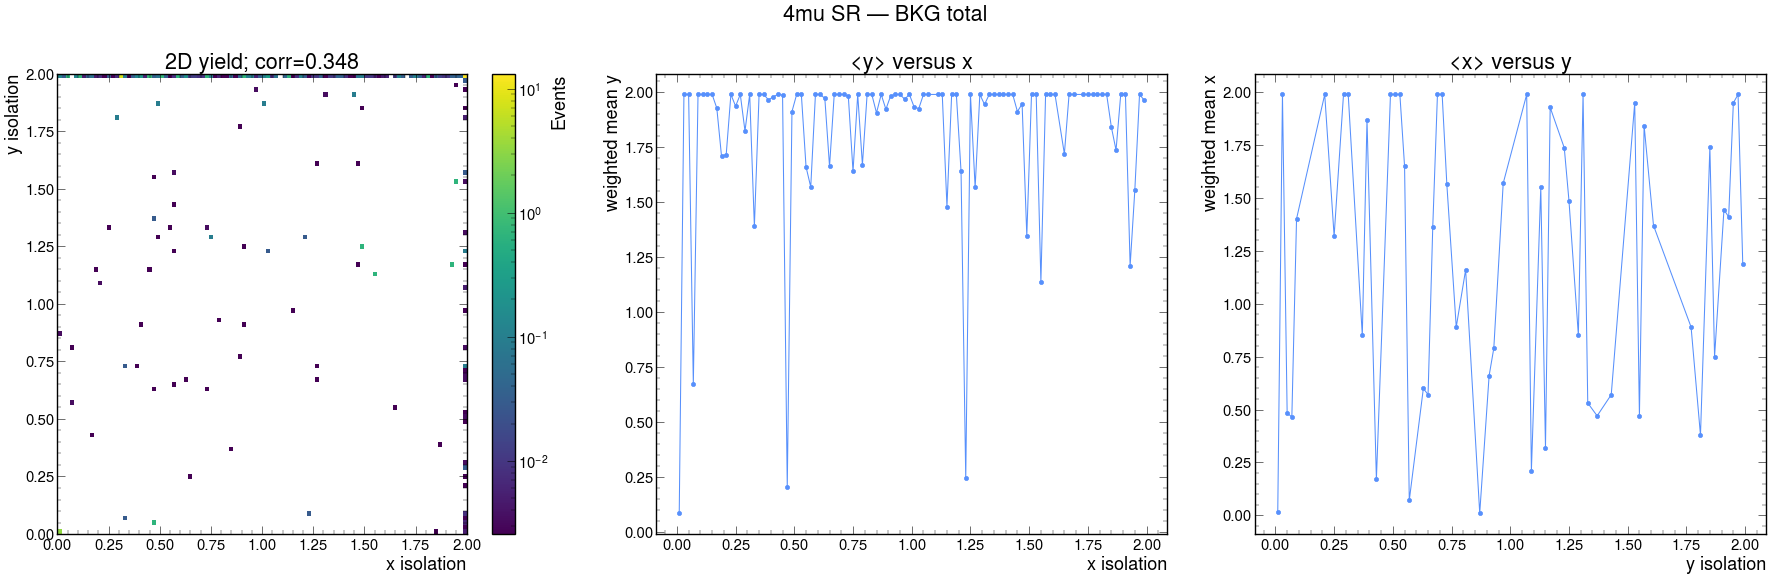

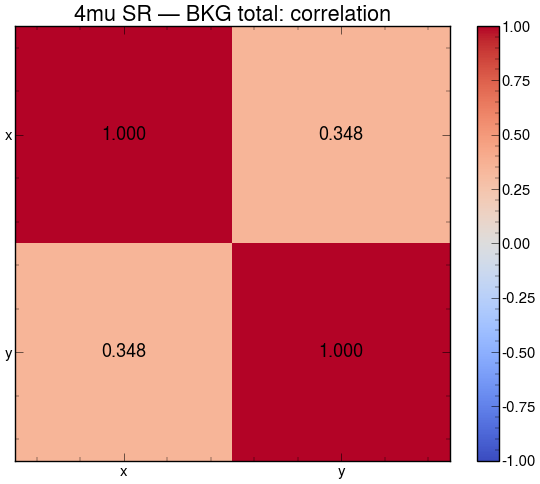

In [20]:
def hist2d_to_dataframe(h2d):
    x,y=np.meshgrid(h2d.axes[0].centers,h2d.axes[1].centers,indexing="ij")
    values,_=values_variances(h2d)
    return pd.DataFrame({"x":x.ravel(),"y":y.ravel(),"yield":values.ravel()})

def plot_correlation_profile(h2d,title):
    frame=hist2d_to_dataframe(h2d)
    positive=frame[np.isfinite(frame["yield"])&(frame["yield"]>0)].copy()
    folded_values,_=values_variances(h2d); corr=weighted_corr(h2d); values=folded_values.T
    pos=values[np.isfinite(values)&(values>0)]
    norm=LogNorm(vmin=max(pos.min(),1e-12),vmax=pos.max()) if pos.size else None
    fig,axes=plt.subplots(1,3,figsize=(36,12))
    mesh=axes[0].pcolormesh(h2d.axes[0].edges,h2d.axes[1].edges,values,shading="auto",cmap="viridis",norm=norm)
    fig.colorbar(mesh,ax=axes[0],label="Events")
    axes[0].set(title=f"2D yield; corr={corr:.3f}",xlabel="x isolation",ylabel="y isolation")
    if not positive.empty:
        xp=pd.Series({value:np.average(group["y"],weights=group["yield"])
                      for value,group in positive.groupby("x")})
        yp=pd.Series({value:np.average(group["x"],weights=group["yield"])
                      for value,group in positive.groupby("y")})
        axes[1].plot(xp.index,xp.values,marker="o"); axes[2].plot(yp.index,yp.values,marker="o")
    axes[1].set(xlabel="x isolation",ylabel="weighted mean y",title="<y> versus x")
    axes[2].set(xlabel="y isolation",ylabel="weighted mean x",title="<x> versus y")
    fig.suptitle(title); fig.tight_layout()
    mf,ma=plt.subplots(figsize=(12,10)); matrix=np.array([[1.,corr],[corr,1.]])
    im=ma.imshow(matrix,vmin=-1,vmax=1,cmap="coolwarm")
    for i in range(2):
        for j in range(2): ma.text(j,i,f"{matrix[i,j]:.3f}",ha="center",va="center")
    ma.set(xticks=[0,1],yticks=[0,1],xticklabels=["x","y"],yticklabels=["x","y"],title=f"{title}: correlation")
    mf.colorbar(im,ax=ma); mf.tight_layout()

for topology in CHANNEL_CONFIGS:
    for selection,group in [("VR","Data"),("VR","BKG total"),("SR","BKG total")]:
        h2d=group_hist(group,topology,selection)
        if h2d is not None:
            plot_correlation_profile(h2d,f"{topology} {selection} — {group}")
            plt.show(); plt.close("all")


## 15. Raw and κ-corrected SR predictions


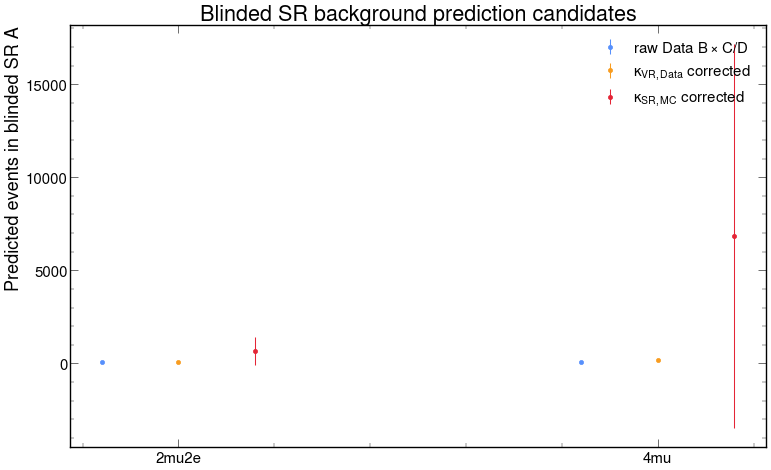

In [21]:
if not sr_prediction.empty:
    x=np.arange(len(sr_prediction)); fig,ax=plt.subplots(figsize=(16,10))
    ax.errorbar(x-.16,sr_prediction.raw_prediction,yerr=sr_prediction.raw_prediction_err,fmt="o",label=r"raw Data $B\times C/D$")
    ax.errorbar(x,sr_prediction.VR_Data_kappa_prediction,yerr=sr_prediction.VR_Data_kappa_prediction_err,fmt="o",label=r"$\kappa_{VR,Data}$ corrected")
    ax.errorbar(x+.16,sr_prediction.SR_MC_kappa_prediction,yerr=sr_prediction.SR_MC_kappa_prediction_err,fmt="o",label=r"$\kappa_{SR,MC}$ corrected")
    ax.set(xticks=x,xticklabels=sr_prediction.topology,ylabel="Predicted events in blinded SR A",
           title="Blinded SR background prediction candidates")
    ax.legend(frameon=False); fig.tight_layout(); plt.show(); plt.close()


## 16. Signal parameter-space summary and leakage

conditional_VR_fraction = N_VR / (N_SR + N_VR)은 SR과 tight anti-SR VR만을 분모로 하는 조건부 지표다.
두 selection은 complementary하지 않으므로 전체 migration 또는 전체 leakage로 해석하지 않는다.

SR region fraction은 isolation plane 내부의 조건부 fraction이며 generated-event denominator 기반 selection efficiency가 아니다.
Expected yield와 S/B는 coffea payload에 저장된 signal normalization을 그대로 사용한다.


In [22]:
import re

SIGNAL_LOW_STAT_NEFF = 10.0
SIGNAL_NAME_PATTERN = re.compile(
    r"^(?P<topology>2Mu2E|4Mu)_(?P<mA>[0-9p]+)GeV_"
    r"(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$"
)

def decode_sample_number(token):
    return float(token.replace("p", "."))

def parse_signal_point(sample):
    match = SIGNAL_NAME_PATTERN.match(sample.split(":")[0])
    if match is None:
        raise ValueError(f"Unrecognized signal sample: {sample}")
    fields = match.groupdict()
    return {
        "topology": "2mu2e" if fields["topology"] == "2Mu2E" else "4mu",
        "mA_GeV": decode_sample_number(fields["mA"]),
        "mZd_GeV": decode_sample_number(fields["mZd"]),
        "ctau_mm": decode_sample_number(fields["ctau"]),
    }

def region_weight_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(), 0, None))
        result[region] = {
            "yield": value,
            "variance": variance,
            "neff": value**2 / variance if variance > 0 else np.nan,
        }
    return result

def total_weight_stats(h2d):
    values, variances = values_variances(h2d)
    value = float(values.sum())
    variance = float(np.clip(variances.sum(), 0, None))
    return {"yield": value, "variance": variance,
            "neff": value**2 / variance if variance > 0 else np.nan}

def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator > 0 else np.nan

signal_rows = []
for sample in sample_groups.get("Signal", []):
    parameters = parse_signal_point(sample)
    topology = parameters["topology"]
    cuts = CHANNEL_CONFIGS[topology]["cuts"]
    sr_hist = group_hist(sample, topology, "SR")
    vr_hist = group_hist(sample, topology, "VR")
    if sr_hist is None and vr_hist is None:
        continue

    sr = region_weight_stats(sr_hist, cuts) if sr_hist is not None else {}
    vr = total_weight_stats(vr_hist) if vr_hist is not None else {
        "yield": 0.0, "variance": 0.0, "neff": np.nan}
    sr_total = sum(sr[r]["yield"] for r in "ABCD") if sr else 0.0
    bkg_hist = group_hist("BKG total", topology, "SR")
    bkg = abcd_yields(bkg_hist, cuts) if bkg_hist is not None else {}
    pred_b, _ = prediction(bkg) if bkg else (np.nan, np.nan)
    data_rows = abcd_summary[
        (abcd_summary.topology == topology)
        & (abcd_summary.selection == "SR")
        & (abcd_summary.group == "Data")]
    data = None if data_rows.empty else data_rows.iloc[0]

    row = {"signal": sample, **parameters,
           "SR_2D_expected_yield": sr_total,
           "VR_2D_expected_yield": vr["yield"],
           "conditional_VR_fraction": safe_ratio(vr["yield"], sr_total + vr["yield"]),
           "VR_neff": vr["neff"]}
    signal_yields, low_regions = {}, []
    for region in "ABCD":
        stats = sr.get(region, {"yield": 0.0, "variance": 0.0, "neff": np.nan})
        signal_yields[region] = stats["yield"]
        row[f"SR_{region}_expected_yield"] = stats["yield"]
        row[f"SR_{region}_fraction"] = safe_ratio(stats["yield"], sr_total)
        row[f"SR_{region}_variance"] = stats["variance"]
        row[f"SR_{region}_neff"] = stats["neff"]
        bval = bkg.get(region, (np.nan, np.nan))[0] if bkg else np.nan
        row[f"SR_{region}_over_BkgMC"] = (
            stats["yield"] / bval if np.isfinite(bval) and bval > 0 else np.nan)
        row[f"SR_{region}_over_Data"] = (
            stats["yield"] / data[region]
            if region != "A" and data is not None and data[region] > 0 else np.nan)
        if not np.isfinite(stats["neff"]) or stats["neff"] < SIGNAL_LOW_STAT_NEFF:
            low_regions.append(region)

    row["SR_ABCD_CR_leakage"] = safe_ratio(
        sum(signal_yields[r] for r in "BCD"), sr_total)
    combined = {
        r: (
            bkg[r][0] + signal_yields[r],
            np.sqrt(bkg[r][1]**2 + sr[r]["variance"]),
        )
        for r in "ABCD"
    } if bkg else {}
    pred_bs, _ = prediction(combined) if combined else (np.nan, np.nan)
    shift = pred_bs - pred_b
    row["A_pred_bkg"] = pred_b
    row["A_pred_bkg_plus_signal"] = pred_bs
    row["delta_ABCD"] = shift / pred_b if np.isfinite(shift) and pred_b > 0 else np.nan
    row["signal_absorption_fraction"] = (
        shift / signal_yields["A"]
        if np.isfinite(shift) and signal_yields["A"] > 0 else np.nan)
    row["low_stat_regions"] = ",".join(low_regions)
    row["low_stat_flag"] = bool(
        low_regions or not np.isfinite(vr["neff"]) or vr["neff"] < SIGNAL_LOW_STAT_NEFF)
    signal_rows.append(row)

signal_summary = pd.DataFrame(signal_rows).sort_values(
    ["topology", "mZd_GeV", "mA_GeV", "ctau_mm"]).reset_index(drop=True)
display(signal_summary)


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,SR_2D_expected_yield,VR_2D_expected_yield,conditional_VR_fraction,VR_neff,SR_A_expected_yield,...,SR_D_neff,SR_D_over_BkgMC,SR_D_over_Data,SR_ABCD_CR_leakage,A_pred_bkg,A_pred_bkg_plus_signal,delta_ABCD,signal_absorption_fraction,low_stat_regions,low_stat_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.016788,0.000114,0.006757,3.0,0.012676,...,1.0,1.039071e-07,1.248098e-07,0.244898,10.901406,10.902799,0.000128,0.109850,"B,D",True
1,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,0.160779,0.000167,0.001035,5.0,0.125839,...,6.0,5.455064e-07,6.552440e-07,0.217319,10.901406,10.913393,0.001100,0.095260,D,True
2,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,200.0,0.25,1.00,0.852844,0.000066,0.000078,1.0,0.672548,...,46.0,8.319784e-06,9.993446e-06,0.211405,10.901406,10.960599,0.005430,0.088013,,True
3,2Mu2E_200GeV_0p25GeV_5p0mm,2mu2e,200.0,0.25,5.00,0.370305,0.000024,0.000065,1.0,0.296027,...,88.0,5.804153e-06,6.971754e-06,0.200587,10.901406,10.924321,0.002102,0.077408,,True
4,2Mu2E_200GeV_0p25GeV_10p0mm,2mu2e,200.0,0.25,10.00,0.195610,0.000000,0.000000,NaN,0.154627,...,11.0,5.373547e-06,6.454525e-06,0.209515,10.901406,10.913602,0.001119,0.078874,,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,4Mu_1000GeV_5p0GeV_0p04mm,4mu,1000.0,5.00,0.04,0.019965,0.000382,0.018779,4.0,0.019488,...,NaN,0.000000e+00,0.000000e+00,0.023923,0.042011,0.042026,0.000339,0.000732,"B,C,D",True
116,4Mu_1000GeV_5p0GeV_0p4mm,4mu,1000.0,5.00,0.40,0.533672,0.001253,0.002342,12.0,0.526363,...,NaN,0.000000e+00,0.000000e+00,0.013696,0.042011,0.042206,0.004624,0.000369,"B,D",True
117,4Mu_1000GeV_5p0GeV_4p0mm,4mu,1000.0,5.00,4.00,4.476348,0.000529,0.000118,7.0,4.406273,...,5.0,1.176854e-05,1.049911e-05,0.015655,0.042011,0.043841,0.043544,0.000415,D,True
118,4Mu_1000GeV_5p0GeV_20p0mm,4mu,1000.0,5.00,20.00,1.480334,0.000287,0.000194,3.0,1.426963,...,5.0,1.489056e-05,1.328436e-05,0.036053,0.042011,0.043449,0.034207,0.001007,D,True


## 17. Signal leakage and yield parameter maps

각 topology와 mediator mass별로 x축은 mA, y축은 ctau(log scale)다.
빈 point와 zero-yield low-stat point를 물리적인 zero leakage로 단정하지 않는다.


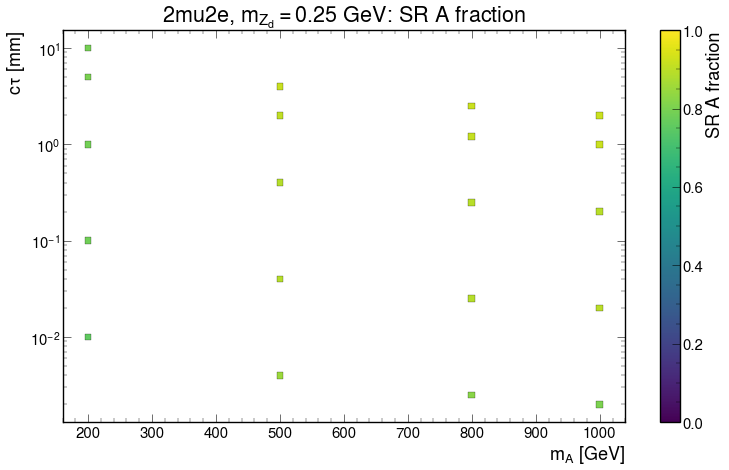

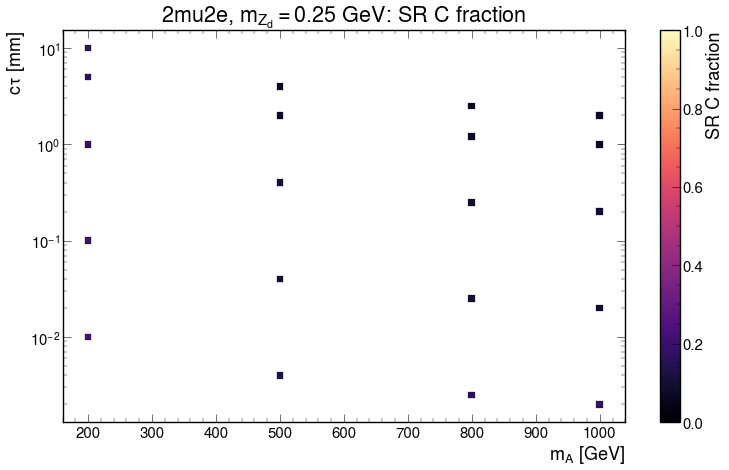

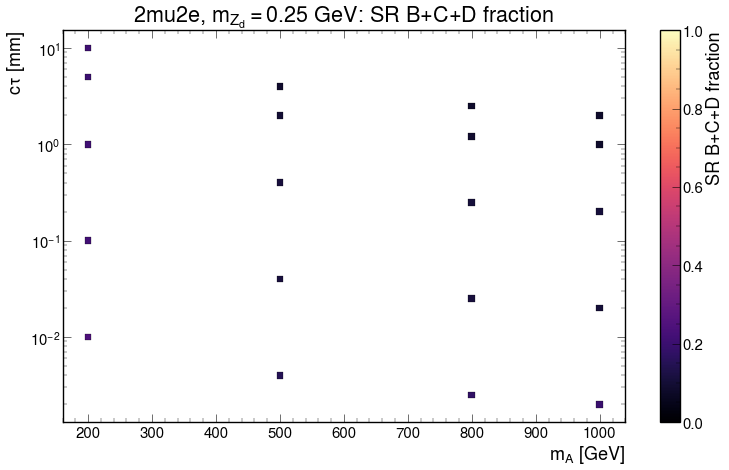

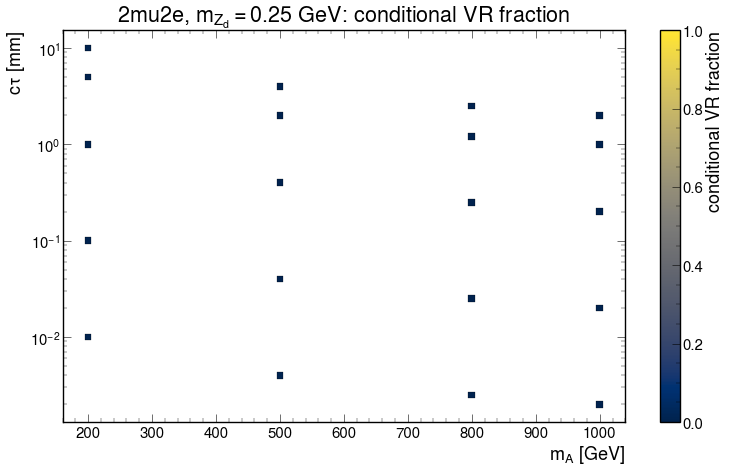

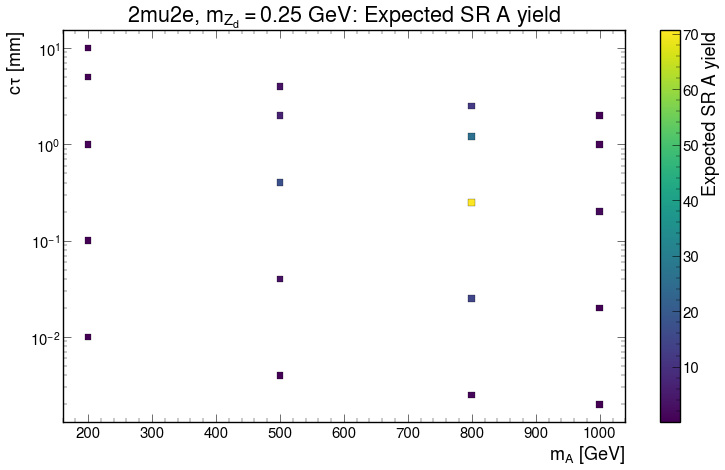

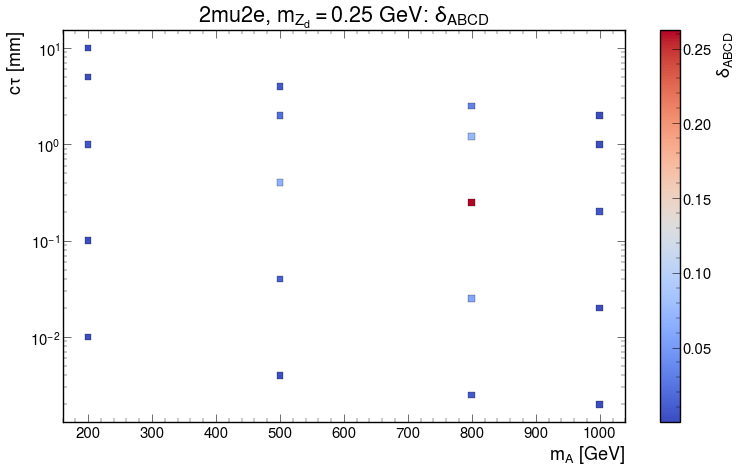

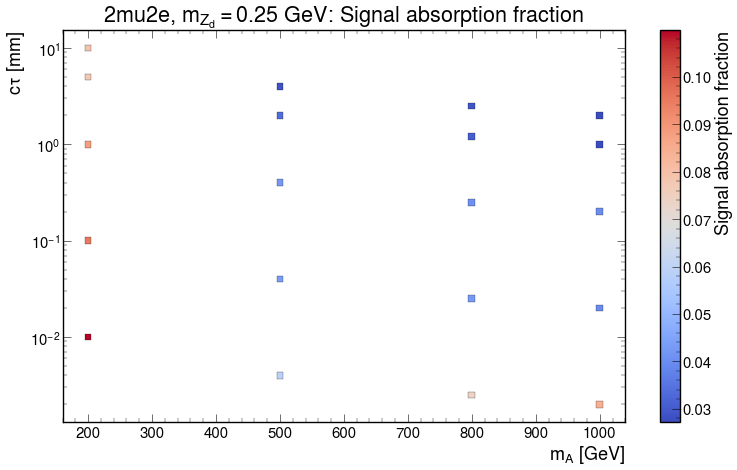

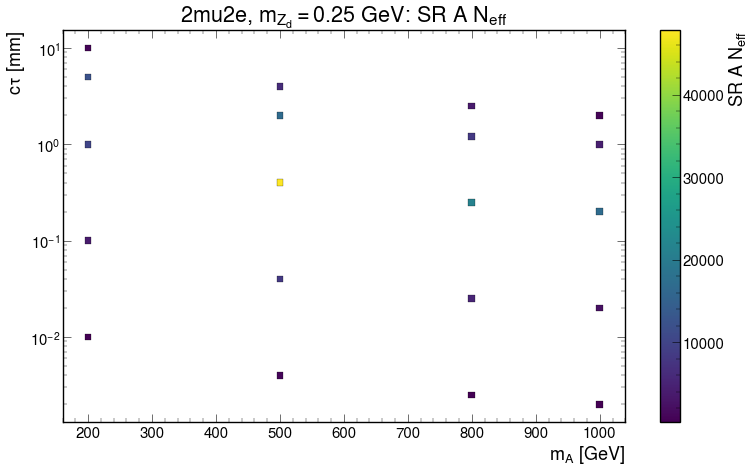

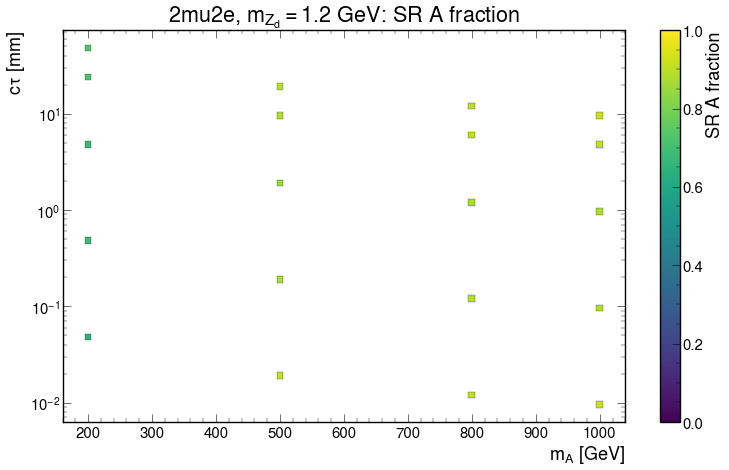

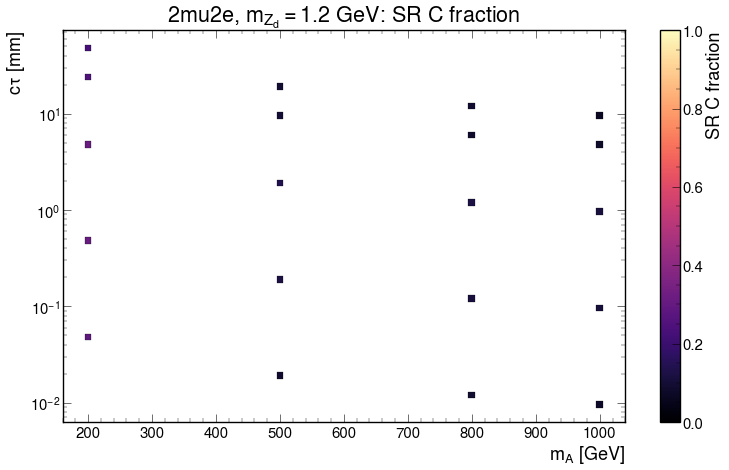

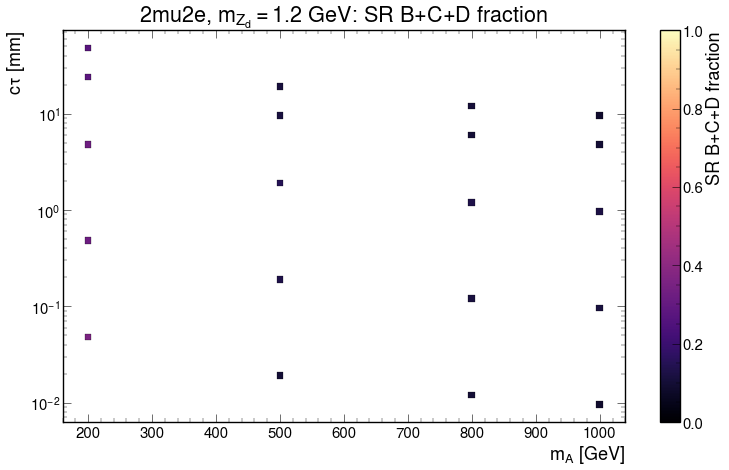

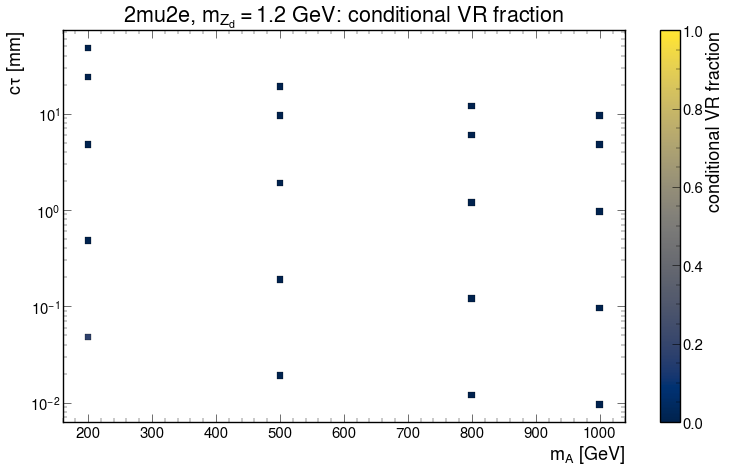

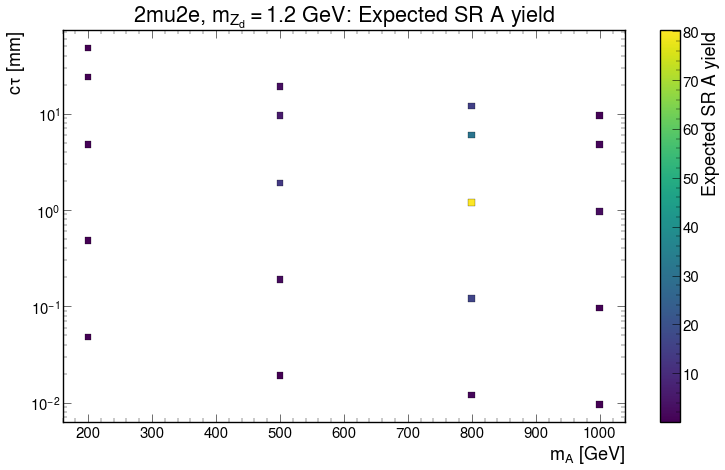

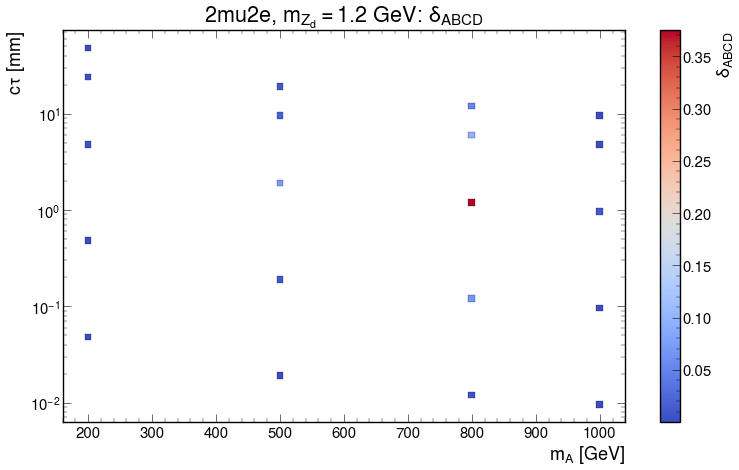

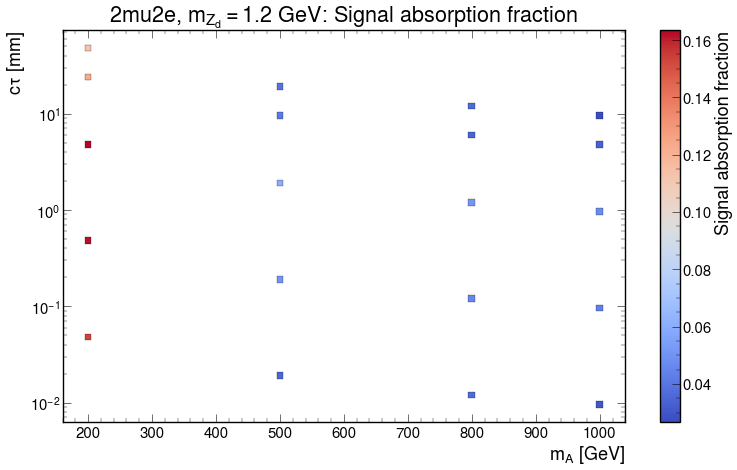

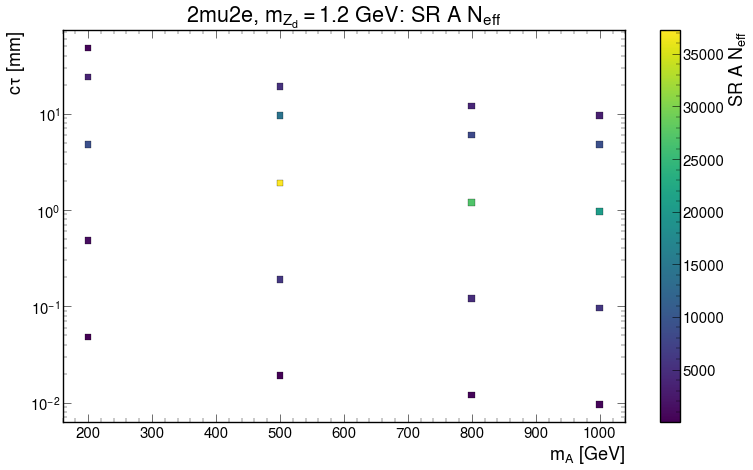

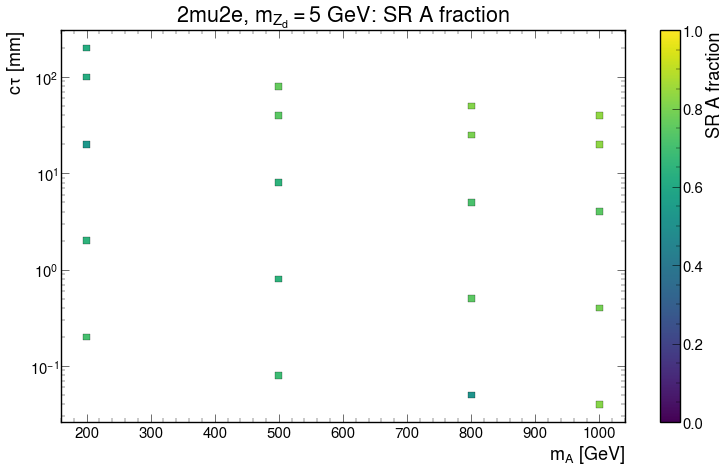

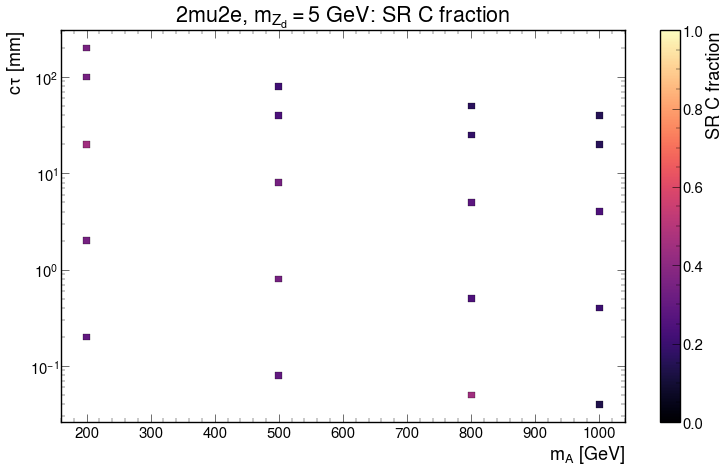

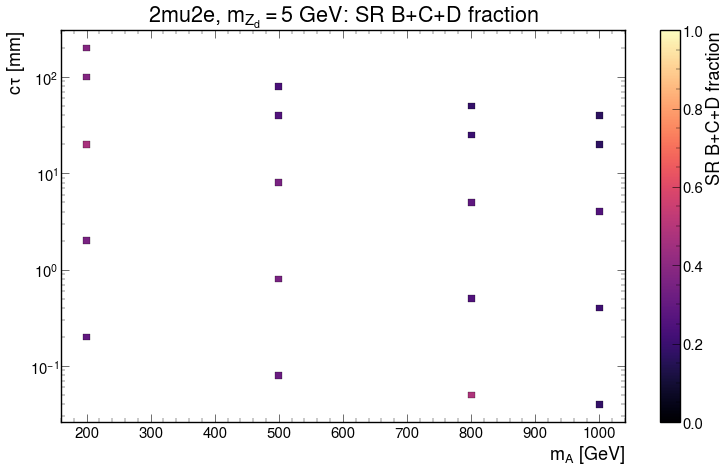

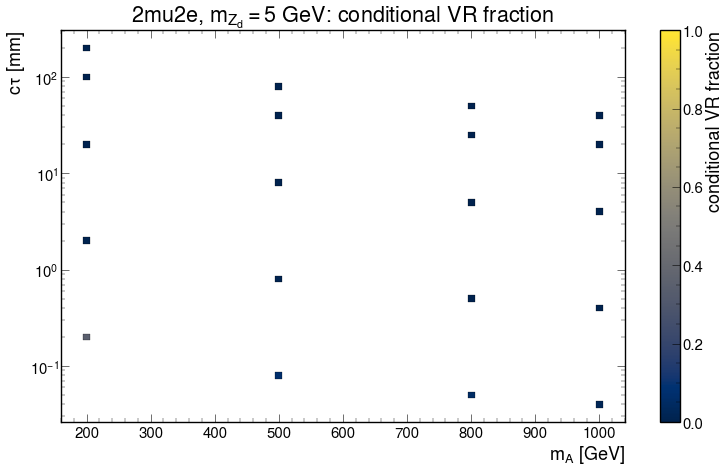

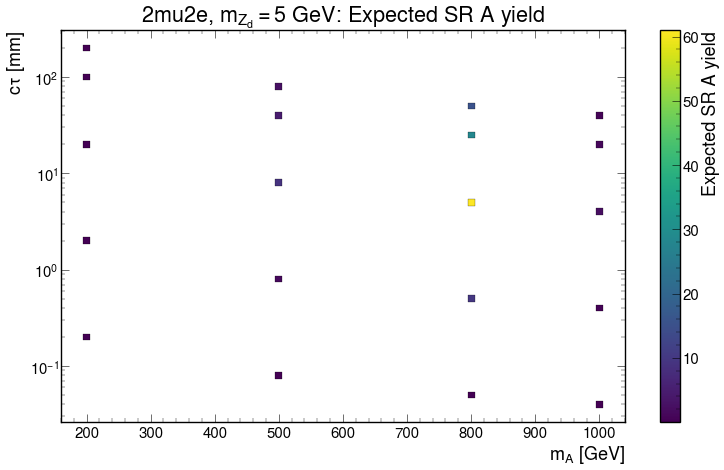

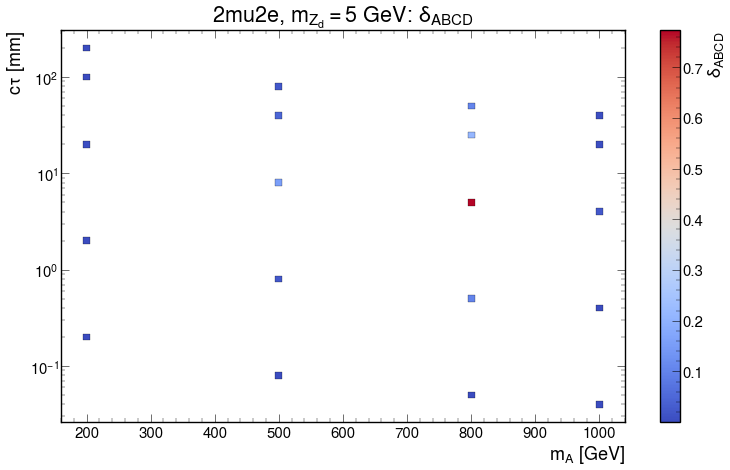

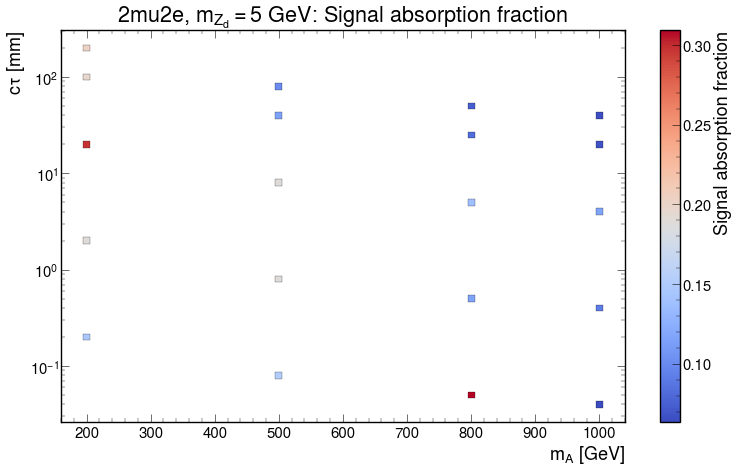

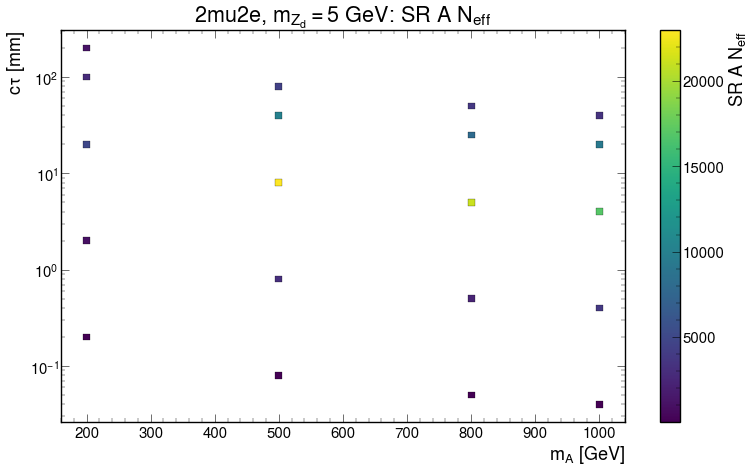

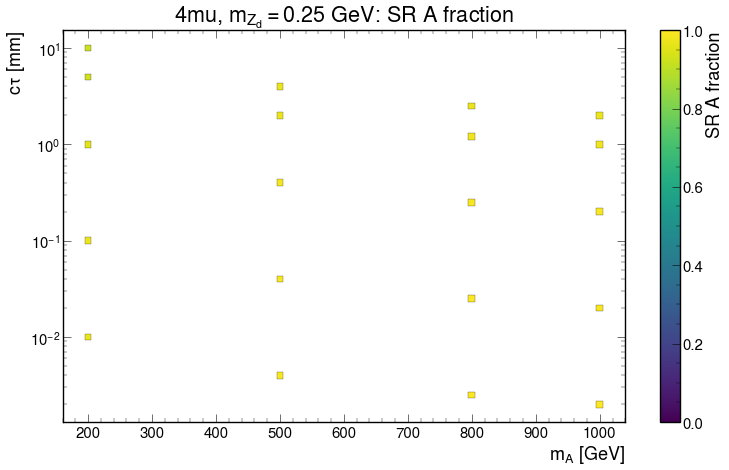

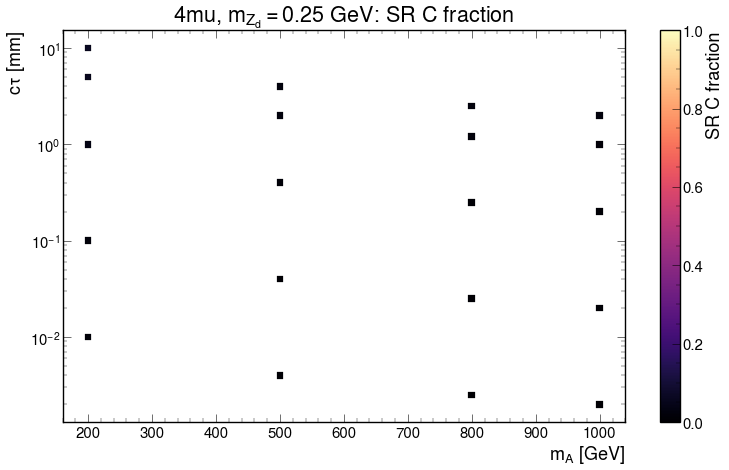

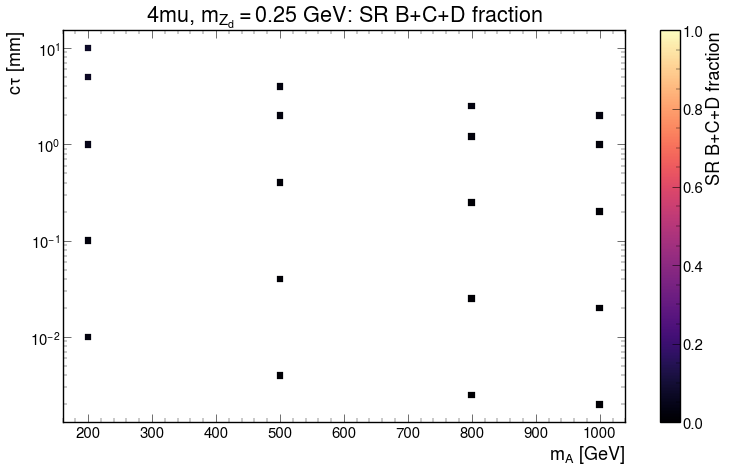

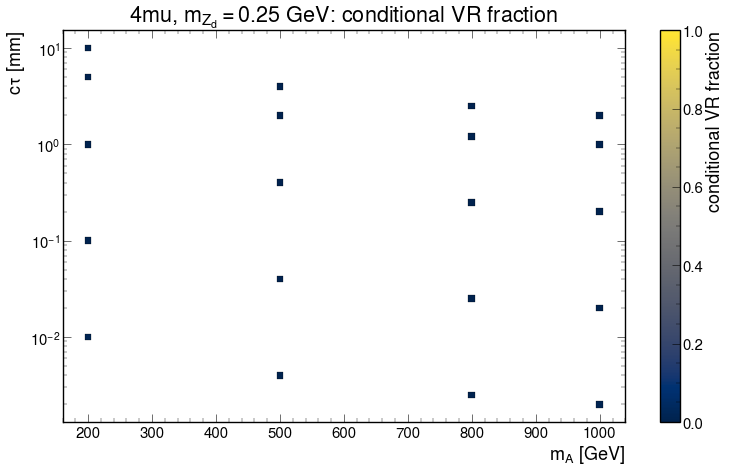

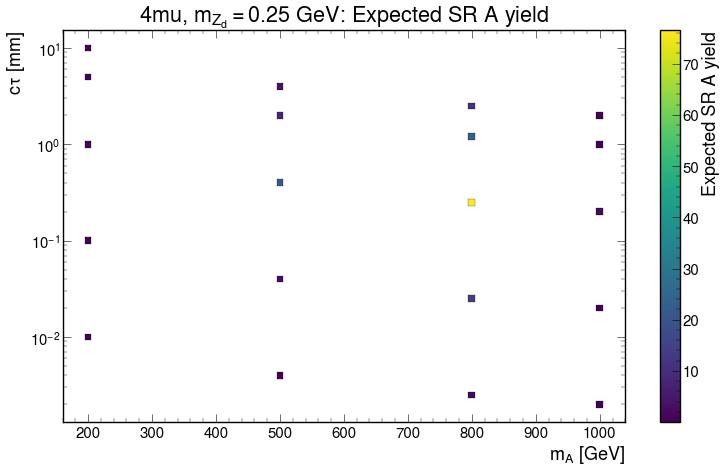

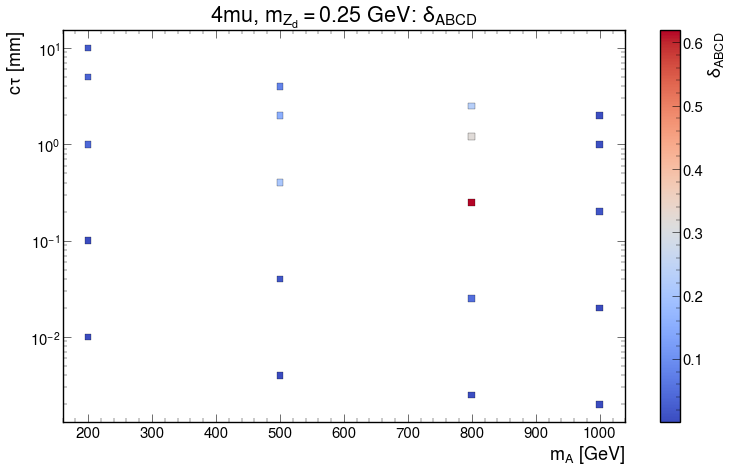

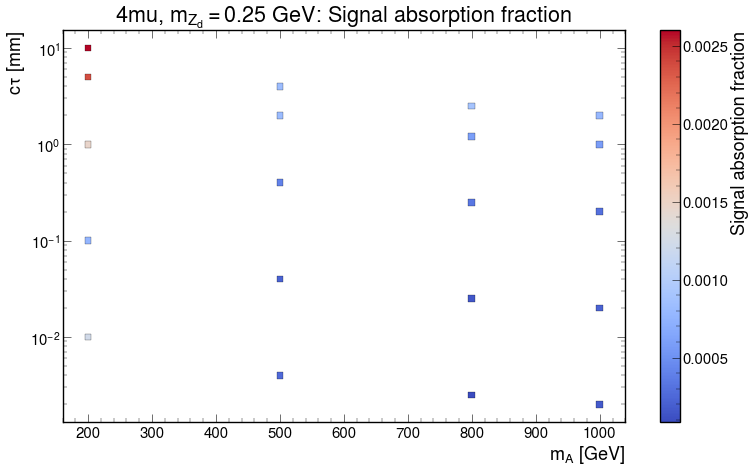

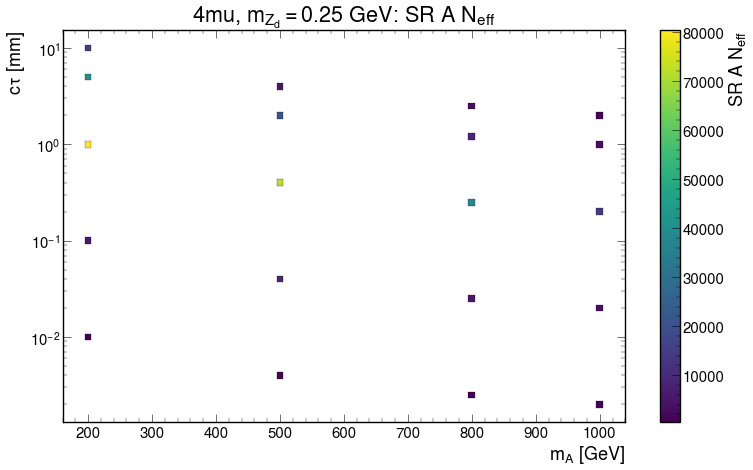

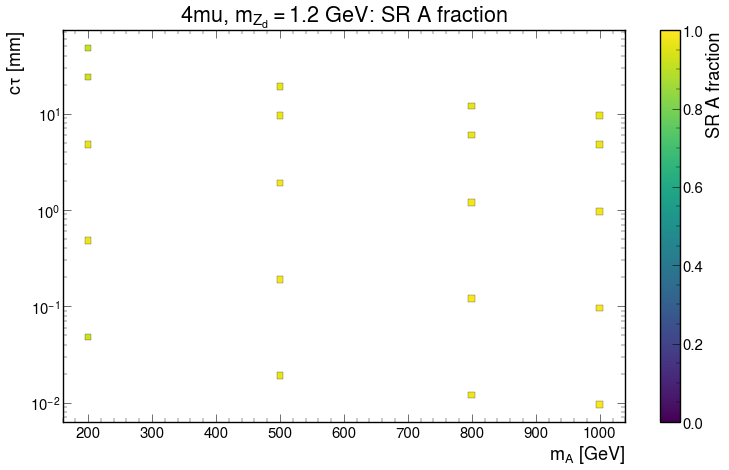

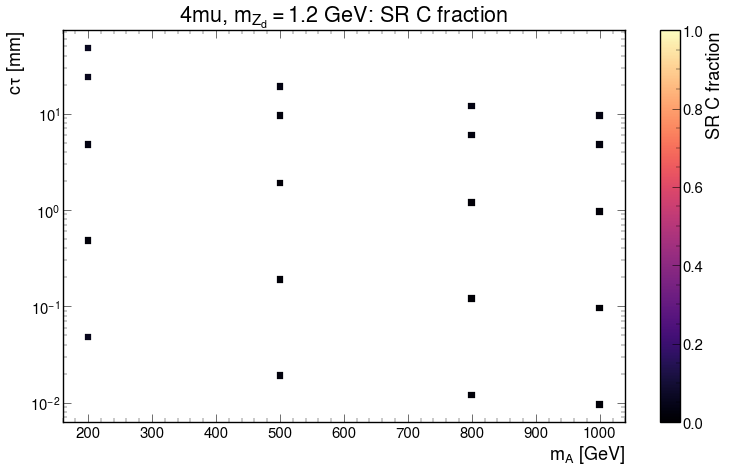

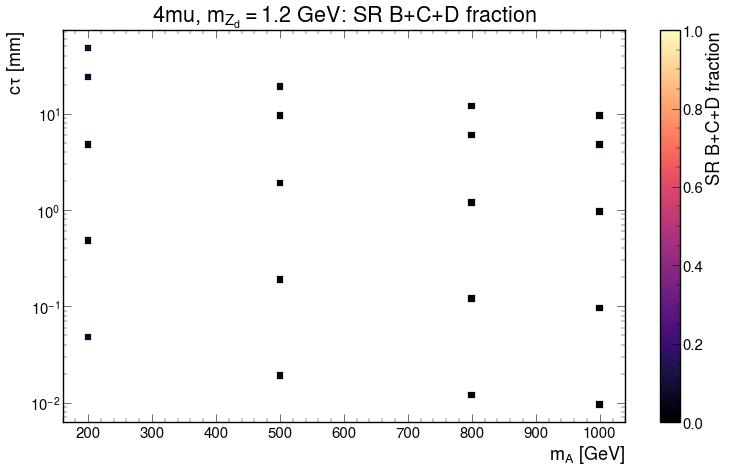

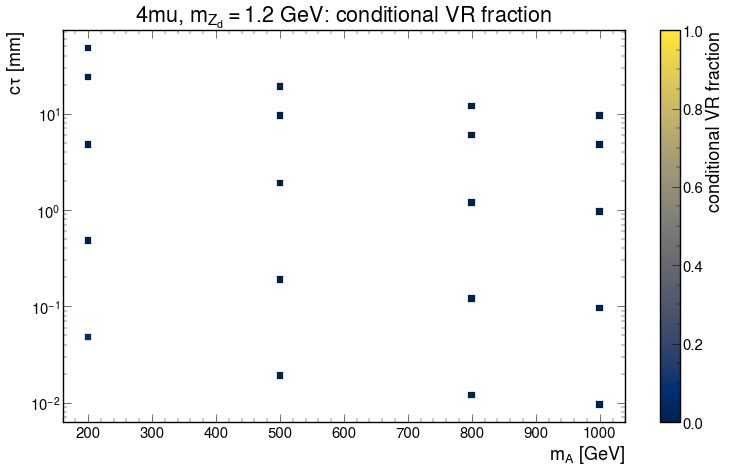

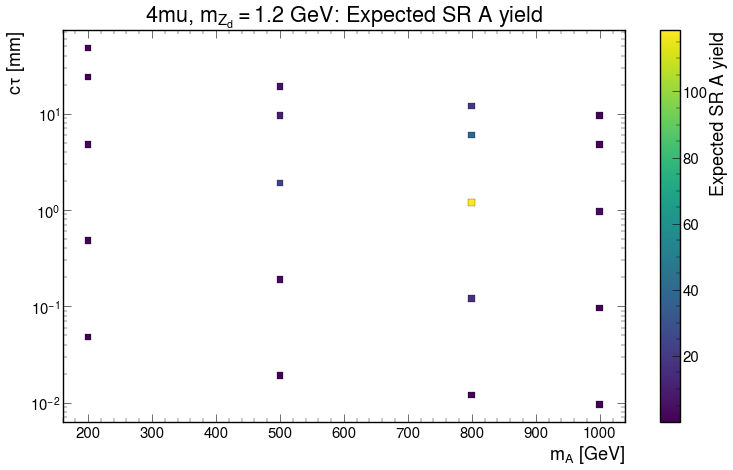

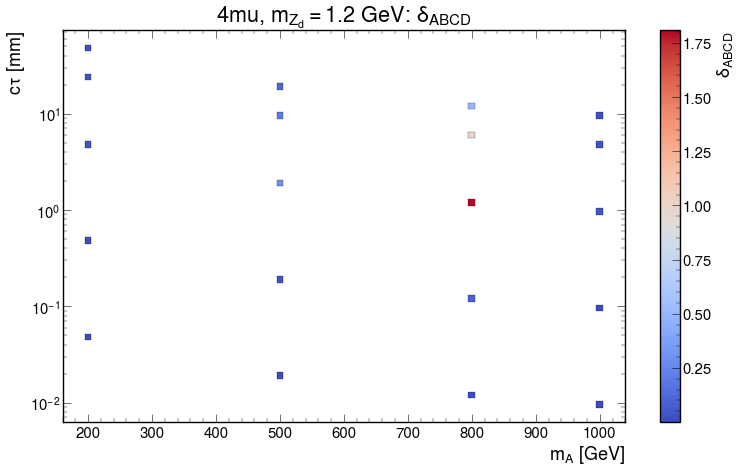

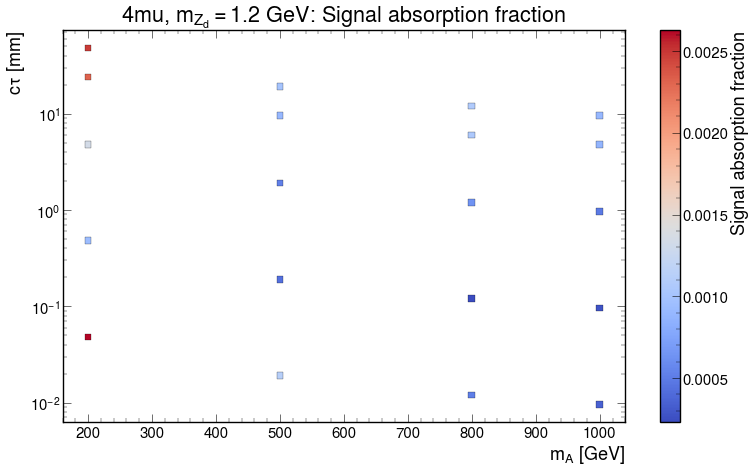

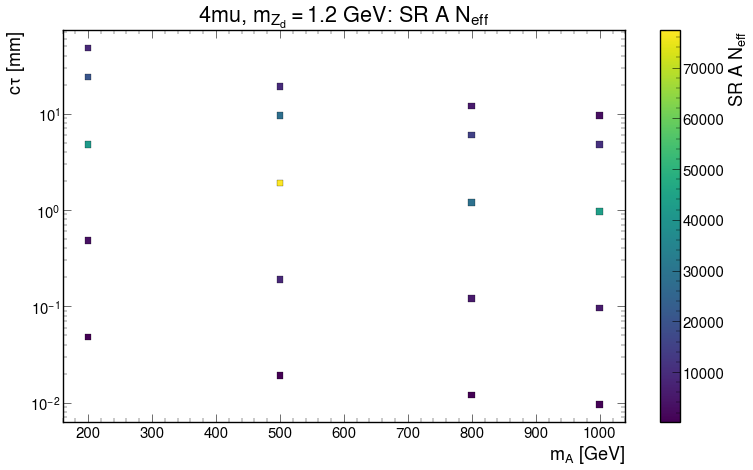

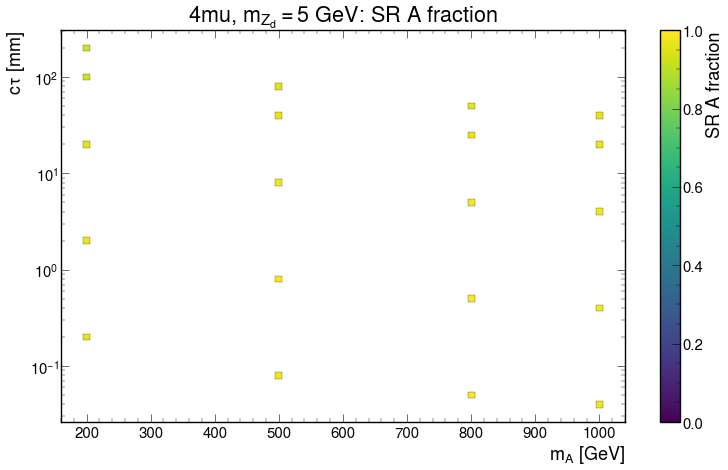

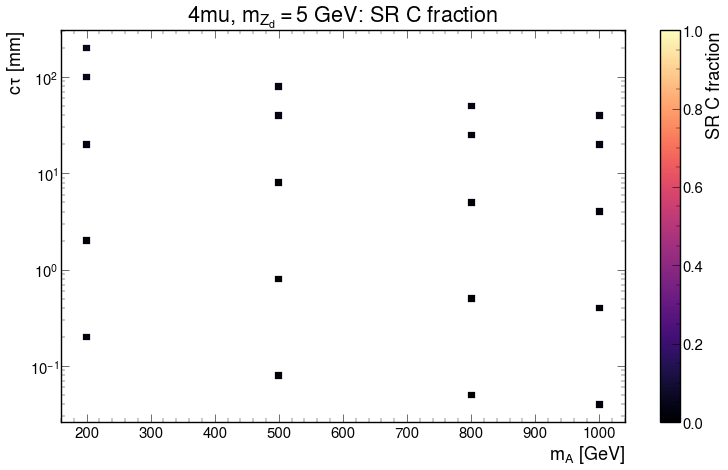

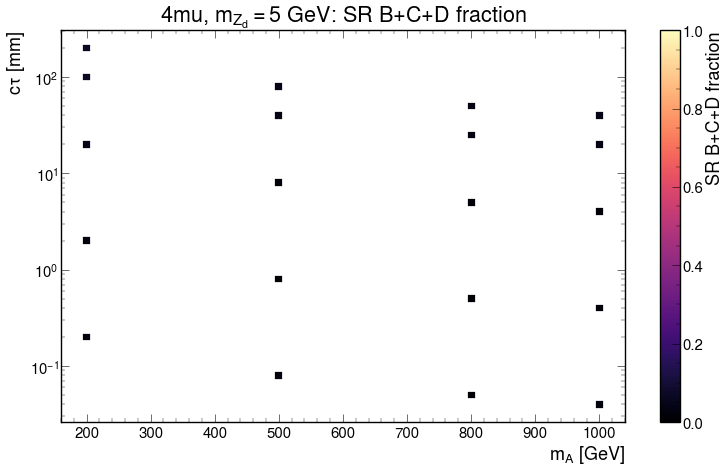

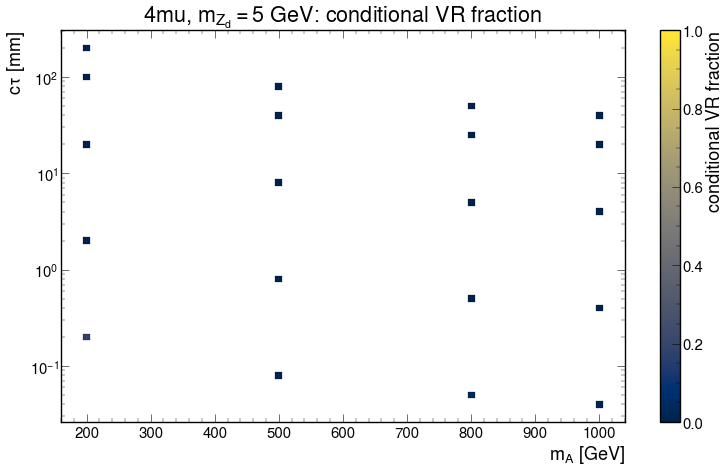

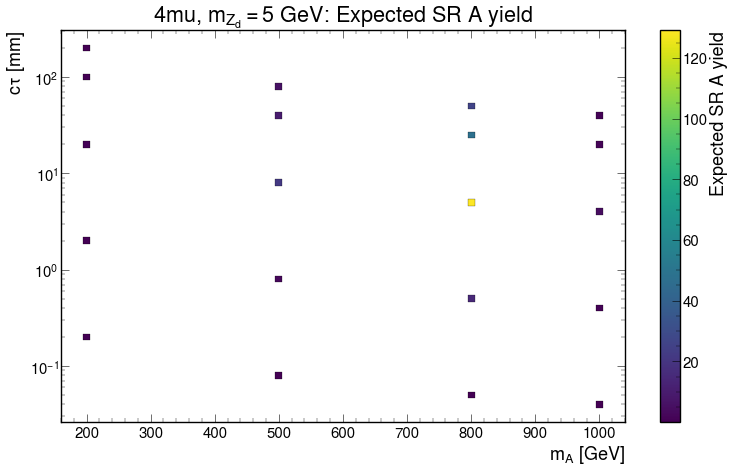

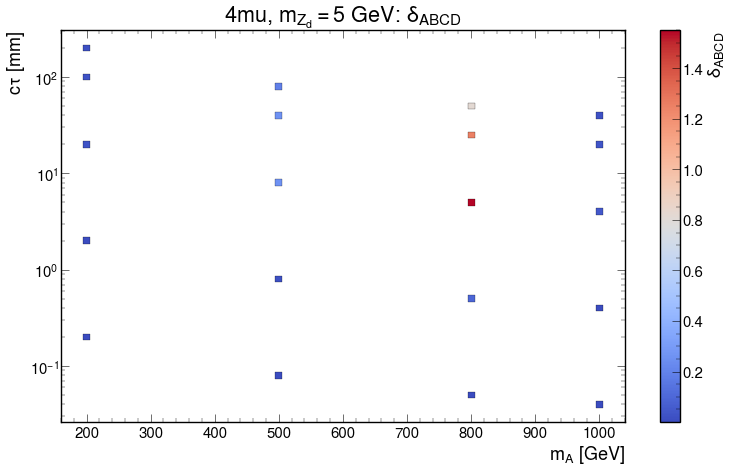

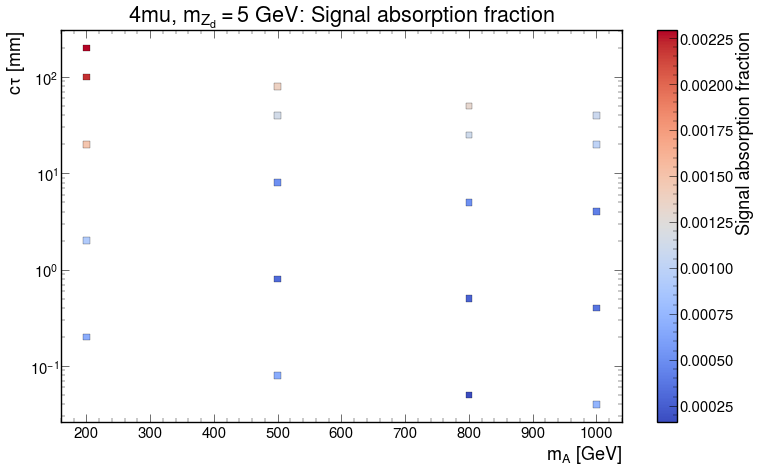

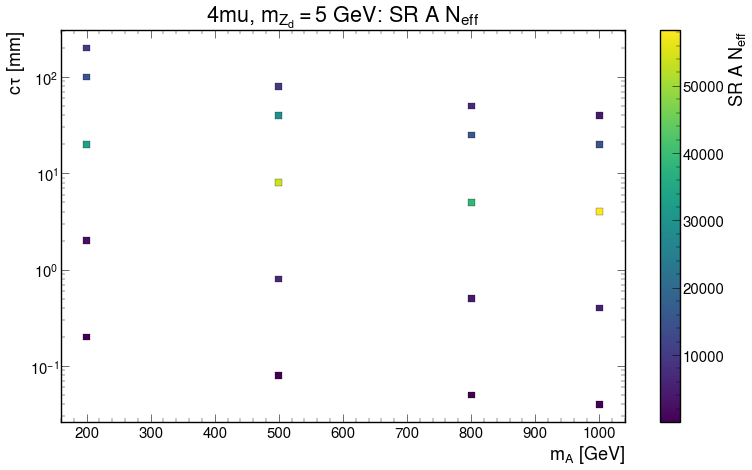

In [23]:
def plot_signal_parameter_map(frame, value, label, cmap="viridis", vmin=None, vmax=None):
    finite = frame[np.isfinite(frame[value]) & (frame.ctau_mm > 0)].copy()
    if finite.empty:
        return None
    fig, ax = plt.subplots(figsize=(16, 10))
    points = ax.scatter(finite.mA_GeV, finite.ctau_mm, c=finite[value],
                        s=95, marker="s", cmap=cmap, vmin=vmin, vmax=vmax,
                        edgecolor="black", linewidth=0.35)
    ax.set_yscale("log")
    ax.set(xlabel=r"$m_A$ [GeV]", ylabel=r"$c\tau$ [mm]",
           title=f"{finite.topology.iloc[0]}, $m_{{Z_d}}={finite.mZd_GeV.iloc[0]:g}$ GeV: {label}")
    fig.colorbar(points, ax=ax, label=label)
    fig.tight_layout()
    return fig, ax

SIGNAL_PARAMETER_MAPS = [
    ("SR_A_fraction", "SR A fraction", "viridis", 0, 1),
    ("SR_C_fraction", "SR C fraction", "magma", 0, 1),
    ("SR_ABCD_CR_leakage", "SR B+C+D fraction", "magma", 0, 1),
    ("conditional_VR_fraction", "conditional VR fraction", "cividis", 0, 1),
    ("SR_A_expected_yield", "Expected SR A yield", "viridis", None, None),
    ("delta_ABCD", r"$\delta_{ABCD}$", "coolwarm", None, None),
    ("signal_absorption_fraction", "Signal absorption fraction", "coolwarm", None, None),
    ("SR_A_neff", r"SR A $N_{eff}$", "viridis", None, None),
]
for (_, _), frame in signal_summary.groupby(["topology", "mZd_GeV"]):
    for value, label, cmap, vmin, vmax in SIGNAL_PARAMETER_MAPS:
        if plot_signal_parameter_map(frame, value, label, cmap, vmin, vmax) is not None:
            plt.show()
            plt.close()


## 18. Signal isolation working-point robustness

SR signal과 SR background MC만 사용하며 SR Data A는 사용하지 않는다.
각 point와 cut 조합별 A fraction, control leakage, expected A yield, S/sqrt(Bpred), ABCD bias, effective statistics를 저장한다.


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,xcut,ycut,SR_A_fraction,SR_ABCD_CR_leakage,SR_A_expected_yield,S_over_sqrt_Bpred,delta_ABCD,signal_absorption_fraction,SR_A_neff,SR_B_neff,SR_C_neff,SR_D_neff,low_stat_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.05,0.05,0.249433,0.750567,0.004187,0.001752,0.000123,0.168095,110.0,67.0,133.0,131.0,False
1,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.05,0.10,0.435374,0.564626,0.007309,0.032937,0.015847,0.106762,192.0,145.0,51.0,53.0,False
2,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.05,0.15,0.473923,0.526077,0.007956,0.031373,0.010574,0.085471,209.0,164.0,34.0,34.0,False
3,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.05,0.20,0.507937,0.492063,0.008527,0.037542,0.007761,0.046955,224.0,174.0,19.0,24.0,False
4,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.05,0.25,0.514739,0.485261,0.008641,0.035794,0.006538,0.044094,227.0,174.0,16.0,24.0,False


Signal WP scan rows: 7680


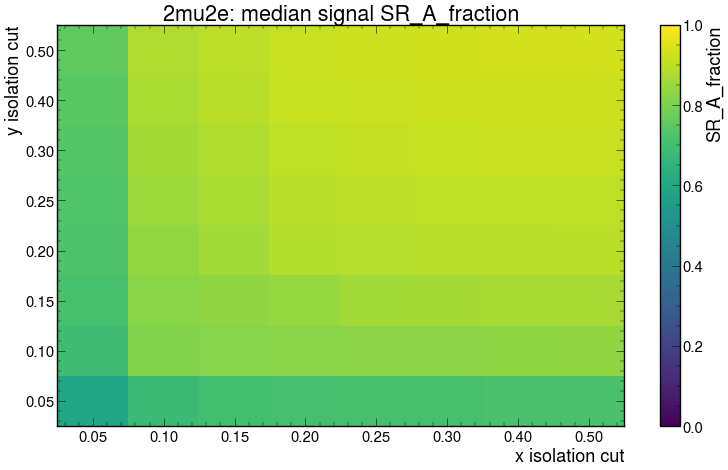

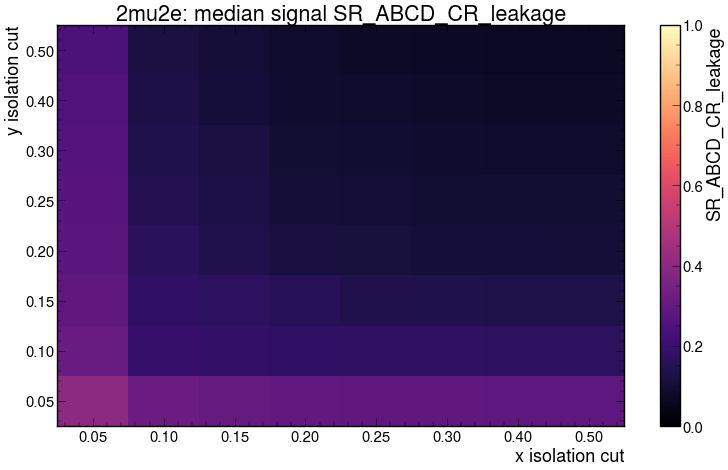

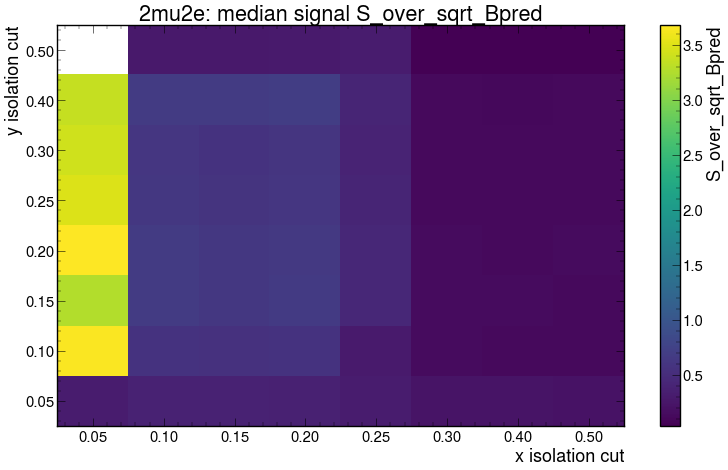

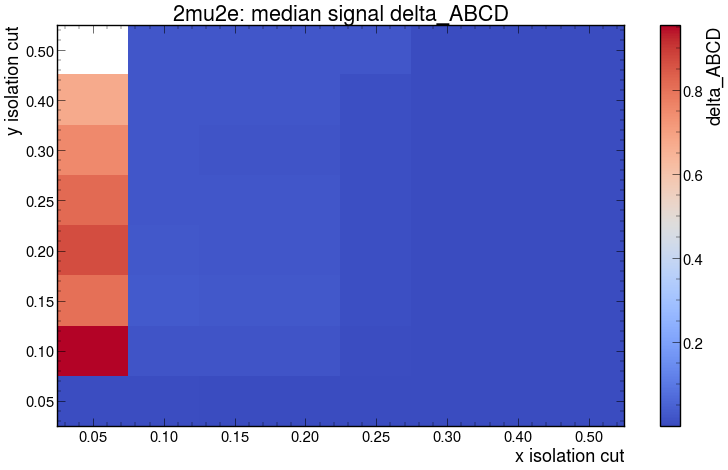

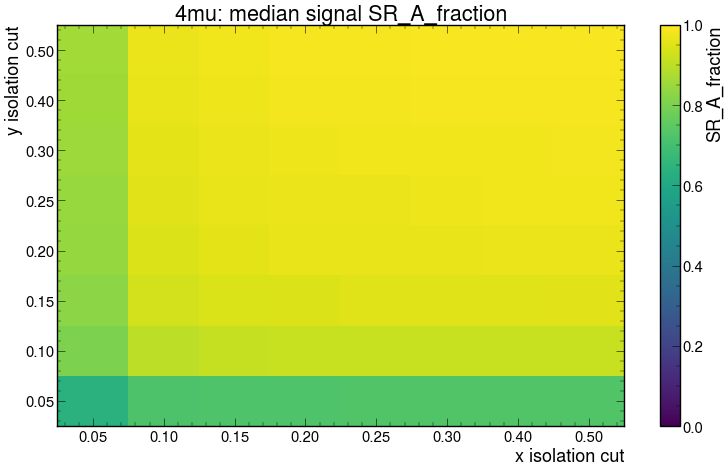

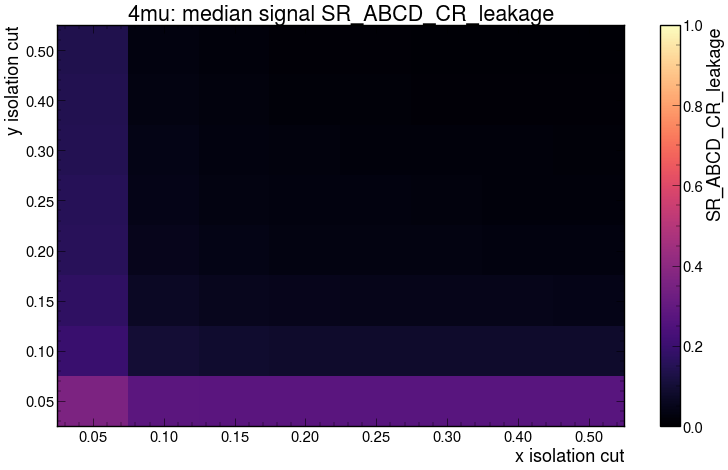

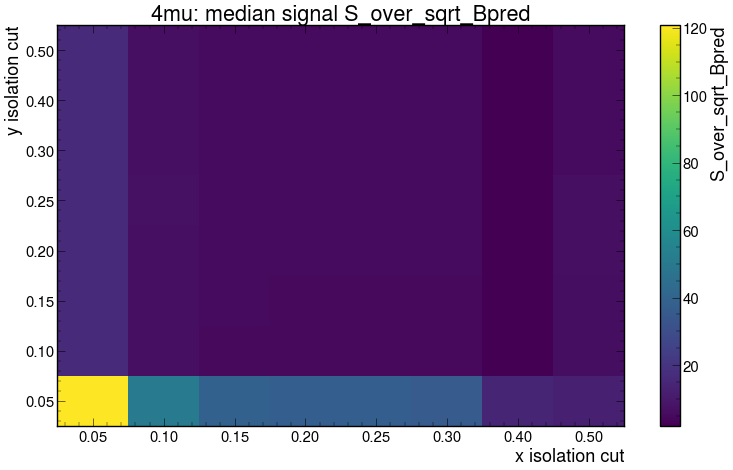

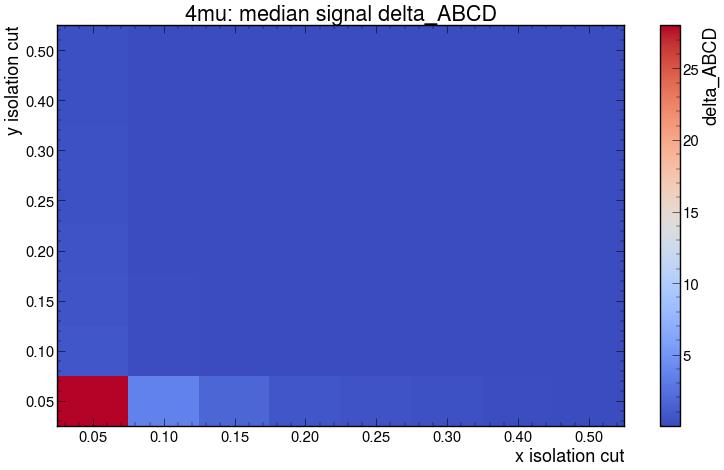

In [24]:
def signal_working_point_row(sample, parameters, signal_hist, bkg_hist, xcut, ycut):
    cuts = (xcut, ycut)
    sig = region_weight_stats(signal_hist, cuts)
    bkg = abcd_yields(bkg_hist, cuts)
    sigvals = {r: sig[r]["yield"] for r in "ABCD"}
    total = sum(sigvals.values())
    pred_b, _ = prediction(bkg)
    combined = {
        r: (
            bkg[r][0] + sigvals[r],
            np.sqrt(bkg[r][1]**2 + sig[r]["variance"]),
        )
        for r in "ABCD"
    }
    pred_bs, _ = prediction(combined)
    shift = pred_bs - pred_b
    row = {"signal": sample, **parameters, "xcut": xcut, "ycut": ycut,
           "SR_A_fraction": safe_ratio(sigvals["A"], total),
           "SR_ABCD_CR_leakage": safe_ratio(sum(sigvals[r] for r in "BCD"), total),
           "SR_A_expected_yield": sigvals["A"],
           "S_over_sqrt_Bpred": (
               sigvals["A"] / np.sqrt(pred_b)
               if np.isfinite(pred_b) and pred_b > 0 else np.nan),
           "delta_ABCD": shift / pred_b if np.isfinite(shift) and pred_b > 0 else np.nan,
           "signal_absorption_fraction": (
               shift / sigvals["A"]
               if np.isfinite(shift) and sigvals["A"] > 0 else np.nan)}
    for region in "ABCD":
        row[f"SR_{region}_neff"] = sig[region]["neff"]
    row["low_stat_flag"] = any(
        not np.isfinite(sig[r]["neff"]) or sig[r]["neff"] < SIGNAL_LOW_STAT_NEFF
        for r in "ABCD")
    return row

signal_wp_rows = []
for sample in sample_groups.get("Signal", []):
    pars = parse_signal_point(sample)
    topology = pars["topology"]
    sh = group_hist(sample, topology, "SR")
    bh = group_hist("BKG total", topology, "SR")
    if sh is None or bh is None:
        continue
    for xcut in SCAN_VALUES:
        for ycut in SCAN_VALUES:
            signal_wp_rows.append(signal_working_point_row(
                sample, pars, sh, bh, xcut, ycut))
signal_wp_scan = pd.DataFrame(signal_wp_rows)
display(signal_wp_scan.head())
print(f"Signal WP scan rows: {len(signal_wp_scan)}")

def plot_signal_wp_median(frame, value, topology, cmap="viridis", vmin=None, vmax=None):
    table = frame.pivot_table(index="ycut", columns="xcut", values=value, aggfunc="median")
    fig, ax = plt.subplots(figsize=(16, 10))
    image = ax.imshow(table.values, origin="lower", aspect="auto",
                      cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    ax.set(xlabel="x isolation cut", ylabel="y isolation cut",
           title=f"{topology}: median signal {value}")
    fig.colorbar(image, ax=ax, label=value)
    fig.tight_layout()

if not signal_wp_scan.empty:
    for topology, frame in signal_wp_scan.groupby("topology"):
        for value, cmap, vmin, vmax in [
            ("SR_A_fraction", "viridis", 0, 1),
            ("SR_ABCD_CR_leakage", "magma", 0, 1),
            ("S_over_sqrt_Bpred", "viridis", None, None),
            ("delta_ABCD", "coolwarm", None, None)]:
            plot_signal_wp_median(frame, value, topology, cmap, vmin, vmax)
            plt.show()
            plt.close()


## 19. Final blinded full-analysis summary

아래 네 표를 저장하면 첫 production test에서 필요한 핵심 진단이 남는다.

- VR Data/MC closure
- SR/VR MC transferability
- blinded SR prediction candidates
- signal leakage

In [25]:
print("VR closure")
display(vr_closure)
print("SR/VR MC transferability")
display(transfer_summary)
print("Blinded SR Data prediction")
display(sr_prediction)
print("Signal leakage")
display(signal_summary)

print("Pilot complete. Keep BLIND_SR_DATA_A=True until formal unblinding approval.")

VR closure


,topology,group,A,A_err,A_pred,A_pred_err,kappa,kappa_err,pull
4,2mu2e,BKG total,113.085248,19.670834,199.364557,53.855134,0.567228,0.182247,-1.504825
5,2mu2e,Data,260.000000,16.124515,362.667735,15.464493,0.716910,0.053956,-4.595346
16,4mu,BKG total,69.983675,19.234431,45.706950,27.672168,1.531139,1.018038,0.720371
17,4mu,Data,129.000000,11.357817,71.692650,5.660552,1.799348,0.212795,4.515865


SR/VR MC transferability


,topology,kappa_SR_MC,kappa_SR_MC_err,kappa_VR_MC,kappa_VR_MC_err,R_kappa_SR_over_VR,R_kappa_err
0,2mu2e,9.315533,10.151147,0.567228,0.182247,16.422895,18.657727
1,4mu,77.374368,114.049582,1.531139,1.018038,50.533876,81.714159


Blinded SR Data prediction


,topology,SR_Data_B,SR_Data_C,SR_Data_D,raw_prediction,raw_prediction_err,VR_Data_kappa_prediction,VR_Data_kappa_prediction_err,SR_MC_kappa_prediction,SR_MC_kappa_prediction_err
0,2mu2e,134.0,167.0,305.0,73.370492,9.489899,52.600014,7.871360,683.485239,750.022806
1,4mu,18.0,177.0,36.0,88.500000,26.399574,159.242265,51.098908,6847.631548,10298.004758


Signal leakage


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,SR_2D_expected_yield,VR_2D_expected_yield,conditional_VR_fraction,VR_neff,SR_A_expected_yield,...,SR_D_neff,SR_D_over_BkgMC,SR_D_over_Data,SR_ABCD_CR_leakage,A_pred_bkg,A_pred_bkg_plus_signal,delta_ABCD,signal_absorption_fraction,low_stat_regions,low_stat_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.016788,0.000114,0.006757,3.0,0.012676,...,1.0,1.039071e-07,1.248098e-07,0.244898,10.901406,10.902799,0.000128,0.109850,"B,D",True
1,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,0.160779,0.000167,0.001035,5.0,0.125839,...,6.0,5.455064e-07,6.552440e-07,0.217319,10.901406,10.913393,0.001100,0.095260,D,True
2,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,200.0,0.25,1.00,0.852844,0.000066,0.000078,1.0,0.672548,...,46.0,8.319784e-06,9.993446e-06,0.211405,10.901406,10.960599,0.005430,0.088013,,True
3,2Mu2E_200GeV_0p25GeV_5p0mm,2mu2e,200.0,0.25,5.00,0.370305,0.000024,0.000065,1.0,0.296027,...,88.0,5.804153e-06,6.971754e-06,0.200587,10.901406,10.924321,0.002102,0.077408,,True
4,2Mu2E_200GeV_0p25GeV_10p0mm,2mu2e,200.0,0.25,10.00,0.195610,0.000000,0.000000,NaN,0.154627,...,11.0,5.373547e-06,6.454525e-06,0.209515,10.901406,10.913602,0.001119,0.078874,,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,4Mu_1000GeV_5p0GeV_0p04mm,4mu,1000.0,5.00,0.04,0.019965,0.000382,0.018779,4.0,0.019488,...,NaN,0.000000e+00,0.000000e+00,0.023923,0.042011,0.042026,0.000339,0.000732,"B,C,D",True
116,4Mu_1000GeV_5p0GeV_0p4mm,4mu,1000.0,5.00,0.40,0.533672,0.001253,0.002342,12.0,0.526363,...,NaN,0.000000e+00,0.000000e+00,0.013696,0.042011,0.042206,0.004624,0.000369,"B,D",True
117,4Mu_1000GeV_5p0GeV_4p0mm,4mu,1000.0,5.00,4.00,4.476348,0.000529,0.000118,7.0,4.406273,...,5.0,1.176854e-05,1.049911e-05,0.015655,0.042011,0.043841,0.043544,0.000415,D,True
118,4Mu_1000GeV_5p0GeV_20p0mm,4mu,1000.0,5.00,20.00,1.480334,0.000287,0.000194,3.0,1.426963,...,5.0,1.489056e-05,1.328436e-05,0.036053,0.042011,0.043449,0.034207,0.001007,D,True


Pilot complete. Keep BLIND_SR_DATA_A=True until formal unblinding approval.


## 20. Control-region signal-to-background contamination

For every signal point, compare signal with MC background and observed Data in SR-B/C/D and VR-A/B/C/D. SR Data A remains blinded.


In [26]:
CONTAMINATION_METRICS = ('S_over_B_MC', 'S_over_N_Data', 'S_over_SplusB_MC')
contamination_rows = []
for sample in sample_groups.get('Signal', []):
    parameters = parse_signal_point(sample)
    topology = parameters['topology']
    cuts = CHANNEL_CONFIGS[topology]['cuts']
    for selection in ('SR', 'VR'):
        signal_hist = group_hist(sample, topology, selection)
        bkg_hist = group_hist('BKG total', topology, selection)
        data_hist = group_hist('Data', topology, selection)
        if signal_hist is None or bkg_hist is None:
            continue
        signal_stats = region_weight_stats(signal_hist, cuts)
        bkg_stats = region_weight_stats(bkg_hist, cuts)
        data_stats = region_weight_stats(data_hist, cuts) if data_hist is not None else {}
        regions = ('B', 'C', 'D') if selection == 'SR' else ('A', 'B', 'C', 'D')
        for region in regions:
            s = signal_stats[region]['yield']; b = bkg_stats[region]['yield']
            data_yield = data_stats.get(region, {}).get('yield', np.nan)
            contamination_rows.append({
                'signal': sample, **parameters, 'selection': selection, 'region': region,
                'signal_yield': s, 'signal_variance': signal_stats[region]['variance'],
                'signal_neff': signal_stats[region]['neff'],
                'background_mc_yield': b, 'background_mc_variance': bkg_stats[region]['variance'],
                'background_mc_neff': bkg_stats[region]['neff'], 'data_yield': data_yield,
                'S_over_B_MC': safe_ratio(s, b), 'S_over_N_Data': safe_ratio(s, data_yield),
                'S_over_SplusB_MC': safe_ratio(s, s+b),
                'small_background_flag': (not np.isfinite(b)) or b <= 0
                    or not np.isfinite(bkg_stats[region]['neff'])
                    or bkg_stats[region]['neff'] < SIGNAL_LOW_STAT_NEFF,
            })
control_contamination = pd.DataFrame(contamination_rows).sort_values(
    ['topology','mZd_GeV','mA_GeV','ctau_mm','selection','region']).reset_index(drop=True)
sr_bcd = control_contamination[control_contamination.selection == 'SR']
max_sr_bcd = (sr_bcd.groupby(['signal','topology','mA_GeV','mZd_GeV','ctau_mm'], as_index=False)
    .agg(max_SR_BCD_S_over_B_MC=('S_over_B_MC','max'),
         max_SR_BCD_S_over_N_Data=('S_over_N_Data','max'),
         any_small_background=('small_background_flag','any')))
display(control_contamination.head(12)); display(max_sr_bcd.head())
print('Contamination rows:', len(control_contamination))


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,selection,region,signal_yield,signal_variance,signal_neff,background_mc_yield,background_mc_variance,background_mc_neff,data_yield,S_over_B_MC,S_over_N_Data,S_over_SplusB_MC,small_background_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,SR,B,0.000152,5.796379e-09,4.0,129.012827,5216.720674,3.190569,134.0,1.180254e-06,1.136328e-06,1.180253e-06,True
1,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,SR,C,0.003921,1.492568e-07,103.0,30.956559,183.843276,5.212638,167.0,1.266581e-04,2.347844e-05,1.266421e-04,True
2,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,SR,D,0.000038,1.449095e-09,1.0,366.355785,24489.133121,5.480658,305.0,1.039071e-07,1.248098e-07,1.039071e-07,True
3,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR,A,0.000000,0.000000e+00,NaN,113.085248,386.941729,33.049610,260.0,0.000000e+00,0.000000e+00,0.000000e+00,False
4,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR,B,0.000000,0.000000e+00,NaN,890.624379,7776.448435,102.001806,1221.0,0.000000e+00,0.000000e+00,0.000000e+00,False
5,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR,C,0.000114,4.347285e-09,3.0,972.158455,36982.107996,25.555386,1298.0,1.174715e-07,8.798223e-08,1.174715e-07,False
6,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR,D,0.000000,0.000000e+00,NaN,4342.938543,453381.680496,41.600964,4370.0,0.000000e+00,0.000000e+00,0.000000e+00,False
7,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,SR,B,0.000899,2.995484e-08,27.0,129.012827,5216.720674,3.190569,134.0,6.970798e-06,6.711361e-06,6.970749e-06,True
8,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,SR,C,0.033841,1.127190e-06,1016.0,30.956559,183.843276,5.212638,167.0,1.093182e-03,2.026417e-04,1.091989e-03,True
9,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,SR,D,0.000200,6.656631e-09,6.0,366.355785,24489.133121,5.480658,305.0,5.455064e-07,6.552440e-07,5.455061e-07,True


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,max_SR_BCD_S_over_B_MC,max_SR_BCD_S_over_N_Data,any_small_background
0,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.000281,0.000052,True
1,2Mu2E_1000GeV_0p25GeV_0p02mm,2mu2e,1000.0,0.25,0.020,0.001312,0.000243,True
2,2Mu2E_1000GeV_0p25GeV_0p2mm,2mu2e,1000.0,0.25,0.200,0.006398,0.001186,True
3,2Mu2E_1000GeV_0p25GeV_1p0mm,2mu2e,1000.0,0.25,1.000,0.001458,0.000270,True
4,2Mu2E_1000GeV_0p25GeV_2p0mm,2mu2e,1000.0,0.25,2.000,0.000727,0.000135,True


Contamination rows: 840


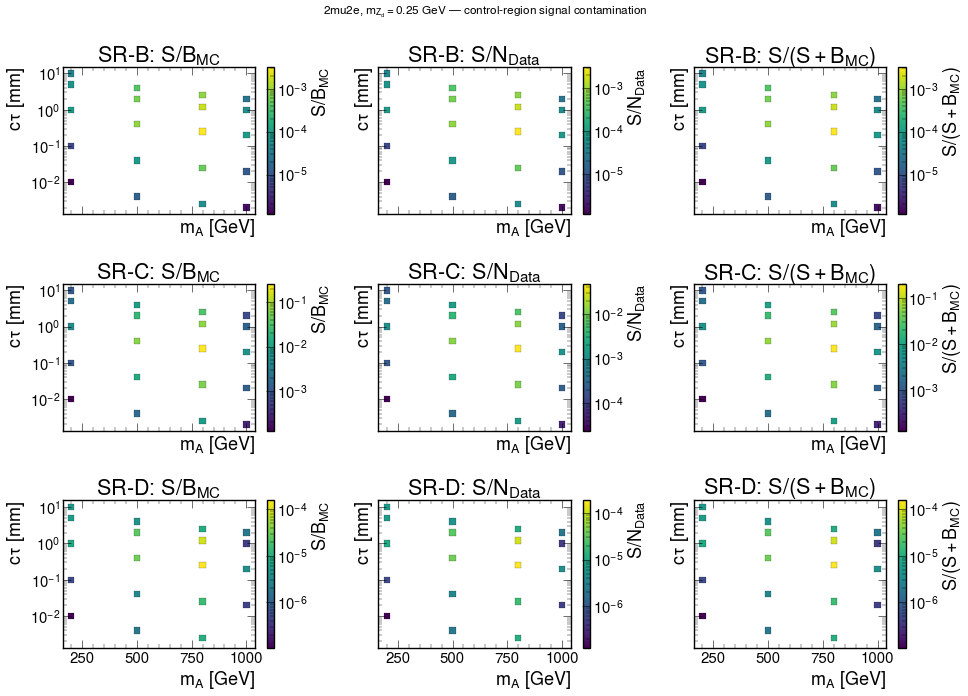

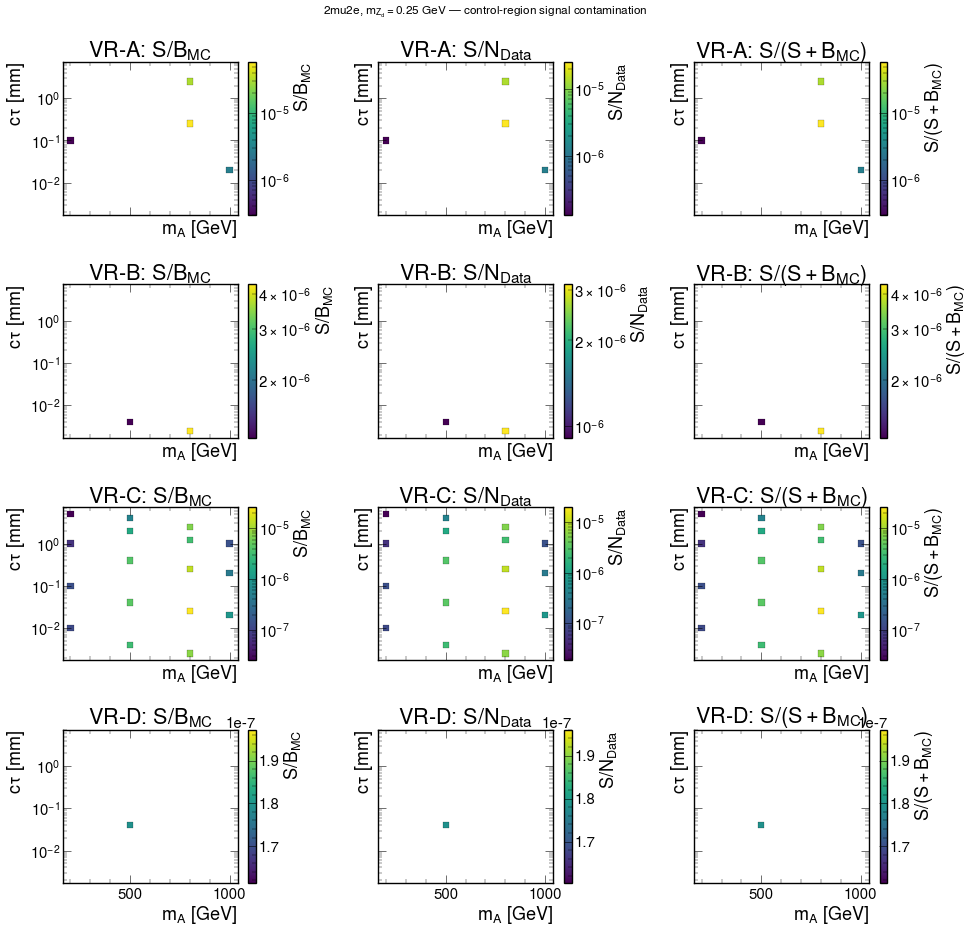

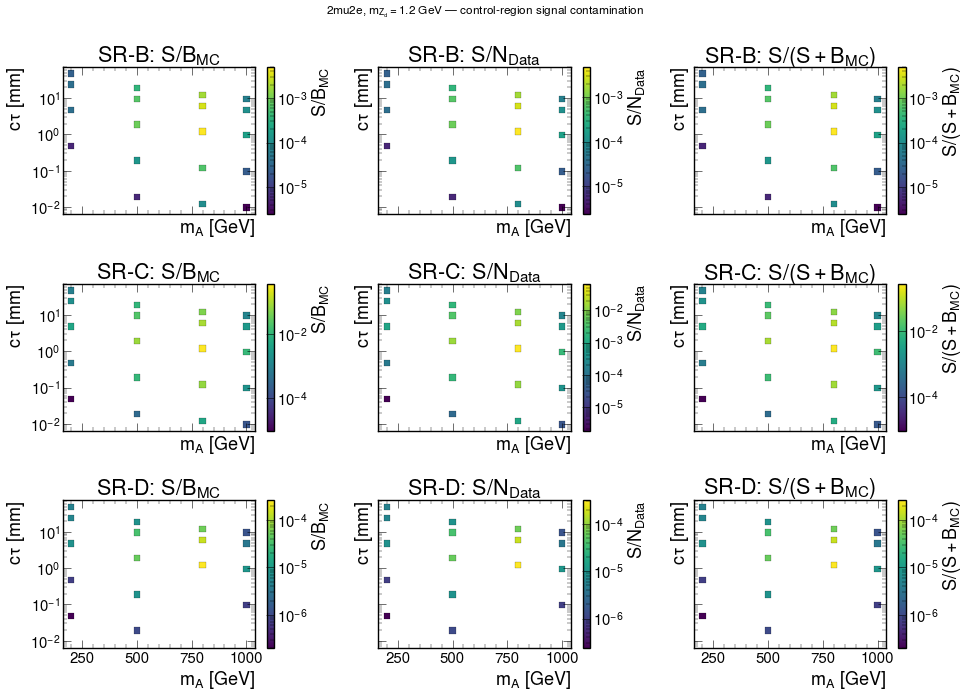

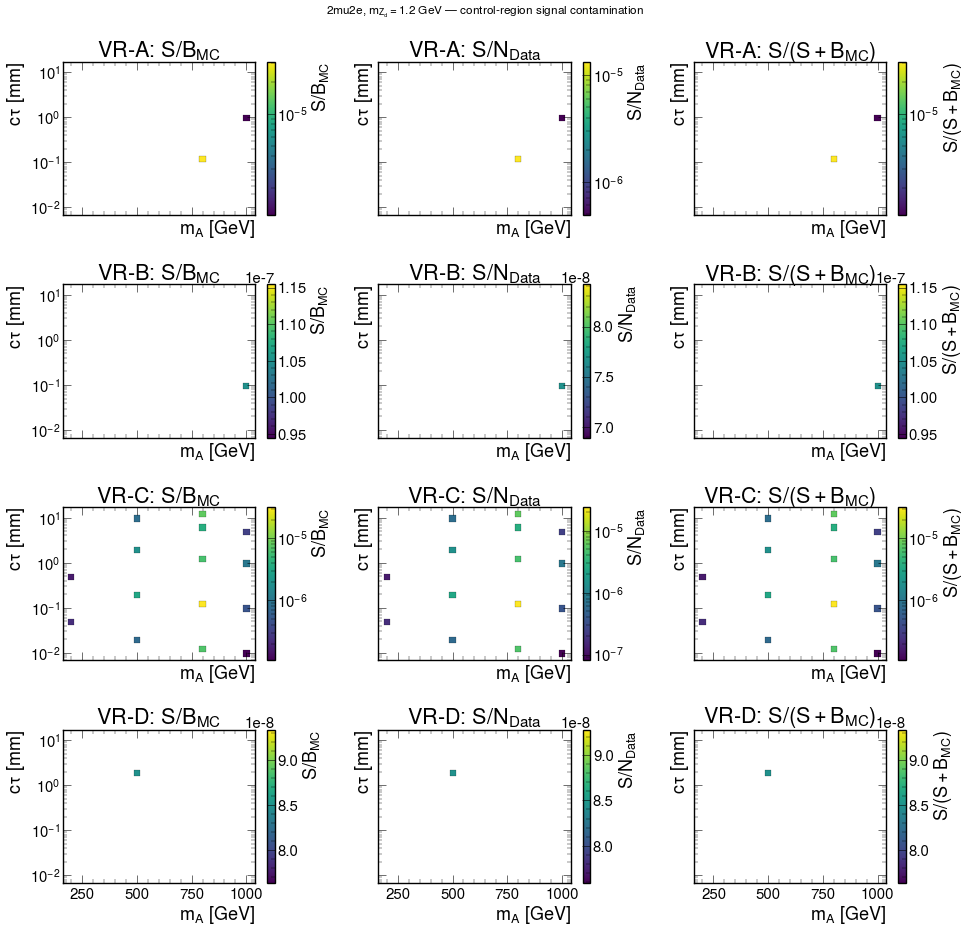

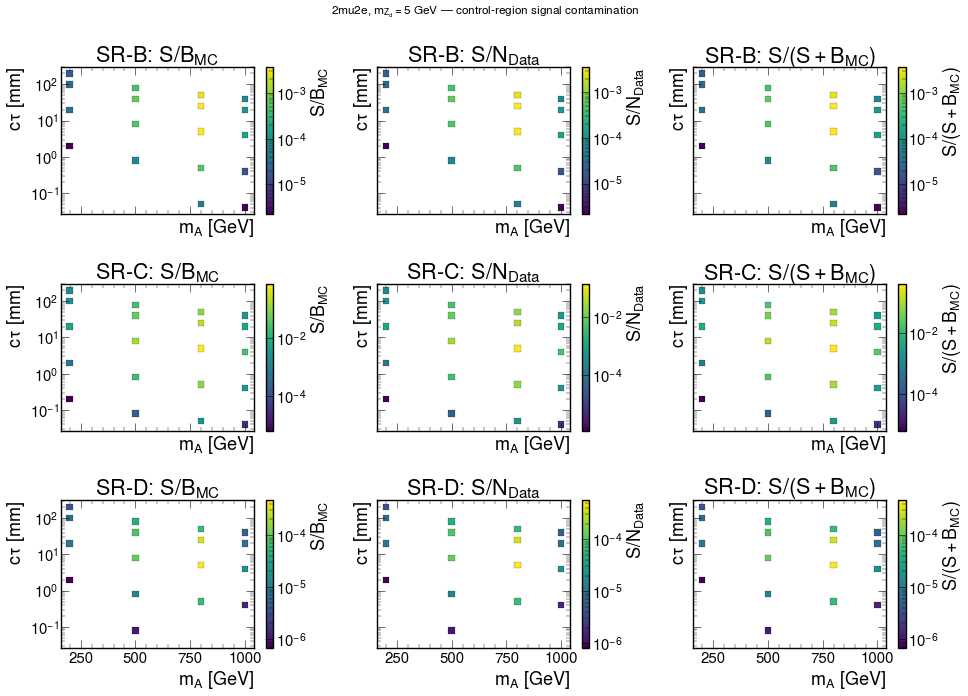

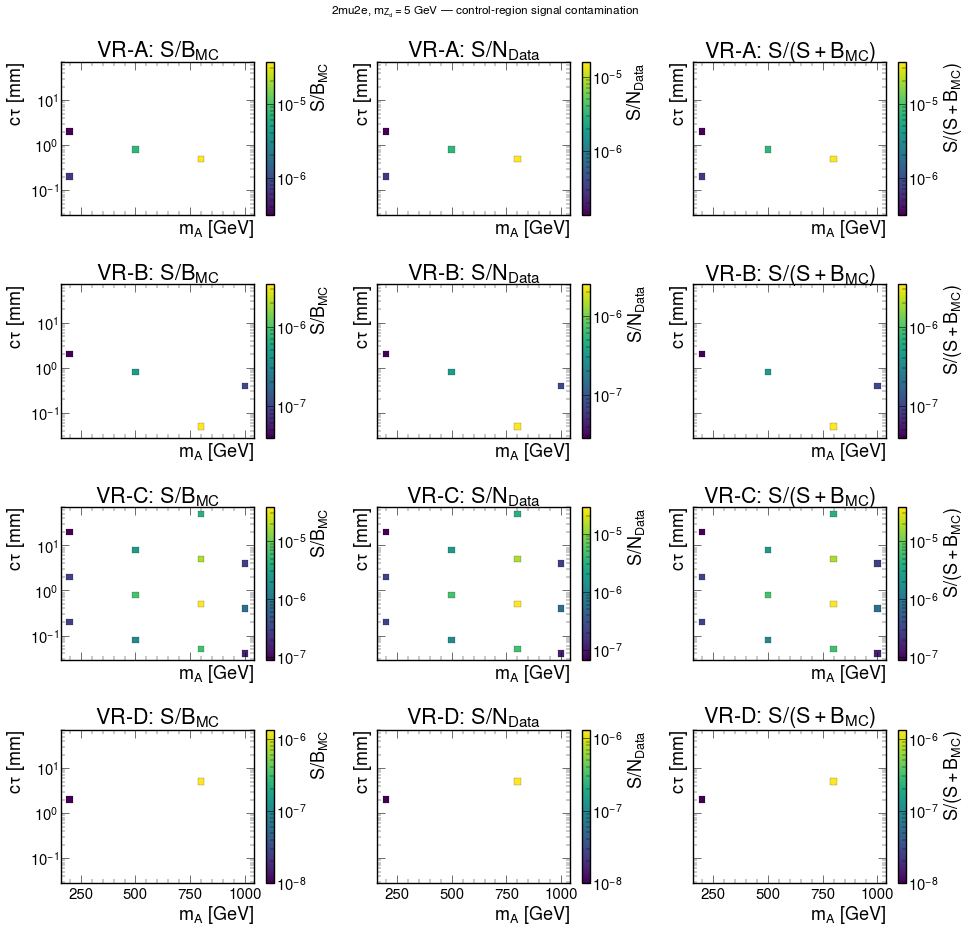

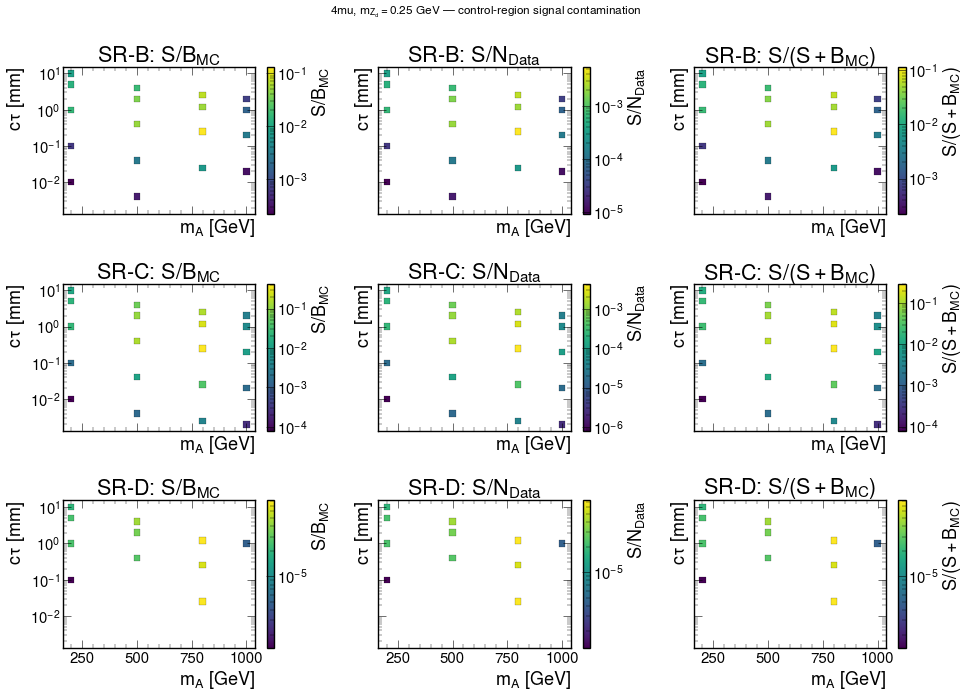

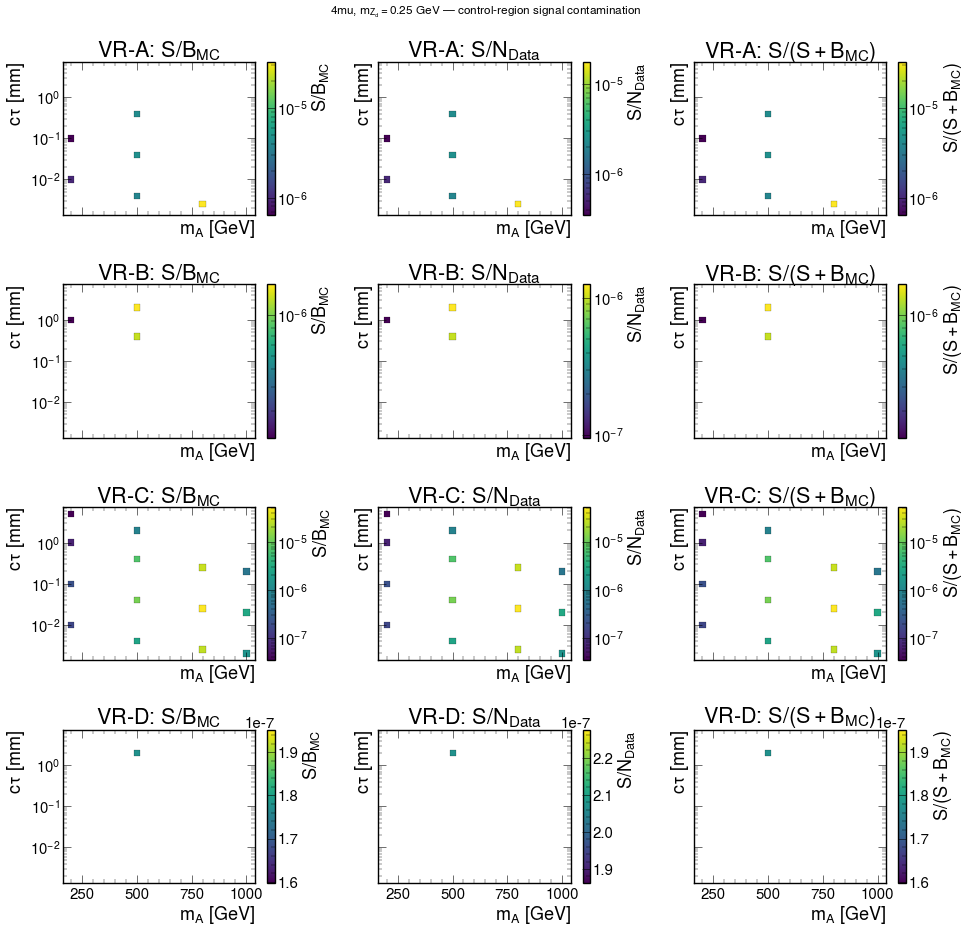

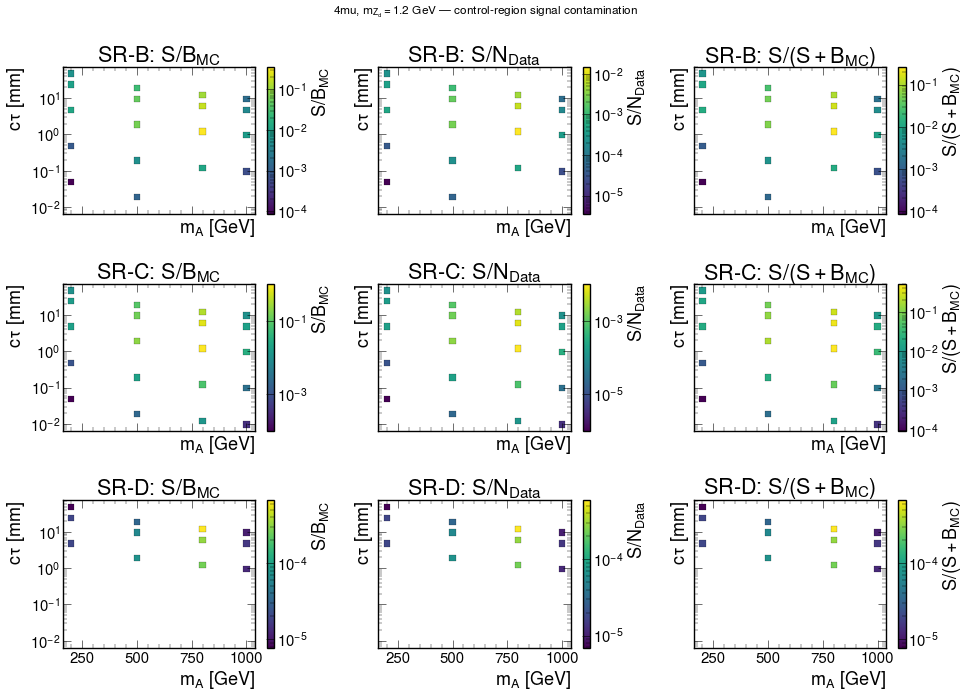

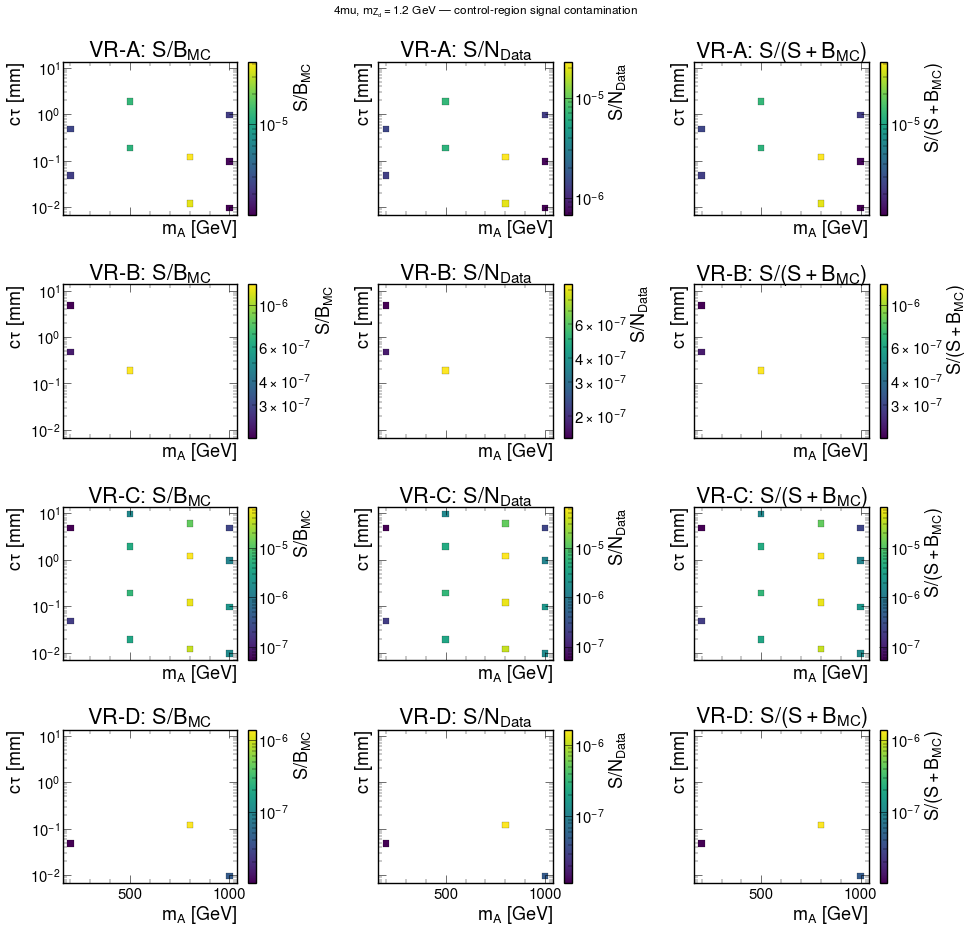

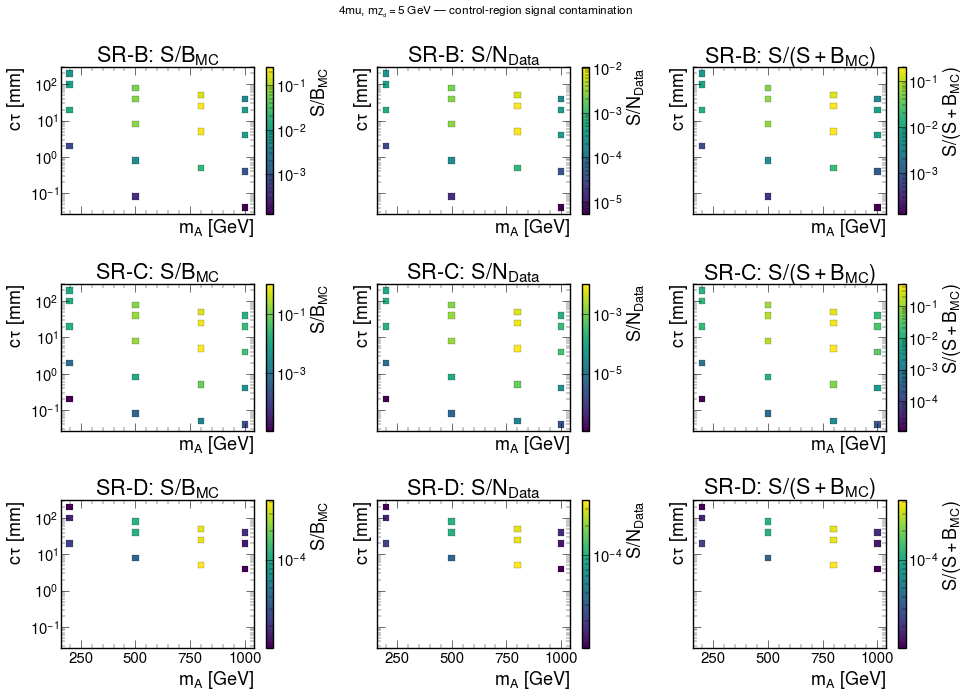

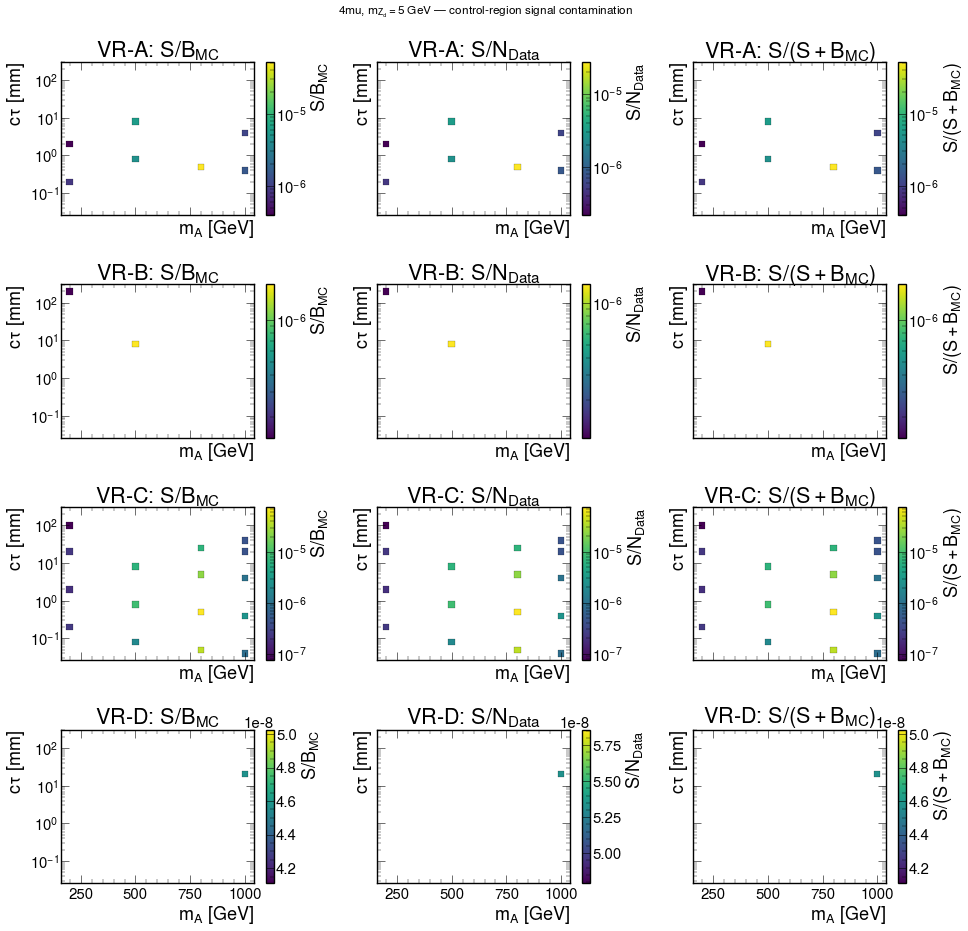

In [27]:
def plot_contamination_grid(frame, topology, mzd, selection):
    regions = ('B','C','D') if selection == 'SR' else ('A','B','C','D')
    fig, axes = plt.subplots(len(regions), len(CONTAMINATION_METRICS),
                             figsize=(20, 4.8*len(regions)), squeeze=False,
                             sharex=True, sharey=True)
    labels = {'S_over_B_MC': r'$S/B_{MC}$', 'S_over_N_Data': r'$S/N_{Data}$',
              'S_over_SplusB_MC': r'$S/(S+B_{MC})$'}
    for row_index, region in enumerate(regions):
        region_frame = frame[frame.region == region]
        for column_index, metric in enumerate(CONTAMINATION_METRICS):
            ax = axes[row_index, column_index]
            finite = region_frame[np.isfinite(region_frame[metric]) & (region_frame[metric] > 0)]
            if finite.empty:
                ax.text(.5,.5,'No finite positive values',ha='center',va='center',transform=ax.transAxes)
            else:
                values = finite[metric].to_numpy(float)
                norm = LogNorm(vmin=max(values.min(),1e-8),vmax=values.max()) if values.max()>values.min() else None
                points = ax.scatter(finite.mA_GeV, finite.ctau_mm, c=values, s=85,
                    marker='s', cmap='viridis', norm=norm, edgecolor='black', linewidth=.25)
                fig.colorbar(points, ax=ax, label=labels[metric])
            ax.set_yscale('log'); ax.set_title(f'{selection}-{region}: {labels[metric]}')
            ax.set_xlabel(r'$m_A$ [GeV]'); ax.set_ylabel(r'$c\tau$ [mm]')
    fig.suptitle(f'{topology}, $m_{{Z_d}}={mzd:g}$ GeV — control-region signal contamination',fontsize=17)
    fig.tight_layout(); return fig

for (topology,mzd,selection), frame in control_contamination.groupby(['topology','mZd_GeV','selection']):
    plot_contamination_grid(frame,topology,mzd,selection)
    plt.show(); plt.close()


In [28]:
contamination_summary = (control_contamination.groupby(['topology','selection','region'])
    .agg(points=('signal','size'), median_S_over_B_MC=('S_over_B_MC','median'),
         max_S_over_B_MC=('S_over_B_MC','max'), median_S_over_N_Data=('S_over_N_Data','median'),
         max_S_over_N_Data=('S_over_N_Data','max'), small_background_points=('small_background_flag','sum'))
    .reset_index())
display(contamination_summary)
control_contamination.to_csv('control_region_signal_contamination.csv',index=False)
max_sr_bcd.to_csv('control_region_signal_contamination_max_sr_bcd.csv',index=False)


,topology,selection,region,points,median_S_over_B_MC,max_S_over_B_MC,median_S_over_N_Data,max_S_over_N_Data,small_background_points
0,2mu2e,SR,B,60,7.914638e-05,0.005105,7.620073e-05,0.004915,60
1,2mu2e,SR,C,60,5.560088e-03,0.767311,1.030666e-03,0.142235,60
2,2mu2e,SR,D,60,5.588850e-06,0.000464,6.713139e-06,0.000557,60
3,2mu2e,VR,A,60,0.000000e+00,0.000059,0.000000e+00,0.000026,0
4,2mu2e,VR,B,60,0.000000e+00,0.000004,0.000000e+00,0.000003,0
5,2mu2e,VR,C,60,4.564141e-07,0.000038,3.418389e-07,0.000029,0
6,2mu2e,VR,D,60,0.000000e+00,0.000001,0.000000e+00,0.000001,0
7,4mu,SR,B,60,7.377508e-03,0.359773,3.061568e-04,0.014930,60
8,4mu,SR,C,60,1.599275e-02,1.066632,1.632086e-04,0.010885,60
9,4mu,SR,D,60,1.180128e-05,0.000665,1.052831e-05,0.000593,60
